<a href="https://colab.research.google.com/github/MGuidolini/PUC-MVP/blob/Sprint02---Machine-Learning-%26-Analytics/MVP_ML_Analytics_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Marcos Aurélio Guidolini  
**Matrícula:** 4052025002325  
**Data:** 30/06/2026  
**Dataset:** [Calorias](https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/Sprint02---Machine-Learning-%26-Analytics/calorie_dataset.csv)  
**Tipo de problema:** Classificação



# 1 - Definição do problema




## 1.1 - Descrição do problema

Através de um conjunto de dados de alimentos de dados variados que consiste em informações de macronutrientes de alimentos ingeridos, em gramas, quantidade de calorias em (Kcal) e uma classe de calorias com os atributos de classificação: **low (BAIXA)**, **Medium (MADIA)** e **High (ALTA)**.

O objetivo principal é identificar quanto de Kcal um indivíduo ingere por refeição e classificar em que nível de calorias ele se encontra, **BAIXA**, **MEDIA** ou **ALTA**.

Para isso ou utilizar a Classificação e gerar um modelo de Machine Laerning que melhor se adeque a resolução do problema.

Com isso usuários da área de nutrição, poderão identificar a partir da entrada da quantidade de calorias ingeridas num dia se os macronutrientes está classifcado como **BAIXA**, **MEDIA** ou **ALTA**.


## 1.2 - Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning que poderão identificar a partir da entrada da quantidade de calorias ingeridas num dia, se os macronutrientes está classifcado como **BAIXA**, **MEDIA** ou **ALTA**, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 - Tipo de problema

**Tipo escolhido:** Classificação  
**Justificativa:** Quero classificar os os diferentes macronutrientes ingeridos numa refeição em **BAIXA**, **MEDIA** ou **ALTA**.


## 1.4 - Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1.  A quantidade total de calorias ingeridas em uma refeição é o preditor mais significativo para a classificação em níveis 'BAIXA', 'MEDIA' ou 'ALTA'.
2.  A proporção de carboidratos, proteínas e gorduras em relação às calorias totais fornecerá informações adicionais que melhoram a precisão da classificação.
3.  Um modelo de classificação será capaz de aprender padrões nos dados e atingir uma precisão razoável (acima de um baseline aleatório) na categorização dos níveis de calorias.

**Critérios de sucesso:**
- **Métrica principal:** F1-score ponderado (weighted F1-score), pois é um problema de classificação multiclasse e precisamos considerar o desempenho em todas as classes, especialmente se houver desbalanceamento.
- **Resultado mínimo esperado:** O modelo candidato deve superar o baseline (Dummy Classifier) em pelo menos 10% no F1-score ponderado.
- **Restrição prática:** O tempo de treinamento e inferência do modelo final deve ser inferior a 1 minuto, e os resultados devem ser razoavelmente interpretáveis para usuários da área de nutrição.


# 2 - Ambiente, bibliotecas e reprodutibilidade

###2.1 - Criando os importes necessários para utiulizar na analise dos dados.

In [2]:
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

import xgboost as xgb

import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

import xgboost as xgb

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.2 - Funções auxiliares

Serão utillizadas algumas funções auxiliares.



In [2]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    # Para multiclasse, usa a estratégia 'ovr' (One-vs-Rest).
    try:
        if proba is not None:
            if proba.shape[1] == 2:
                # Binary classification
                results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
            elif proba.shape[1] > 2:
                # Classificação multiclasse (estratégia Um-contra-Todos)
                # É necessário mapear os rótulos de string para números inteiros para que roc_auc_score funcione com 'ovr'.
                # Obtenha Classes exclusivas e crie um mapeamento.
                classes = np.unique(y_true)
                y_true_encoded = np.array([np.where(classes == label)[0][0] for label in y_true])

                results["roc_auc"] = roc_auc_score(y_true_encoded, proba, multi_class='ovr', average='weighted')
            else:
                results["roc_auc"] = np.nan
        else:
            results["roc_auc"] = np.nan
    except Exception as e:
        # print(f"Erro ao calcular ROC AUC: {e}") # Para depuração se necessário
        results["roc_auc"] = np.nan

    return results

def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# 3 - Seleção e carga dos dados

## 3.1 - Fonte dos dados
**Informações do Dataset**
- nome do dataset: **Dataset Calorias:**
- link da fonte: [Calorias](https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/Sprint02---Machine-Learning-%26-Analytics/calorie_dataset.csv)
- por que esse dataset foi escolhido: Este conjunto de dados contém dados sintéticos, porém realistas, de nutrição alimentar, projetados para tarefas de classificação para Machine learning. Cada entrada representa um alimento com sua composição de macronutrientes (Carboidrato, Proteína, Gordura, fibra e açúcar), calorias totais e uma classe calórica rotulada: low (Baixo), Medium (Médio) e High (Alto).
- Não há questões de ética, privacidade, confidencialidade ou licença para esse dataset.


## 3.2 - Carga dos dados


### 3.2.1 Lendo os dados do Dataset Calorias e guardando num Dataframe local

In [3]:
# Carrega arquivo csv usando Pandas usando uma URL

# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/Sprint02---Machine-Learning-%26-Analytics/calorie_dataset.csv"

# Informa o cabeçalho das colunas
colunas_Calorias = ['Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g', 'Calorias/Kcal', 'Classe_de_Calorias']


# Lê o arquivo utilizando as colunas informadas
Calorias = pd.read_csv(url, names=colunas_Calorias, skiprows=1, delimiter=',')

# Pega apenas os dados do dataset e guardando em um array
array = Calorias.values


# Separa o array em variáveis preditoras (X) e variável target (Y)
X = array[:,0:8]
Y = array[:,0:8]

dafr_Calorias = pd.DataFrame(data=Calorias, columns=colunas_Calorias)


## 3.3 - Visão geral do dataset




### 3.3.1 Atributos do Dataset

O dataset **Calorie Dataset** contém 5.000 amostras, com números aleatórios de amostras para cada refeição. Possui nove atributos:


- ***Carboidrato:*** Quantidade em gramas.
- ***Proteína:*** Quantidade em gramas.
- ***Gordura:*** Quantidade em gramas.
- ***Fibra:*** Quantidade em gramas.
- ***Açúcar:*** Quantidade em gramas.
- ***Calorias:*** É o resultado do seguinte cálculo:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal

- ***Classe de Calorias*** (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)

### 3.3.2 Quantidade de Linhas e Colunas


In [4]:
print("Formato do dataset:", dafr_Calorias.shape)


Formato do dataset: (5000, 7)


### 3.3.3 Primeiras linhas do DataSet:


In [5]:
dafr_Calorias.head()

,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias
0,22.5,65.2,13.7,9.9,26.7,479.0,medium
1,15.9,20.7,16.8,7.6,15.0,316.0,low
2,28.3,62.4,14.5,10.8,15.3,524.0,medium
3,23.3,18.6,7.9,17.0,0.2,250.0,low
4,30.8,55.1,31.9,12.5,7.2,602.0,medium


### 3.3.4 Tipos de dados

In [6]:
# Verificar e imprimir na tela o total de instâncias
print(f"Total de instâncias: {len(Calorias)}")
print("\nTipos de dados por coluna:")
print(dafr_Calorias.info())

Total de instâncias: 5000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Carboidrato/g       5000 non-null   float64
 1   Proteina/g          5000 non-null   float64
 2   Gordura/g           5000 non-null   float64
 3   Fibra/g             5000 non-null   float64
 4   Acucar/g            5000 non-null   float64
 5   Calorias/Kcal       5000 non-null   float64
 6   Classe_de_Calorias  5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
None


### 3.3.5 Valores Ausentes:


In [7]:
print("\nValores ausentes por coluna:")
display(dafr_Calorias.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Carboidrato/g,0
Proteina/g,0
Gordura/g,0
Fibra/g,0
Acucar/g,0
Calorias/Kcal,0
Classe_de_Calorias,0


### 3.3.6 Valores Duplicados:


In [8]:
print("\nDuplicatas:", dafr_Calorias.duplicated().sum())



Duplicatas: 0


## 3.4 - Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Carboidrato/g | numérica | Quantidade em gramas | sim | _Utilizado para calcular as calorias totais_ |
| Proteina/g | numérica | Quantidade em gramas | sim | _Utilizado para calcular as calorias totais_ |
| Gordura/g | numérica | Quantidade em gramas | sim | _Utilizado para calcular as calorias totais_ |
| Fibra/g | numérica | Quantidade em gramas | sim | _Utilizado para calcular as calorias totais_ |
| Acucar/g | numérica | Quantidade em gramas | sim | _Utilizado para calcular as calorias totais_ |
| Calorias/Kcal | numérica | somas de todos valores dos macronutrientes acima | sim | _Calcular o total de Calorias Ingeridas para dar informações na Classificação de Calorias_ |
| Classe_de_Calorias | alvo | Classifica os valores de calorias| sim |  BAIXA, MEDIA ou ALTA |


# 4 - Análise exploratória dos dados


## 4.1 - Validação do cálculo de Calorias/Kcal

Observei que o valor da coluna **Calorias/Kcal** não está batendo com a regra de cálculo de Kcal e vou investigar.

Calcular os Macronutrientes em Kcal.

Apliquei o valor de Kcal por gramas ingeridas dos macronutrientes, conforme regras abaixo, e calculei as 5 primeiras atributos (**Carboidrato/g; Proteina/g; Gordura/g; Fibra/g e Acucar/g**) e depois somei todos os resultados na variável **soma_primeiras_5**.


*Regras para formar o valor dos dados do atributo* ***Calorias:***

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal


In [9]:
# Seleciona as 5 primeiras colunas (macronutrientes)
macronutrientes = dafr_Calorias.iloc[:, :5]

# Define os coeficientes de caloria por grama para cada macronutriente
coeficientes_calorias = np.array([4, 4, 9, 2, 4])


# Multiplica os macronutrientes pelos seus respectivos coeficientes
calorias_por_macronutriente = macronutrientes.mul(coeficientes_calorias, axis=1);


# Exibe as 10 primeiras linhas dos valores das 5 primeiras colunas
print("Valores das 5 primeiras colunas em gramas (10 primeiras linhas):\n")
print(macronutrientes.head(10))
print("-----------------------------------------------------------------")


# Mostra o resultado das 10 primeiras linhas das 5 primeiras Colunas
print("Transformar em Kcal (10 primeiras linhas):")
print("Cálculos (Carboidrato/g x 4 - Proteina/g x 4 - Gordura/g x 9:")
print("Fibra/g x 2 - Acucar/g x 4):\n")
print(calorias_por_macronutriente.head(10))
print("-----------------------------------------------------------------")


Valores das 5 primeiras colunas em gramas (10 primeiras linhas):

   Carboidrato/g  Proteina/g  Gordura/g  Fibra/g  Acucar/g
0           22.5        65.2       13.7      9.9      26.7
1           15.9        20.7       16.8      7.6      15.0
2           28.3        62.4       14.5     10.8      15.3
3           23.3        18.6        7.9     17.0       0.2
4           30.8        55.1       31.9     12.5       7.2
5           35.5        72.8       19.6      6.7      11.9
6           16.1        45.1        9.8     12.5      21.0
7           38.1        23.1       17.1      0.0       5.6
8           31.6        43.3       17.4      5.3      17.4
9           21.4        76.1       18.1      2.0      23.0
-----------------------------------------------------------------
Transformar em Kcal (10 primeiras linhas):
Cálculos (Carboidrato/g x 4 - Proteina/g x 4 - Gordura/g x 9:
Fibra/g x 2 - Acucar/g x 4):

   Carboidrato/g  Proteina/g  Gordura/g  Fibra/g  Acucar/g
0           90.0       26

#### 4.1.1 Soma dos resultados dos Macronutrientes calculados em Kcal e comparar com o campo Calorias/Kcal da tabela original.

In [10]:
# Soma os valores das 5 primeiras colunas por linha
soma_primeiras_5 = calorias_por_macronutriente.sum(axis=1)

# Mostra o resultado das 10 primeiras linhas
print("Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):")
print(soma_primeiras_5.head(10))
print("-----------------------------------------------------------------")

# Exibe as 10 primeiras linhas do valor 'Calorias/Kcal'
print("\nValores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):")
print(dafr_Calorias['Calorias/Kcal'].head(10))

Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
dtype: float64
-----------------------------------------------------------------

Valores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):
0    479.0
1    316.0
2    524.0
3    250.0
4    602.0
5    634.0
6    374.0
7    379.0
8    418.0
9    566.0
Name: Calorias/Kcal, dtype: float64


#### 4.1.2 Gráfico de linhas com a comparação entre o campo original 'Calorias/Kcal' com o valor da Variável soma_primeiras_5




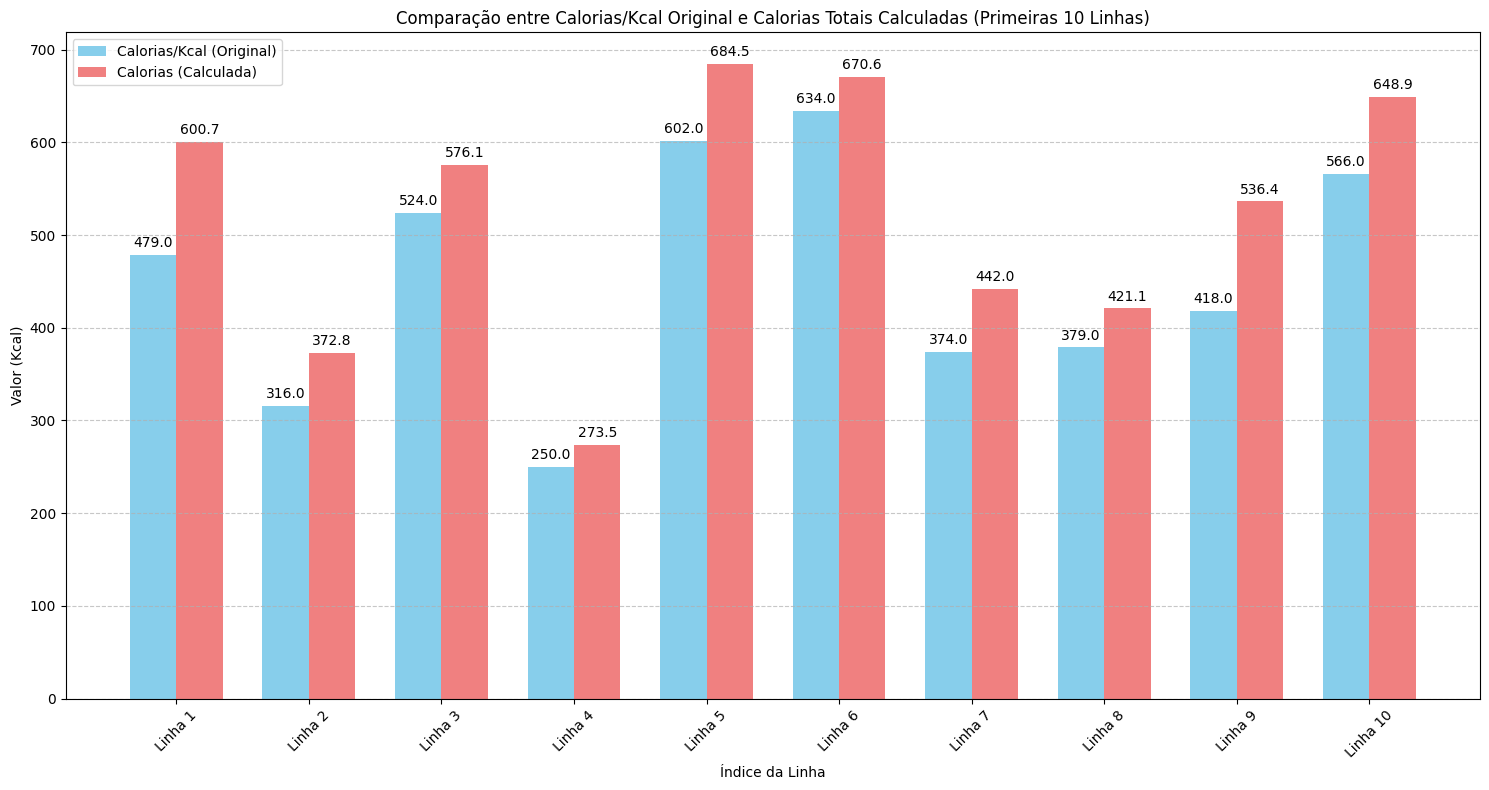

In [11]:
# obtendo as 10 primeiras linhas e comparando
calorias_original_10 = dafr_Calorias['Calorias/Kcal'].head(10)
calorias_calculada_10 = soma_primeiras_5.head(10)

# criando um index para as barras
indices = np.arange(len(calorias_original_10))
bar_width = 0.35

plt.figure(figsize=(15, 8))

# Plot original 'Calorias/Kcal'
bars1 = plt.bar(indices - bar_width/2, calorias_original_10, bar_width, label='Calorias/Kcal (Original)', color='skyblue')

# Plot calculado 'soma_primeiras_5'
bars2 = plt.bar(indices + bar_width/2, calorias_calculada_10, bar_width, label='Calorias (Calculada)', color='lightcoral')

# adicionando os valores no topo da barra
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

plt.xlabel('Índice da Linha')
plt.ylabel('Valor (Kcal)')
plt.title('Comparação entre Calorias/Kcal Original e Calorias Totais Calculadas (Primeiras 10 Linhas)')
plt.xticks(indices, [f'Linha {i}' for i in range(1, 11)], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Como suspeitei os valores do campo **Calorias/Kcal (Original)** estavam incorretos de acordo com a regra de **Calorias (Calculada).**

No gráfico de barras acima, percebi que no resultado da variável **Calorias (Calculada)** que é a soma de todos macronutrientes, em Kcal, está diferente do cálculo do atributo - ***Calorias/Kcal***

## 4.2 - Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

### 4.2.1 Novas características (**feature engineering**)

#### 4.2.1.1 Solução para resolver o problema de Cálculo errado:
Criar um novo atributo e recalcular os valores de acordo com a regra de **Calorias (Kcal)** de recalcular os valores.

Além de criar e popular novos atributos para realizar a análise.


Incluí os seguintes campos, com dados sintéticos, no dataset original (Calorie Dataset) para poder testar minhas Hipótestes:
- ***UF:*** Em siglas
- ***Idade:*** Idade de 18 a 81 anos
- ***Sexo:*** ***F*** - Feminio, ***M*** - Masculino, ***O*** - Outros
- ***Refeição:*** Café da manhã, Almoço, Jantar, Lanche
- ***Calorias Totais:*** É o resultado do seguinte cálculo:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal
- ***Nível de Calorias:*** (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)


#### 4.2.1.2 Criando os atributos e populando com dados aleatórios no fim do DataSet:


- ***Calorias Totais:*** com os seguintes cálculos:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal
- ***Nível de Calorias:*** com as seguintes regras: (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)


**OBS:** *Os atributos e dados originais serão mantidos.*

In [12]:
# Calcular 'Calorias_Totais'
dafr_Calorias['Calorias_Totais/Kcal'] = (
    dafr_Calorias['Carboidrato/g'] * 4 +
    dafr_Calorias['Proteina/g'] * 4 +
    dafr_Calorias['Gordura/g'] * 9 +
    dafr_Calorias['Fibra/g'] * 2 +
    dafr_Calorias['Acucar/g'] * 4
)

# Função para categorizar o nível de calorias
def categorizar_nivel_calorias(calorias):
    if calorias < 400:
        return 'BAIXA'
    elif 400 <= calorias <= 699:
        return 'MEDIA'
    else:
        return 'ALTA'

# Aplicar a função para criar a coluna 'Nível_Calorias'
dafr_Calorias['Nivel_Calorias'] = dafr_Calorias['Calorias_Totais/Kcal'].apply(categorizar_nivel_calorias)

print("DataFrame 'dafr_Calorias_Nova' atualizado com 'Calorias_Totais' e 'Nível_Calorias':")
display(dafr_Calorias.head(10))

DataFrame 'dafr_Calorias_Nova' atualizado com 'Calorias_Totais' e 'Nível_Calorias':


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias,Calorias_Totais/Kcal,Nivel_Calorias
0,22.5,65.2,13.7,9.9,26.7,479.0,medium,600.7,MEDIA
1,15.9,20.7,16.8,7.6,15.0,316.0,low,372.8,BAIXA
2,28.3,62.4,14.5,10.8,15.3,524.0,medium,576.1,MEDIA
3,23.3,18.6,7.9,17.0,0.2,250.0,low,273.5,BAIXA
4,30.8,55.1,31.9,12.5,7.2,602.0,medium,684.5,MEDIA
5,35.5,72.8,19.6,6.7,11.9,634.0,medium,670.6,MEDIA
6,16.1,45.1,9.8,12.5,21.0,374.0,low,442.0,MEDIA
7,38.1,23.1,17.1,0.0,5.6,379.0,low,421.1,MEDIA
8,31.6,43.3,17.4,5.3,17.4,418.0,medium,536.4,MEDIA
9,21.4,76.1,18.1,2.0,23.0,566.0,medium,648.9,MEDIA


#### 4.2.1.3 Resultado das 10 primeiras linhas e depois comparado com os valores do campo Calorias_Totais/Kcal criado.

In [13]:
# Mostra o resultado das 10 primeiras linhas
print("Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):")
print(soma_primeiras_5.head(10))
print("-----------------------------------------------------------------")

# Exibe as 10 primeiras linhas do valor 'Calorias/Kcal'
print("\nValores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):")
print(dafr_Calorias['Calorias_Totais/Kcal'].head(10))

Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
dtype: float64
-----------------------------------------------------------------

Valores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
Name: Calorias_Totais/Kcal, dtype: float64


####4.2.1.4 Gráfico de linhas com a transformação

Depois da transformção, mostro no gràfico de Barras que os dados do campo **Calorias_Totais/Kcal** e está igual aos dados cálculos com a regra de formação de calorias.

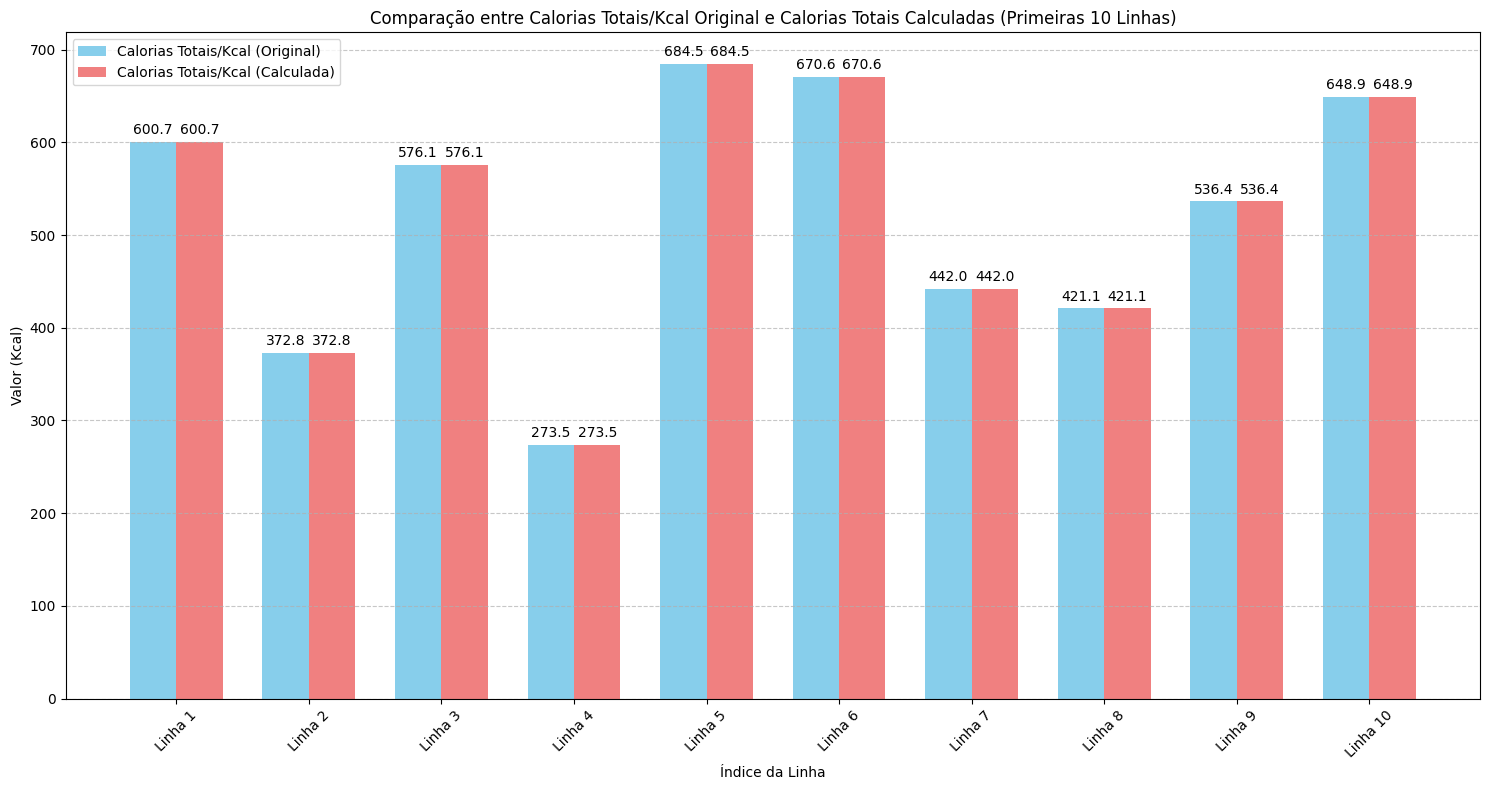

In [14]:
# obtendo as 10 primeiras linhas e comparando
calorias_original_10 = dafr_Calorias['Calorias_Totais/Kcal'].head(10)
calorias_calculada_10 = soma_primeiras_5.head(10)

# criando um index para as barras
indices = np.arange(len(calorias_original_10))
bar_width = 0.35

plt.figure(figsize=(15, 8))

# Plot original 'Calorias/Kcal'
bars1 = plt.bar(indices - bar_width/2, calorias_original_10, bar_width, label='Calorias Totais/Kcal (Original)', color='skyblue')

# Plot calculado 'soma_primeiras_5'
bars2 = plt.bar(indices + bar_width/2, calorias_calculada_10, bar_width, label='Calorias Totais/Kcal (Calculada)', color='lightcoral')

# adicionando os valores no topo da barra
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

plt.xlabel('Índice da Linha')
plt.ylabel('Valor (Kcal)')
plt.title('Comparação entre Calorias Totais/Kcal Original e Calorias Totais Calculadas (Primeiras 10 Linhas)')
plt.xticks(indices, [f'Linha {i}' for i in range(1, 11)], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4.2.2 Gerar um novo Dataframe.

Foi gerado um novo DataFrame: ***dafr_Refeicao***, retirando os campos originais (**Calorias/Kcal** e **Classe_de_Calorias**) pois os mesmos estavam com os cálculos incorretos.

In [15]:
colunas_para_dafr_Refeicao = [
    'Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g',
    'Calorias_Totais/Kcal', 'Nivel_Calorias'
]

dafr_Refeicao = dafr_Calorias[colunas_para_dafr_Refeicao].copy()

print("Novo DataFrame 'dafr_Refeicao' criado com as colunas solicitadas:\n")
display(dafr_Refeicao.head())

Novo DataFrame 'dafr_Refeicao' criado com as colunas solicitadas:



,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias_Totais/Kcal,Nivel_Calorias
0,22.5,65.2,13.7,9.9,26.7,600.7,MEDIA
1,15.9,20.7,16.8,7.6,15.0,372.8,BAIXA
2,28.3,62.4,14.5,10.8,15.3,576.1,MEDIA
3,23.3,18.6,7.9,17.0,0.2,273.5,BAIXA
4,30.8,55.1,31.9,12.5,7.2,684.5,MEDIA


## 4.3 - Distribuição do Target

In [16]:
# Identificando o TARGET e PROBLEM_TYPE.
TARGET = "Nivel_Calorias"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in dafr_Calorias.columns:
    print("Distribuição do target:")
    display(dafr_Refeicao[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((dafr_Refeicao[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

Distribuição do target:


,contagem
Nivel_Calorias,
MEDIA,3938
ALTA,585
BAIXA,477


,percentual
Nivel_Calorias,
MEDIA,78.76
ALTA,11.70
BAIXA,9.54


#### 4.3.1 Distribuição de nível de calorias

*   **Antes da correção do cálculo de calorias**




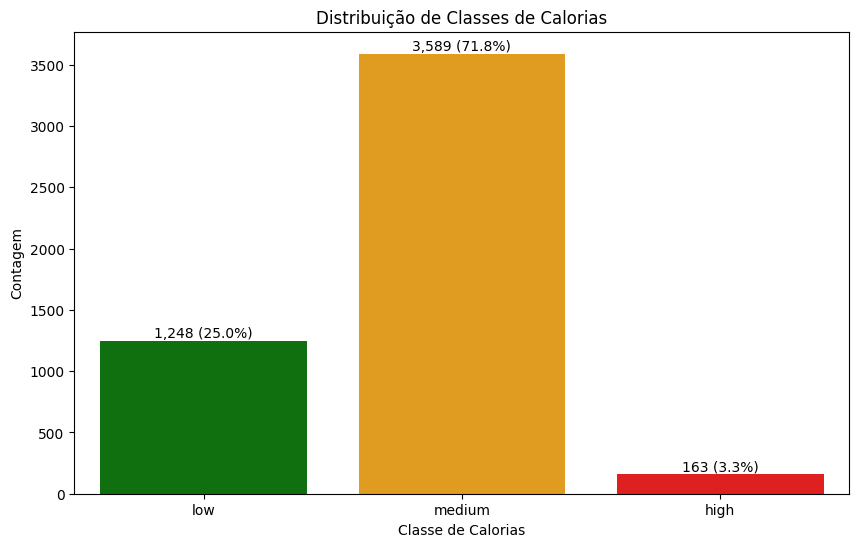

In [17]:
plt.figure(figsize=(10, 6))
# Define a custom palette
palette_class_colors = {'low': 'green', 'medium': 'orange', 'high': 'red'}
# gráfico de barras simples
ax = sns.countplot(x='Classe_de_Calorias', data=dafr_Calorias, hue='Classe_de_Calorias', palette=palette_class_colors, legend=False, order=['low', 'medium', 'high'])
plt.title('Distribuição de Classes de Calorias')
plt.xlabel('Classe de Calorias')
plt.ylabel('Contagem')

# Calcular as contagens e porcentagens
total = len(dafr_Calorias)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.show()

*   **Depois da correção do cálculo de calorias**

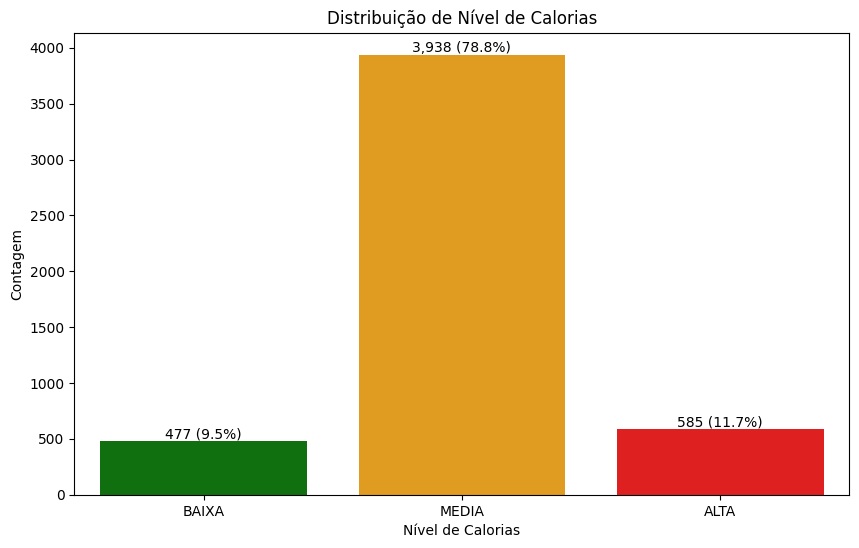

In [18]:
plt.figure(figsize=(10, 6))
# Define a custom palette
palette_class_colors = {'BAIXA': 'green', 'MEDIA': 'orange', 'ALTA': 'red'}
# gráfico de barras simples
ax = sns.countplot(x='Nivel_Calorias', data=dafr_Refeicao, hue='Nivel_Calorias', palette=palette_class_colors, legend=False, order=['BAIXA', 'MEDIA', 'ALTA'])
plt.title('Distribuição de Nível de Calorias')
plt.xlabel('Nível de Calorias')
plt.ylabel('Contagem')

# Calcular as contagens e porcentagens
total = len(dafr_Refeicao)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.show()

> * Comparando os dois gráficos de dsitribuição de calorias (**Antes  e depois da correção do cálculo da *Calorias/Kcal***), a distribuição entre as classes eram diferentes, algumas que estava como Classe *BAIXA* subiram para *MEDIA* e como *MEDIA* subiram para *ALTA*.



>**OBS:** A partir, daqui foi utilizado somente o dataframe ***'dafr_Refeição'***, que foi acertado o cálculo de Calorias Totais.

Gráfico de Barras com informações de distribuição das médias dos atrubutos numéricos dos dados.

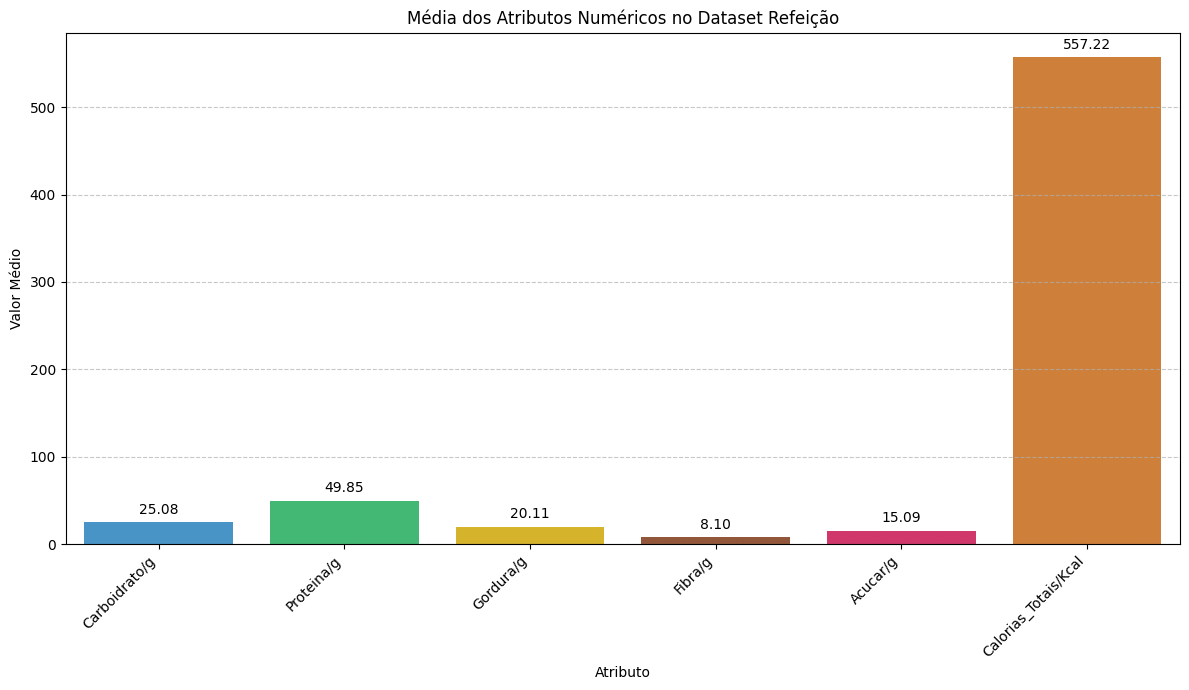

DataFrame 'dafr_Refeicao' com a linha da média adicionada:


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias_Totais/Kcal,Nivel_Calorias
4996,18.20000,67.00000,25.10000,6.40000,13.90000,635.10000,MEDIA
4997,14.20000,49.80000,28.90000,2.10000,0.10000,520.70000,MEDIA
4998,22.00000,20.50000,28.30000,13.90000,13.40000,506.10000,MEDIA
4999,33.60000,36.60000,17.60000,3.70000,27.50000,556.60000,MEDIA
5000,25.07672,49.85042,20.10528,8.10362,15.08898,557.21924,Média Geral


In [19]:
# Obtendo as médias dos atributos numéricos do dataset
mean_values = dafr_Refeicao.describe().loc['mean']

# Defina uma paleta de cores para cada coluna numérica.
palette = {
    'Carboidrato/g': '#3498db',  # Azul
    'Proteina/g': '#2ecc71',      # Verde
    'Gordura/g': '#f1c40f',     # Amarelo
    'Fibra/g': '#a0522d',        # Marrom
    'Acucar/g': '#e91e63',       # Rosa
    'Calorias_Totais/Kcal': '#e67e22'   # Laranja
}

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette=[palette.get(col, '#cccccc') for col in mean_values.index], hue=mean_values.index, legend=False)
plt.title('Média dos Atributos Numéricos no Dataset Refeição')
plt.xlabel('Atributo')
plt.ylabel('Valor Médio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Inserir valores da média nas colunas do gráfico
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Criar uma Series para a linha da média, correspondendo às colunas de dafr_Calorias
mean_row_df = mean_values.to_frame().T
mean_row_df['Nivel_Calorias'] = 'Média Geral' # Rótulo para a nova linha

# Garantir que a ordem das colunas corresponda a dafr_Calorias para uma concatenação limpa
mean_row_df = mean_row_df[dafr_Refeicao.columns]

# Concatenar a nova linha ao dafr_Calorias
dafr_Refeicao_com_medias = pd.concat([dafr_Refeicao, mean_row_df], ignore_index=True)

print("DataFrame 'dafr_Refeicao' com a linha da média adicionada:")
display(dafr_Refeicao_com_medias.tail())

Gráfico de Barras com informações de distribuição da Desvio Padrão dos atrubutos numéricos dos dados.

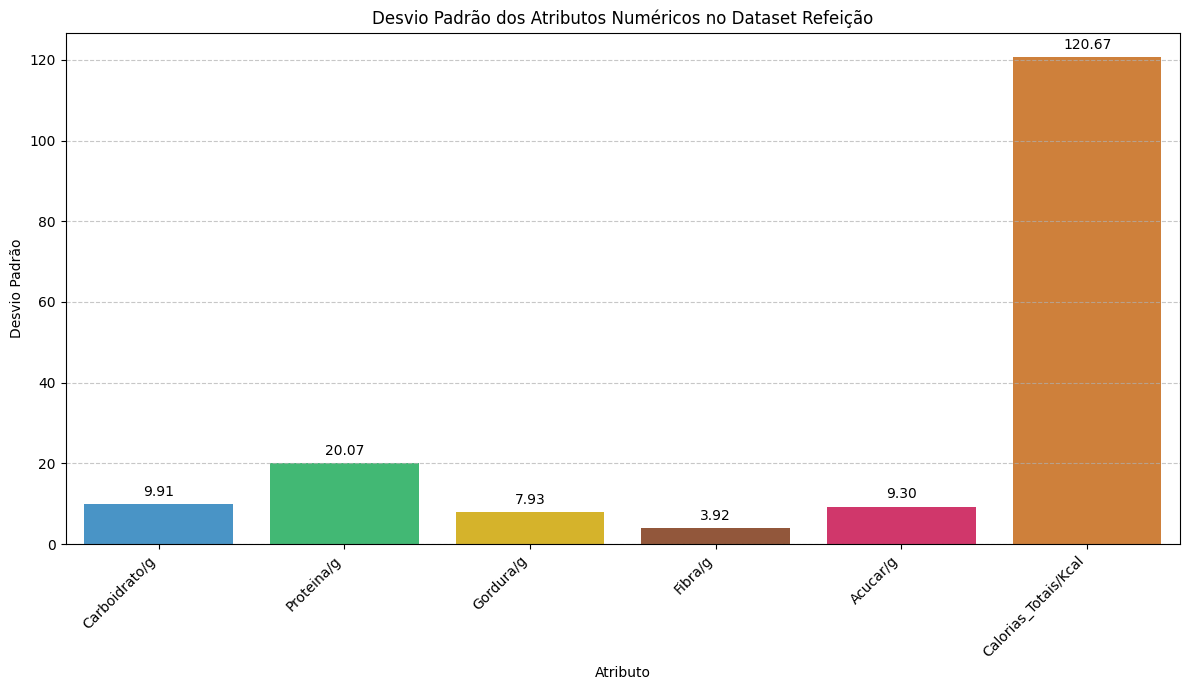

DataFrame 'dafr_Refeicao' com a linha do desvio padrão adicionada:


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias_Totais/Kcal,Nivel_Calorias
4996,18.200000,67.000000,25.100000,6.400000,13.900000,635.100000,MEDIA
4997,14.200000,49.800000,28.900000,2.100000,0.100000,520.700000,MEDIA
4998,22.000000,20.500000,28.300000,13.900000,13.400000,506.100000,MEDIA
4999,33.600000,36.600000,17.600000,3.700000,27.500000,556.600000,MEDIA
5000,9.907564,20.071407,7.933298,3.923217,9.298863,120.666745,Desvio Padrão Geral


In [20]:
# Gráfico de Barras com informações de distribuição do desvio padrão dos atributos numéricos do dataset

# Obtendo os desvios padrão dos atributos numéricos do dataset
std_values = dafr_Refeicao.describe().loc['std']

# Defina uma paleta de cores para cada coluna numérica.
palette = {
    'Carboidrato/g': '#3498db',  # Azul
    'Proteina/g': '#2ecc71',      # Verde
    'Gordura/g': '#f1c40f',     # Amarelo
    'Fibra/g': '#a0522d',        # Marrom
    'Acucar/g': '#e91e63',       # Rosa
    'Calorias_Totais/Kcal': '#e67e22'   # Laranja
}

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=std_values.index, y=std_values.values, palette=[palette.get(col, '#cccccc') for col in std_values.index], hue=std_values.index, legend=False)
plt.title('Desvio Padrão dos Atributos Numéricos no Dataset Refeição')
plt.xlabel('Atributo')
plt.ylabel('Desvio Padrão')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Inserir valores do desvio padrão nas colunas do gráfico
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Criar uma Series para a linha do desvio padrão, correspondendo às colunas de dafr_Refeicao
std_row_df = std_values.to_frame().T
std_row_df['Nivel_Calorias'] = 'Desvio Padrão Geral' # Rótulo para a nova linha

# Garantir que a ordem das colunas corresponda a dafr_Refeicao para uma concatenação limpa
# Criar uma cópia dafr_Refeicao.columns para evitar SettingWithCopyWarning, se necessário
std_row_df = std_row_df[dafr_Refeicao.columns.tolist()]

# Concatenar a nova linha ao dafr_Refeicao
dafr_Refeicao_com_desvios = pd.concat([dafr_Refeicao, std_row_df], ignore_index=True)

print("DataFrame 'dafr_Refeicao' com a linha do desvio padrão adicionada:")
display(dafr_Refeicao_com_desvios.tail())

## 4.4 - Síntese da análise exploratória


**Síntese:**
* **Cálculo incorreto:** Foi observado que o valor da coluna **Calorias/Kcal**, do Dataframe original (*dafr_Calorias*) não estava batendo com a regra de cálculo de Kcal, para isso foi realizado o cálculo correto e gravado num novo dataframe **dafr_Refeicao** para realizar a Analise Exploratória dos dados.
*   **Target Balanceamento:** O target **Nivel_Calorias** está significativamente desbalanceado, com o Nível de Caloria 'MEDIA' representando a maioria (78.8%), seguida por 'ALTA' (11.7%) e a minoria 'BAIXA' (9.5%).
*   **Valores Ausentes:** Não foram encontrados valores ausentes relevantes (**dafr_Calorias.isna().sum()** resultou em 0 para todas as colunas).
*   **Escala de Variáveis:** A variável **Calorias_Totais/Kcal** possui uma escala consideravelmente maior em comparação com os outros macronutrientes (**Carboidrato/g, Proteina/g, Gordura/g, Fibra/g, Acucar/g**). A padronização (**StandardScaler**) no pré-processamento é essencial para tratar essa diferença de escala.
*   **Categorias Raras:** A classe 'BAIXA' (9.5%) é uma categoria rara, o que pode impactar o desempenho do modelo nesta classe e justifica o uso do F1-score ponderado como métrica principal.
*   **Padrões e Modelagem:** O desbalanceamento sugere a necessidade de estratégias como a estratificação na divisão dos dados e o uso de métricas robustas a desbalanceamento. A padronização dos dados beneficia modelos sensíveis à escala, como a Regressão Logística.
*   **Impacto na Estratégia:** A análise exploratória confirmou a necessidade de usar **stratify=y** na divisão treino/teste para preservar a proporção das classes e reforçou a escolha do F1-score ponderado como métrica de sucesso para lidar com o desbalanceamento.

# 5 - Preparação dos dados e divisão treino/teste



### 5.1 - Tipo de Problema - Classificação

In [21]:
# === Configuração do problema ===
# Ajuste estas variáveis para o seu dataset.

TARGET = "Nivel_Calorias"          # Alvo
PROBLEM_TYPE = "classificacao"     # Tipo de problema = "classificacao"

# Definir colunas de ID e colunas a serem descartadas, se houver.
# Se não houver colunas específicas, mantenha-as como listas vazias.
ID_COLUMNS = []  # Ex: ['id_da_transacao', 'numero_do_cliente']
DROP_COLUMNS = [] # Ex: ['coluna_sem_relevancia', 'coluna_redundante']

# Inicializa columns_to_exclude com as colunas a serem excluídas
columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)

#excluir a coluna TARGET
if TARGET is not None:
    columns_to_exclude.add(TARGET)

#Apresentar os resultados
features = [c for c in dafr_Refeicao.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: Nivel_Calorias
Número de features: 6
Features: ['Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g', 'Calorias_Totais/Kcal']


### 5.2 - Divisão dos dados

> **OBS:** Como esse projeto se refere a um estudo acadêmico irei a realizar alguns experimentos para uma melhor escolha de modelos para esse MVP.

>Utilizei a divisão dos dados com duas técnicas, **Holdout** e **Validação Cruzada**, passando por todos os tópicos do projeto onde cabe separar as técnicas e depois realizar todos os testes com os modelos sugeridos, ao final fazer uma comparação entre os métodos utilizados.

#### 5.2.1 Divisão dos dados - Holdout

In [22]:
# === Divisão dos dados ===

# Assegura que o problema é de classificação antes de prosseguir.
if PROBLEM_TYPE == "classificacao":
    X = dafr_Refeicao[features].copy()
    y = dafr_Refeicao[TARGET].copy()

    # Usar stratify para problemas de classificação para manter a proporção das classes
    stratify_arg = y
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE deve ser 'classificacao' para este bloco de código.")

Treino: (3500, 6) | Teste: (1500, 6)


Aqui os dados foram divididos com sucesso em conjuntos de treino e teste. O conjunto de treino (X_train e y_train) possui 3500 instâncias e 6 atributos (colunas), enquanto o conjunto de teste (X_test e y_test) possui 1500 instâncias e 6 atributos. Isso corresponde a uma divisão de 70% para treino e 30% para teste, e a estratificação foi aplicada para manter a proporção das classes no caso de classificação.

####  5.2.2 Divisão dos dados - Validação Cruzada

In [23]:
print('--- Exemplo de Validação Cruzada Estratificada ---')

# Reutiliza o objeto StratifiedKFold já definido para as buscas de hiperparâmetros
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Usando StratifiedKFold com {cv_stratified.n_splits} splits.\n")

# Itera sobre os folds gerados pela validação cruzada estratificada
for fold, (train_index, val_index) in enumerate(cv_stratified.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    print(f"Fold {fold + 1}:")
    print(f"  Tamanho do conjunto de treino no fold: {len(X_train_fold)}")
    print(f"  Tamanho do conjunto de validação no fold: {len(X_val_fold)}")
    print(f"  Distribuição de classes no treino do fold: {Counter(y_train_fold)}")
    print(f"  Distribuição de classes na validação do fold: {Counter(y_val_fold)}")
    print("---------------------------------------------------")

print("Validação Cruzada Estratificada concluída. Observe que as proporções das classes são mantidas em cada fold.")


--- Exemplo de Validação Cruzada Estratificada ---
Usando StratifiedKFold com 5 splits.

Fold 1:
  Tamanho do conjunto de treino no fold: 2800
  Tamanho do conjunto de validação no fold: 700
  Distribuição de classes no treino do fold: Counter({'MEDIA': 2206, 'ALTA': 327, 'BAIXA': 267})
  Distribuição de classes na validação do fold: Counter({'MEDIA': 551, 'ALTA': 82, 'BAIXA': 67})
---------------------------------------------------
Fold 2:
  Tamanho do conjunto de treino no fold: 2800
  Tamanho do conjunto de validação no fold: 700
  Distribuição de classes no treino do fold: Counter({'MEDIA': 2206, 'ALTA': 327, 'BAIXA': 267})
  Distribuição de classes na validação do fold: Counter({'MEDIA': 551, 'ALTA': 82, 'BAIXA': 67})
---------------------------------------------------
Fold 3:
  Tamanho do conjunto de treino no fold: 2800
  Tamanho do conjunto de validação no fold: 700
  Distribuição de classes no treino do fold: Counter({'MEDIA': 2206, 'ALTA': 327, 'BAIXA': 267})
  Distribuição d

**Análise dos resultados do K-Fold:**

  A saída acima demonstra que o **StratifiedKFold** funcionou conforme o esperado.
  Para cada um dos 5 folds, o número de amostras nos conjuntos de treino e validação é consistente.
  Mais importante, a distribuição das classes (*'BAIXA'*, *'MEDIA'*, *'ALTA'*,) é mantida em proporções similares em cada fold, tanto para treino quanto para validação.
  
  Isso é crucial para garantir que o modelo seja treinado e avaliado em subconjuntos representativos da distribuição geral das classes, especialmente dado o desbalanceamento identificado na EDA. Essa abordagem minimiza o risco de **one fold** de validação ter pouquíssimas amostras de uma classe minoritária, o que levaria a uma avaliação de desempenho enviesada ou instável.

## 5.3 - Justificativa da divisão


### 5.3.1 Holdout

**Resposta:**
> **Por que usar holdout e validação cruzada estratificada?**
  Utilizamos o holdout (*Treino* e *Teste*) para uma avaliação inicial do modelo no conjunto de teste. Contudo, dado o desbalanceamento das classes, para a otimização de hiperparâmetros, a validação cruzada estratificada é fundamental. Ela garante que, em cada fold (subdivisão), a proporção das classes seja mantida, evitando que folds de validação tenham poucas ou nenhuma amostra da classe minoritária, o que é crucial para obter métricas de desempenho mais confiáveis em datasets desbalanceados.
  
  >**A proporção treino/teste (70/30) faz sentido para o tamanho do dataset desbalanceado?**
  Sim, a divisão de 70% para treino e 30% para teste é uma proporção padrão e faz sentido mesmo com o desbalanceamento, especialmente porque será aplicado técnicas de balanceamento (como SMOTE) apenas no conjunto de treino. Essa divisão assegura que o modelo tenha uma quantidade suficiente de dados para aprender padrões e que o conjunto de teste seja grande o bastante para uma avaliação representativa de sua capacidade de generalização.

> **Foi necessário estratificar as classes?**
  Sim. A estratificação (**stratify=y**) foi essencial durante a divisão treino/teste. Sem ela, haveria um alto risco de os conjuntos de treino ou teste terem uma representação distorcida das classes, principalmente da classe minoritária (**'BAIXA - 9.5%'**). Ao estratificar, garantimos que a proporção das classes original seja preservada em ambos os conjuntos, o que é crítico para treinar e avaliar modelos de forma justa em dados desbalanceados.

 > **Como a divisão evita vazamento de dados?**
  A divisão dos dados em treino e teste foi realizada antes de qualquer pré-processamento ou técnica de balanceamento. Isso é vital para evitar vazamento de dados. O **StandardScaler** e o **SMOTE** serão aplicados apenas no conjunto de treino (*X_train*). As estatísticas de padronização (*média e desvio padrão*) e os exemplos sintéticos gerados pelo **SMOTE** são aprendidos exclusivamente do treino e depois aplicados ao conjunto de teste (para padronização) ou ignorados (para exemplos sintéticos). Isso previne que informações do conjunto de teste 'vazem' para o treino, levando a uma avaliação superestimada do desempenho do modelo.

### 5.3.2 Validação Cruzada

**Resposta:**
> *   **Por que usar validação cruzada?**
    *   Para o nosso problema de classificação, que não envolve séries temporais, usamos uma combinação de **holdout** e **validação cruzada**. O *holdout* é fundamental para a avaliação final do modelo em dados totalmente não vistos. No entanto, a **validação cruzada** (especificamente o ***StratifiedKFold*** com 5 *folds*) é crucial para a **seleção e otimização dos hiperparâmetros** dos modelos candidatos. Ela permite que o modelo seja treinado e avaliado múltiplas vezes em diferentes subconjuntos de dados de treino/validação, proporcionando uma estimativa mais robusta e menos enviesada do desempenho do modelo em dados não vistos, o que é essencial antes da avaliação final no conjunto de teste. Além disso, ela maximiza o uso dos dados para o treinamento e otimização, ao invés de reservar uma grande parte para validação fixa.

> *   **A proporção treino/teste faz sentido para o tamanho do dataset?**
    *   Na validação cruzada (*StratifiedKFold*), a divisão não é em um único treino/teste, mas sim em *folds* de treino e validação dentro do conjunto *original de treino*. Por exemplo, com 5 *folds* e um conjunto de treino inicial de 3500 instâncias, cada iteração usa 80% (*2800* instâncias) para treino e 20% (*700* instâncias) para validação. Essa proporção é adequada para o tamanho do nosso dataset (*5000* instâncias totais) e para o conjunto de treino (*3500* instâncias). Ela garante que em cada *fold*, o modelo tenha dados suficientes para aprender padrões complexos e que haja um conjunto de validação representativo para avaliar o desempenho e guiar a otimização de hiperparâmetros.

> *   **Foi necessário estratificar as classes (na validação cruzada)?**
    *   Sim, a estratificação (**stratify=y**) foi **crítica e fundamental** dentro de cada *fold* da validação cruzada. Como o *Nivel_Calorias* está desbalanceado (por exemplo, a classe 'BAIXA' é minoritária), a estratificação garante que a proporção das classes seja mantida consistentemente em cada subconjunto de treino e validação gerado pelo *StratifiedKFold*. Isso é vital para que os modelos não sejam treinados de forma tendenciosa e para que a métrica de avaliação (**f1_weighted**) seja calculada de maneira justa, especialmente para as classes minoritárias. Sem estratificação, um *fold* poderia ter poucas ou nenhuma amostra de uma classe, levando a estimativas de desempenho irrealistas ou instáveis.

> *   **Como a divisão evita vazamento de dados?**
    *   A prevenção de vazamento de dados na validação cruzada é garantida pelo fato de que o **pré-processamento** (*SimpleImputer*, *StandardScaler*) e a aplicação do **SMOTE** (para balanceamento) são realizados **separadamente dentro de cada *fold***. Em cada iteração do *StratifiedKFold*:
        1.  Os dados são divididos em *treino_do_fold* e *validação_do_fold*.
        2.  O **SMOTE é aplicado apenas ao *treino_do_fold*** para balancear as classes. Novos exemplos sintéticos são gerados exclusivamente a partir dos dados de treino dessa iteração.
        3.  O *ColumnTransformer* (*preprocess* pipeline) é ***fit* (ajustado) apenas no *treino_do_fold* balanceado**.
        4.  Esse *preprocess* pipeline é então *transform* (aplicado) tanto no *treino_do_fold* balanceado quanto no *validação_do_fold*.
    *   Dessa forma, nenhuma informação do conjunto de *validação_do_fold* (ou do conjunto de teste final) é utilizada para aprender as transformações ou gerar exemplos sintéticos, prevenindo o vazamento de dados e garantindo que o desempenho reportado seja uma estimativa honesta da capacidade de generalização do modelo.

# 6 - Pré-processamento e pipeline



## 6.1 - Tratamento de Desbalanceamento com SMOTE

Dado o desbalanceamento das classes identificado na análise exploratória (Classe '**BAIXA**' como minoritária), aplicaremos a técnica **SMOTE** (*Synthetic Minority Over-sampling Technique*) para balancear o conjunto de dados de treino. Isso ajudará o modelo a aprender melhor as características da classe minoritária, melhorando seu desempenho geral.

### 6.1.1 Balanceamento com SMOTE para Holdout

In [24]:
print(f"Distribuição das classes em y_train antes do SMOTE: {Counter(y_train)}")

# A coluna 'Nivel_Calorias' foi removida de X_train em uma execução anterior
# para que o SMOTE pudesse ser aplicado apenas a colunas numéricas.
# Portanto, X_train já está preparado e pode ser usado diretamente.
X_train_smote_input = X_train

sm = SMOTE(random_state=SEED)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_smote_input, y_train)

# Depois do SMOTE
print(f"Distribuição das classes em y_train depois do SMOTE: {Counter(y_train_balanced)}")

# Atualizar X_train e y_train para os conjuntos balanceados
X_train = X_train_balanced
y_train = y_train_balanced

print(f"Shape de X_train após SMOTE: {X_train.shape}")
print(f"Shape de y_train após SMOTE: {y_train.shape}")

Distribuição das classes em y_train antes do SMOTE: Counter({'MEDIA': 2757, 'ALTA': 409, 'BAIXA': 334})
Distribuição das classes em y_train depois do SMOTE: Counter({'BAIXA': 2757, 'ALTA': 2757, 'MEDIA': 2757})
Shape de X_train após SMOTE: (8271, 6)
Shape de y_train após SMOTE: (8271,)


In [25]:
# Identificação automática simples de colunas numéricas e categóricas.
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
# Neste caso, DATE_COLUMN é None e não está nas features, então não precisa de modificação aqui.
# A coluna 'Classe_de_Calorias' é o TARGET e foi corretamente separada do conjunto de features (X_train).

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g', 'Calorias_Totais/Kcal']
Colunas categóricas: []


### 6.1.2 Balanceamento com SMOTE para Validação Cruzada

In [26]:
print('--- Aplicação de SMOTE dentro de cada Fold da Validação Cruzada Estratificada ---\n')

# Reutiliza o objeto StratifiedKFold
cv_stratified_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Inicializa o SMOTE
smote = SMOTE(random_state=SEED)

# Itera sobre os folds gerados pela validação cruzada estratificada
for fold, (train_index, val_index) in enumerate(cv_stratified_smote.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    print(f"Fold {fold + 1}:")
    print(f"  Distribuição de classes no treino do fold ANTES do SMOTE: {Counter(y_train_fold)}")

    # Aplica SMOTE apenas no conjunto de treino do fold
    X_train_fold_balanced, y_train_fold_balanced = smote.fit_resample(X_train_fold, y_train_fold)

    print(f"  Distribuição de classes no treino do fold DEPOIS do SMOTE: {Counter(y_train_fold_balanced)}")
    print(f"  Tamanho do conjunto de treino do fold balanceado: {len(X_train_fold_balanced)}")
    print(f"  Distribuição de classes na validação do fold: {Counter(y_val_fold)}")
    print(f"  Tamanho do conjunto de validação do fold: {len(X_val_fold)}")
    print("---------------------------------------------------")

print("Aplicação de SMOTE por fold na Validação Cruzada Estratificada concluída.")
print("Observe como as classes minoritárias são balanceadas dentro de cada conjunto de treino do fold.")

--- Aplicação de SMOTE dentro de cada Fold da Validação Cruzada Estratificada ---

Fold 1:
  Distribuição de classes no treino do fold ANTES do SMOTE: Counter({'ALTA': 2206, 'BAIXA': 2205, 'MEDIA': 2205})
  Distribuição de classes no treino do fold DEPOIS do SMOTE: Counter({'BAIXA': 2206, 'ALTA': 2206, 'MEDIA': 2206})
  Tamanho do conjunto de treino do fold balanceado: 6618
  Distribuição de classes na validação do fold: Counter({'MEDIA': 552, 'BAIXA': 552, 'ALTA': 551})
  Tamanho do conjunto de validação do fold: 1655
---------------------------------------------------
Fold 2:
  Distribuição de classes no treino do fold ANTES do SMOTE: Counter({'ALTA': 2206, 'MEDIA': 2206, 'BAIXA': 2205})
  Distribuição de classes no treino do fold DEPOIS do SMOTE: Counter({'BAIXA': 2206, 'ALTA': 2206, 'MEDIA': 2206})
  Tamanho do conjunto de treino do fold balanceado: 6618
  Distribuição de classes na validação do fold: Counter({'BAIXA': 552, 'ALTA': 551, 'MEDIA': 551})
  Tamanho do conjunto de valid

In [27]:
print('--- Colunas Numéricas e Categóricas Identificadas para Pré-processamento e Validação Cruzada ---\n')

# As colunas numéricas e categóricas foram identificadas uma vez com base no X_train inicial
# e são usadas pelo objeto 'preprocess' já definido (em célula anterior).
# Este objeto 'preprocess' será aplicado consistentemente a cada fold da validação cruzada.

# Recuperando as colunas já identificadas (assumindo que 'num_cols' e 'cat_cols' estão no escopo global)
# Se este bloco for executado isoladamente, estas variáveis precisariam ser re-derivadas de X_train.
if 'num_cols' in globals():
    print(f"Colunas Numéricas: {num_cols}")
else:
    print("As colunas numéricas ainda não foram identificadas no escopo atual.")

if 'cat_cols' in globals():
    print(f"Colunas Categóricas: {cat_cols}")
else:
    print("As colunas categóricas ainda não foram identificadas no escopo atual.")

print("\nEssas definições de colunas são usadas pelo 'preprocess' ColumnTransformer,")
print("que será aplicado a cada conjunto de treino e validação dentro da validação cruzada.")

--- Colunas Numéricas e Categóricas Identificadas para Pré-processamento e Validação Cruzada ---

Colunas Numéricas: ['Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g', 'Calorias_Totais/Kcal']
Colunas Categóricas: []

Essas definições de colunas são usadas pelo 'preprocess' ColumnTransformer,
que será aplicado a cada conjunto de treino e validação dentro da validação cruzada.


## 6.2 - Aplicação do pré-processamento

Agora, aplicaremos o pipeline de pré-processamento aos conjuntos de treino e teste. Isso garantirá que todas as transformações (imputação, escalonamento, etc.) sejam aplicadas consistentemente.

### 6.2.1 Pré-Processamento para Holdout.

In [28]:
# === Aplicação do pré-processamento ===

# Ajusta o preprocessador nos dados de treino e depois transforma treino e teste.
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

print("Shape de X_train_processed:", X_train_processed.shape)
print("Shape de X_test_processed:", X_test_processed.shape)

# Verificando se o número de colunas processadas corresponde ao esperado
# (num_cols + OneHotEncoder output para cat_cols). Neste caso, apenas num_cols.
print(len(preprocess.named_transformers_['num'].get_feature_names_out(num_cols)))

if cat_cols and hasattr(preprocess.named_transformers_['cat'], 'get_feature_names_out'):
    ohe_features = preprocess.named_transformers_['cat'].get_feature_names_out(cat_cols)
    print(f"Número de colunas após OneHotEncoder para categóricas: {len(ohe_features)}")

print(f"Total de features após pré-processamento: {X_train_processed.shape[1]}")

Shape de X_train_processed: (8271, 6)
Shape de X_test_processed: (1500, 6)
6
Total de features após pré-processamento: 6


### 6.2.2 Decisões de pré-processamento - Holdout

> *   **Imputação (SimpleImputer):**
    *   **Numéricas** (*strategy="median"*):Para as colunas numéricas (**Carboidrato/g, Proteina/g, Gordura/g, Fibra/g, Acucar/g, Calorias_Totais/Kcal**), a mediana foi escolhida como estratégia de imputação para valores ausentes. A mediana é mais robusta a outliers do que a média, ou seja, ela não é tão afetada por valores extremos que poderiam distorcer a distribuição dos dados. Embora o dataset atual não apresente valores ausentes, essa etapa é uma boa prática e garante que o pipeline seja robusto caso futuros dados apresentem faltas.


> *   **Padronização (StandardScaler):**
    *   Os dados foram padronizados usando *StandardScaler*. Este transformador centraliza os dados na média 0 e escala para a variância 1 (*desvio padrão 1*). Isso é **essencial** porque a análise exploratória (EDA) revelou que a variável *Calorias_Totais/Kcal* possui uma escala muito maior que os outros macronutrientes. Modelos como Regressão Logística, que calculam distâncias ou gradientes, são sensíveis à escala das features e podem ter seu desempenho prejudicado ou convergir mais lentamente se os dados não estiverem padronizados. Ao padronizar, todas as features contribuem igualmente para o modelo, independentemente de suas escalas originais. É crucial que o *StandardScaler* seja ajustado (*fit*) apenas nos dados de treino (*já balanceados pelo SMOTE*) e depois aplicado (*transform*) tanto no treino quanto no teste, para evitar vazamento de dados.

> *   **Encoding de Variáveis Categóricas (OneHotEncoder):**
    *   A etapa *OneHotEncoder* foi incluída para transformar variáveis categóricas (se houvessem) em um formato numérico que os algoritmos de Machine Learning possam entender. O *handle_unknown="ignore"* garante que, se uma categoria nova aparecer no conjunto de teste que não foi vista no treino, ela será ignorada em vez de causar um erro, tornando o pipeline mais robusto. Como não há colunas categóricas no *X_train*, esta etapa do pipeline não tem efeito prático, mas é uma configuração padrão para pipelines robustos.

> *   **Remoção de Variáveis:**
    *   Não houve remoção explícita de variáveis (DROP_COLUMNS) além da separação do *TARGET* (**Nivel_Calorias**) do conjunto de features (*X*). A *Nivel_Calorias* foi identificada como a variável a ser prevista e, portanto, é a *y* e não faz parte do *X* que é pré-processado como feature. Isso é fundamental para evitar vazamento de dados, pois o target não deve influenciar o pré-processamento das features.

> *   **Criação de Novas Variáveis:**
     *   Não houve criação de novas variáveis neste estágio de pré-processamento. A criação de *Calorias_Totais/Kcal* e *Nivel_Calorias* ocorreu na etapa de **Feature Engineering** (seção 4.2.1), antes da divisão treino/teste e da validação cruzada. Essas novas variáveis, sendo derivadas dos dados originais, estariam disponíveis no momento real da previsão, pois seus valores podem ser calculados a partir das informações de macronutrientes.

> *   **Disponibilidade em Tempo Real:**
    *   Todas as transformações (imputação e padronização) são aplicadas via *Pipeline* e *ColumnTransformer*. Isso garante que, em um cenário de previsão em tempo real, as mesmas etapas exatas de pré-processamento que foram *aprendidas* nos dados de treino sejam aplicadas aos novos dados de entrada. Isso evita o vazamento de dados e garante a consistência, pois o modelo final (que inclui o *preprocess* pipeline) poderá receber dados brutos e realizar todas as transformações necessárias internamente antes da predição.

### 6.2.3 Pré-Processamento para Validação Cruzada.

In [29]:
print('--- Aplicação do Pipeline de Pré-processamento dentro de cada Fold da Validação Cruzada Estratificada ---\n')

# Reutiliza o objeto StratifiedKFold e o pipeline 'preprocess'
cv_stratified_preprocess = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Itera sobre os folds gerados pela validação cruzada estratificada
for fold, (train_index, val_index) in enumerate(cv_stratified_preprocess.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Aplica o pré-processamento (fit_transform no treino do fold, transform no validação do fold)
    # É importante notar que o SMOTE já foi aplicado em X_train e y_train antes desta etapa,
    # o que significa que o X_train_fold já é balanceado (se o SMOTE foi aplicado globalmente).
    # Se o SMOTE fosse aplicado DENTRO do pipeline de VC, ele estaria aqui.
    X_train_fold_processed = preprocess.fit_transform(X_train_fold)
    X_val_fold_processed = preprocess.transform(X_val_fold)

    print(f"Fold {fold + 1}:")
    print(f"  Shape do conjunto de treino do fold DEPOIS do pré-processamento: {X_train_fold_processed.shape}")
    print(f"  Shape do conjunto de validação do fold DEPOIS do pré-processamento: {X_val_fold_processed.shape}")
    print("---------------------------------------------------")

print("Aplicação do pré-processamento por fold na Validação Cruzada Estratificada concluída.")
print("Observe que as dimensões são consistentes para cada fold após o pré-processamento.")

--- Aplicação do Pipeline de Pré-processamento dentro de cada Fold da Validação Cruzada Estratificada ---

Fold 1:
  Shape do conjunto de treino do fold DEPOIS do pré-processamento: (6616, 6)
  Shape do conjunto de validação do fold DEPOIS do pré-processamento: (1655, 6)
---------------------------------------------------
Fold 2:
  Shape do conjunto de treino do fold DEPOIS do pré-processamento: (6617, 6)
  Shape do conjunto de validação do fold DEPOIS do pré-processamento: (1654, 6)
---------------------------------------------------
Fold 3:
  Shape do conjunto de treino do fold DEPOIS do pré-processamento: (6617, 6)
  Shape do conjunto de validação do fold DEPOIS do pré-processamento: (1654, 6)
---------------------------------------------------
Fold 4:
  Shape do conjunto de treino do fold DEPOIS do pré-processamento: (6617, 6)
  Shape do conjunto de validação do fold DEPOIS do pré-processamento: (1654, 6)
---------------------------------------------------
Fold 5:
  Shape do conjun

### 6.2.4 Decisões de pré-processamento - Validação Cruzada

No pré-processamento, a validação cruzada (como o StratifiedKFold) é preferida em vez de um simples holdout por algumas razões cruciais, especialmente em um cenário como o seu, com desbalanceamento de classes:

A validação cruzada, especialmente o **StratifiedKFold**, é fundamental no pré-processamento para garantir que as etapas de transformação dos dados sejam robustas e evitem vazamento de informações. As decisões para imputação, padronização e criação de variáveis são as mesmas aplicadas no **Holdout**, mas o modo como são aplicadas dentro de cada *fold* da validação cruzada é crucial para a integridade do processo:

>*   **Imputação (SimpleImputer):**
    *   Para as colunas numéricas (*Carboidrato/g*, *Proteina/g*, *Gordura/g*, *Fibra/g*, *Acucar/g*, *Calorias_Totais/Kcal*), a mediana (**strategy="median"**) foi escolhida. A mediana é mais robusta a *outliers* do que a média. **Dentro da validação cruzada**, o *SimpleImputer* é *fit* (ajustado) **apenas no conjunto de treino de cada *fold*** e depois *transform* (aplicado) tanto no treino quanto no conjunto de validação desse mesmo *fold*. Isso evita que informações de valores ausentes do conjunto de validação influenciem o treinamento.

>*   **Padronização (StandardScaler):**
    *   Os dados são padronizados usando **StandardScaler** (média 0, desvio padrão 1). Isso é crucial porque *Calorias_Totais/Kcal* tem uma escala diferente dos macronutrientes. **Na validação cruzada**, o *StandardScaler* é *fit* **apenas no conjunto de treino de cada *fold*** e, em seguida, *transform* é aplicado tanto no conjunto de treino quanto no de validação do *fold*. Essa abordagem garante que o escalonamento seja baseado *apenas* nos dados de treinamento de cada iteração, prevenindo qualquer vazamento de dados do conjunto de validação para o processo de aprendizado do modelo.

>*   **Remoção de Variáveis:**
    *   Nenhuma variável foi removida explicitamente (*DROP_COLUMNS*) além da separação do *TARGET* (**Nivel_Calorias**). A variável *Nivel_Calorias* é o alvo e, portanto, não é parte das *features*. Isso é fundamental para evitar vazamento de dados, garantindo que o modelo não use a própria resposta para fazer previsões.

>*   **Criação de Novas Variáveis:**
    *   Não houve criação de novas variáveis neste estágio de pré-processamento. A criação de *Calorias_Totais/Kcal* e *Nivel_Calorias* ocorreu na etapa de **Feature Engineering** (seção 4.2), antes da divisão treino/teste e da validação cruzada. Essas novas variáveis, sendo derivadas dos dados originais, estariam disponíveis no momento real da previsão, pois seus valores podem ser calculados a partir das informações de macronutrientes.

>*   **Disponibilidade em Tempo Real:**
    *   Todas as transformações (imputação e padronização) são aplicadas via *Pipeline* e *ColumnTransformer*. Isso garante que, em um cenário de previsão em tempo real, as mesmas etapas exatas de pré-processamento que foram *aprendidas* nos dados de treino sejam aplicadas aos novos dados de entrada. Isso evita o vazamento de dados e garante a consistência, pois o modelo final (que inclui o *preprocess* pipeline) poderá receber dados brutos e realizar todas as transformações necessárias internamente antes da predição.

# 7 - Baseline e modelos candidatos



### 7.1 - Escolha da Baseline e modelos Candidatas

In [30]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ]),
        "XGBoost": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", xgb.XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='mlogloss'))
        ]),
        "K-NN": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KNeighborsClassifier())
        ])
    }

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LogisticRegression', 'RandomForest', 'XGBoost', 'K-NN']


### 7.2 - Justificativa dos Modelos: Baseline e Candidatos

**1. O baseline escolhido é coerente?**

  * Sim, o *DummyClassifier* com estratégia "most_frequent" é um baseline **altamente coerente e essencial** para problemas de classificação, especialmente em datasets com classes desbalanceadas, como o **Calorias** (onde 'MEDIA' é a classe predominante). Ao prever a classe majoritária para todas as instâncias, ele estabelece uma referência mínima de desempenho. Qualquer modelo candidato deve ser capaz de superar essa performance básica para ser considerado útil, garantindo que o modelo realmente aprendeu padrões relevantes e não está apenas aproveitando o desbalanceamento das classes.

**2. Os modelos candidatos são adequados ao tipo e tamanho dos dados?**
* Sim, os modelos candidatos (**LogisticRegression**, **RandomForest**, **XGBoost**, e **K-Nearest Neighbors (KNN)**) são adequados para o tipo de dados (numéricos, após pré-processamento) e o tamanho do dataset (**5000 instâncias**).
  *   **LogisticRegression:** Modelo linear robusto, eficiente e interpretável, adequado para o tamanho do dataset e um bom ponto de partida para dados tabulares.
  *   **RandomForest:** Modelo de *ensemble* baseado em árvores, eficaz na captura de relações não-lineares e interações complexas, adequado para datasets de tamanho médio a grande. Sua robustez o torna uma boa escolha para dados de macronutrientes.
  *   **XGBoost:** Algoritmo de *gradient boosting* de alto desempenho, ideal para problemas de classificação em dados tabulares. Suas capacidades de regularização o tornam eficaz para este tipo de problema e tamanho de dataset.
  *   **KNN:** Classificador baseado em instâncias, útil quando os padrões de macronutrientes para cada nível calórico formam *clusters* distintos. Adequado para o tamanho do dataset, mas com considerações de custo computacional para bases muito maiores.

**3. Algum modelo exige escala, encoding ou tratamento específico?**

 * Sim, alguns modelos exigem pré-processamento específico:
    *   **LogisticRegression:** É **sensível à escala das *features***. A padronização dos dados com *StandardScaler* (realizada no *preprocess* pipeline) é crucial para que todas as *features* contribuam igualmente e para uma convergência mais rápida do modelo. O *encoding* de variáveis categóricas (se houvessem) também seria necessário.
    *   **KNN:** É **extremamente sensível à escala das *features***. A padronização com *StandardScaler* é essencial para que a distância entre os pontos (base do algoritmo) não seja dominada por *features* com maiores escalas. Sem o escalonamento, o desempenho do KNN seria severamente comprometido.
    *   **RandomForest e XGBoost:** Embora sejam menos sensíveis à escala das *features* (por serem baseados em árvores), a padronização não prejudica e pode, em alguns casos, melhorar a estabilidade ou o desempenho indiretamente. O *encoding* de variáveis categóricas (se houvessem) também seria aplicado.
    *   **Tratamento de Desbalanceamento:** Todos os modelos se beneficiam do tratamento do desbalanceamento de classes (*SMOTE* aplicado em cada *fold* de treino na validação cruzada), para garantir que as classes minoritárias sejam adequadamente aprendidas.

**4. Há alguma restrição de interpretabilidade, tempo ou custo computacional?**

* Sim, há restrições e considerações para cada modelo:
*   **Interpretabilidade:**
    *   **LogisticRegression:** Oferece **boa interpretabilidade** dos coeficientes, o que é valioso para usuários da área de nutrição que buscam entender a influência de cada macronutriente.
    *   **RandomForest e XGBoost:** São modelos mais complexos e, portanto, **menos interpretáveis** intrinsecamente. Ferramentas de interpretabilidade (e.g., SHAP, LIME) seriam necessárias para extrair *insights* claros.
    *   **KNN:** Sua interpretabilidade é mais local, baseada nos vizinhos mais próximos, o que pode ser menos direto para entender a relação global *feature-target*.
  *   **Tempo e Custo Computacional:**
      *   Todos os modelos (**LogisticRegression**, **RandomForest**, **XGBoost**, **KNN**) demonstraram **tempos de treinamento aceitáveis** para o tamanho atual do dataset (*5000* instâncias), com a **LogisticRegression** sendo a mais rápida e **RandomForest** a mais lenta. No entanto, para datasets **significativamente maiores**, o tempo de treinamento e inferência do **RandomForest**, **XGBoost** e, especialmente, do **KNN** (devido ao cálculo de distância para cada nova previsão) pode se tornar uma limitação prática. O **KNN** é particularmente **custoso em inferência** para grandes volumes de dados.

# 8 - Treinamento e avaliação inicial



##8.1 - Treinamento

### 8.1.1 Treinando os Modelos Com Holdout

In [55]:
results = {}
trained_models = {}

# --- Início do novo código para tratamento de codificação de rótulos ---
# Manter y_train e y_test originais para a função de avaliação (que espera rótulos de string)
y_train_original_labels = y_train.copy()
y_test_original_labels = y_test.copy()

# Inicializar LabelEncoder
label_encoder = LabelEncoder()

# Ajustar LabelEncoder no conjunto combinado de todos os rótulos únicos de treino e teste
# Isso garante que todos os rótulos de destino possíveis sejam mapeados consistentemente para inteiros.
all_unique_labels = pd.concat([y_train_original_labels, y_test_original_labels]).unique()
label_encoder.fit(all_unique_labels)

# Transformar os rótulos de string em rótulos numéricos para o treinamento do modelo
y_train_encoded_for_fit = label_encoder.transform(y_train_original_labels)
# Os modelos preverão rótulos numéricos, que serão então transformados inversamente para evaluate_classification
# --- Fim do novo código para tratamento de codificação de rótulos ---


# Baseline
t0 = time.time()
# Usar y_train_encoded_for_fit para treinamento
baseline.fit(X_train, y_train_encoded_for_fit)
train_time = time.time() - t0

# As previsões serão numéricas (0, 1, 2...)
y_pred_numerical = baseline.predict(X_test)
proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
# Transformar inversamente as previsões de volta para os rótulos de string originais para avaliação
y_pred_original_labels = label_encoder.inverse_transform(y_pred_numerical)
# Passar os rótulos originais de y_test para evaluate_classification
results["baseline"] = evaluate_classification(y_test_original_labels, y_pred_original_labels, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    # Usar y_train_encoded_for_fit para treinamento
    model.fit(X_train, y_train_encoded_for_fit)
    train_time = time.time() - t0

    # As previsões serão numéricas (0, 1, 2...)
    y_pred_numerical = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    # Transformar inversamente as previsões de volta para os rótulos de string originais para avaliação
    y_pred_original_labels = label_encoder.inverse_transform(y_pred_numerical)
    # Passar os rótulos originais de y_test para evaluate_classification
    results[name] = evaluate_classification(y_test_original_labels, y_pred_original_labels, proba)

    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

show_results_table(results)

,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.117333,0.024643,0.500000,0.015
LogisticRegression,0.974667,0.975235,0.999868,0.042
RandomForest,0.999333,0.999332,0.999995,2.486
XGBoost,0.996000,0.996002,0.999945,1.165
K-NN,0.913333,0.917548,0.978664,0.019


### 8.1.2 Treinando os Modelos Com Validação Cruzada

In [56]:
# Redefine X_train e y_train para VC como os dados de treinamento *não balanceados* da divisão inicial.
# Isso garante que o SMOTE seja aplicado dentro do loop de VC e não no conjunto de treinamento completo antecipadamente.
X_cv_unbalanced = dafr_Refeicao[features].copy()
y_cv_unbalanced = dafr_Refeicao[TARGET].copy()

X_train_for_cv, X_test_for_holdout_eval, y_train_for_cv, y_test_for_holdout_eval = train_test_split(
    X_cv_unbalanced, y_cv_unbalanced, test_size=0.3, random_state=SEED, stratify=y_cv_unbalanced
)

# Inicializa o LabelEncoder no conjunto completo de rótulos únicos para garantir que todas as classes sejam tratadas consistentemente
label_encoder_for_cv = LabelEncoder()
all_unique_labels_for_cv = pd.concat([y_train_for_cv, y_test_for_holdout_eval]).unique()
label_encoder_for_cv.fit(all_unique_labels_for_cv)

cv_results = {}
cv_trained_models = {}

print("Iniciando treinamento de modelos com Validação Cruzada (StratifiedKFold + SMOTE por fold)...")

# --- Processa o Baseline com Validação Cruzada ---
print("\nTreinando Baseline com Validação Cruzada:")
fold_accuracies_baseline = []
fold_f1_weighted_baseline = []
fold_roc_auc_baseline = []
fold_train_times_baseline = []

cv_stratified_baseline = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_model_pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

for fold_idx, (train_idx, val_idx) in enumerate(cv_stratified_baseline.split(X_train_for_cv, y_train_for_cv)):
    X_train_fold, X_val_fold = X_train_for_cv.iloc[train_idx], X_train_for_cv.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_for_cv.iloc[train_idx], y_train_for_cv.iloc[val_idx]

    # Aplica SMOTE apenas nos dados de treinamento do fold atual (mesmo para o baseline, faz parte da estrutura geral do pipeline)
    smote = SMOTE(random_state=SEED)
    X_train_fold_balanced, y_train_fold_balanced = smote.fit_resample(X_train_fold, y_train_fold)

    y_train_fold_balanced_encoded = label_encoder_for_cv.transform(y_train_fold_balanced)

    t0 = time.time()
    baseline_model_pipeline.fit(X_train_fold_balanced, y_train_fold_balanced_encoded)
    train_time = time.time() - t0
    fold_train_times_baseline.append(train_time)

    y_pred_numerical_fold = baseline_model_pipeline.predict(X_val_fold)
    proba_fold = baseline_model_pipeline.predict_proba(X_val_fold) if hasattr(baseline_model_pipeline, "predict_proba") else None
    y_pred_original_labels_fold = label_encoder_for_cv.inverse_transform(y_pred_numerical_fold)

    fold_metrics_dict = evaluate_classification(y_val_fold, y_pred_original_labels_fold, proba_fold)
    fold_accuracies_baseline.append(fold_metrics_dict["accuracy"])
    fold_f1_weighted_baseline.append(fold_metrics_dict["f1_weighted"])
    fold_roc_auc_baseline.append(fold_metrics_dict["roc_auc"])

cv_results["baseline"] = {
    "accuracy": np.mean(fold_accuracies_baseline),
    "f1_weighted": np.mean(fold_f1_weighted_baseline),
    "roc_auc": np.mean(fold_roc_auc_baseline),
    "train_time_s": round(np.mean(fold_train_times_baseline), 3)
}
cv_trained_models["baseline"] = baseline_model_pipeline


# --- Processa os Modelos Candidatos com Validação Cruzada ---
for name, model_pipeline in candidates.items():
    print(f"\nTreinando modelo: {name}")
    fold_accuracies = []
    fold_f1_weighted = []
    fold_roc_auc = []
    fold_train_times = []

    cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    for fold_idx, (train_idx, val_idx) in enumerate(cv_stratified.split(X_train_for_cv, y_train_for_cv)):
        X_train_fold, X_val_fold = X_train_for_cv.iloc[train_idx], X_train_for_cv.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_for_cv.iloc[train_idx], y_train_for_cv.iloc[val_idx]

        # Aplica SMOTE apenas nos dados de treinamento do fold atual
        smote = SMOTE(random_state=SEED)
        X_train_fold_balanced, y_train_fold_balanced = smote.fit_resample(X_train_fold, y_train_fold)

        # Codifica y_train_fold_balanced para o treinamento do modelo
        y_train_fold_balanced_encoded = label_encoder_for_cv.transform(y_train_fold_balanced)
        # y_val_fold é usado como y_true na evaluate_classification, que espera rótulos de string originais.

        t0 = time.time()
        model_pipeline.fit(X_train_fold_balanced, y_train_fold_balanced_encoded)
        train_time = time.time() - t0
        fold_train_times.append(train_time)

        y_pred_numerical_fold = model_pipeline.predict(X_val_fold)
        proba_fold = model_pipeline.predict_proba(X_val_fold) if hasattr(model_pipeline, "predict_proba") else None
        y_pred_original_labels_fold = label_encoder_for_cv.inverse_transform(y_pred_numerical_fold)

        fold_metrics_dict = evaluate_classification(y_val_fold, y_pred_original_labels_fold, proba_fold)
        fold_accuracies.append(fold_metrics_dict["accuracy"])
        fold_f1_weighted.append(fold_metrics_dict["f1_weighted"])
        fold_roc_auc.append(fold_metrics_dict["roc_auc"])

    # Calcula as métricas médias em todos os folds
    avg_accuracy = np.mean(fold_accuracies)
    avg_f1_weighted = np.mean(fold_f1_weighted)
    avg_roc_auc = np.mean(fold_roc_auc)
    avg_train_time = np.mean(fold_train_times)

    cv_results[name] = {
        "accuracy": avg_accuracy,
        "f1_weighted": avg_f1_weighted,
        "roc_auc": avg_roc_auc,
        "train_time_s": round(avg_train_time, 3)
    }
    cv_trained_models[name] = model_pipeline # Armazena o último pipeline de modelo treinado do VC

print("\nResultados da Validação Cruzada:")
display(show_results_table(cv_results))

Iniciando treinamento de modelos com Validação Cruzada (StratifiedKFold + SMOTE por fold)...

Treinando Baseline com Validação Cruzada:

Treinando modelo: LogisticRegression

Treinando modelo: RandomForest

Treinando modelo: XGBoost

Treinando modelo: K-NN

Resultados da Validação Cruzada:


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.116857,0.024454,0.500000,0.010
LogisticRegression,0.967143,0.967999,0.999760,0.042
RandomForest,0.999429,0.999429,1.000000,0.913
XGBoost,0.993143,0.993154,0.999831,0.255
K-NN,0.899429,0.904614,0.967465,0.026


## 8.2 - Avaliação

### 8.2.1 Resultados por Modelo com Holdout

A seguir, são apresentados gráficos de desempenho para cada modelo (**Baseline, Regressão Logística, Random Forest, XGBoost e K-NN**), exibindo Accuracy, F1-weighted e ROC AUC. Além disso, um gráfico comparativo de tempo de treinamento será mostrado para todos os modelos.

#### 8.2.1.1 Modelo - Baseline

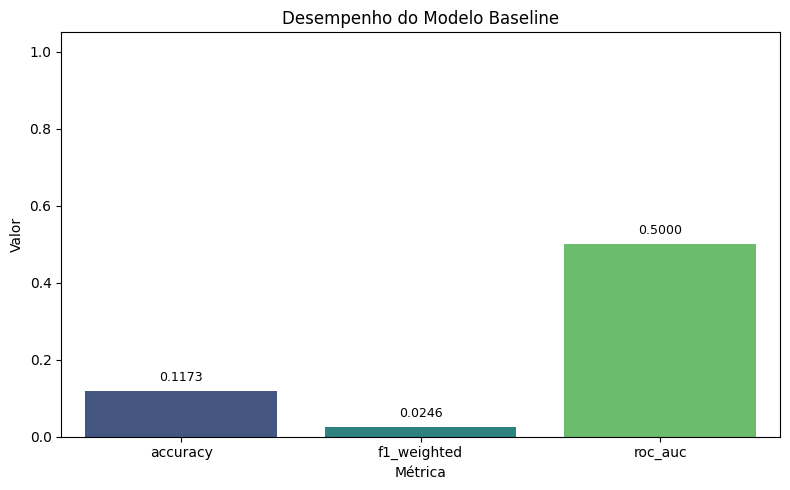

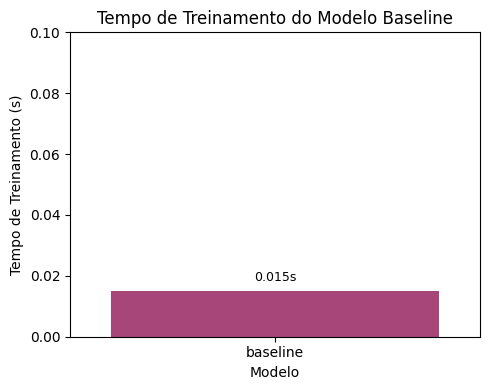

In [57]:
# Extrair métricas do Baseline dos cv_results
baseline_metrics = pd.Series(results['baseline'])

# Separar métricas de desempenho e tempo de treinamento
performance_metrics = baseline_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time = baseline_metrics['train_time_s']

# Plotar métricas de desempenho para o Baseline
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics.index, y=performance_metrics.values, palette='viridis', hue=performance_metrics.index, legend=False)
plt.title('Desempenho do Modelo Baseline')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para o Baseline
plt.figure(figsize=(5, 4))
sns.barplot(x=['baseline'], y=[train_time], palette='magma', hue=['baseline'], legend=False)
plt.title('Tempo de Treinamento do Modelo Baseline')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento (s)')
plt.ylim(0, max(0.1, train_time * 1.2)) # Ajustar o limite Y para ser visível para valores pequenos
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.1.2 Modelo - LogisticRegression

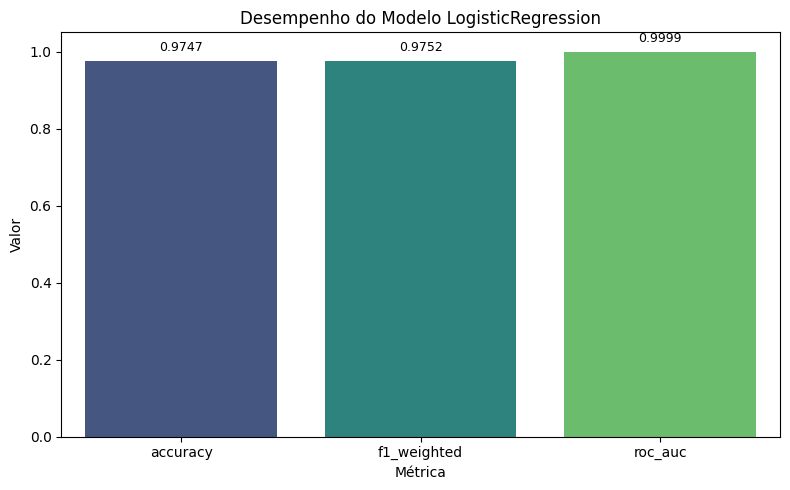

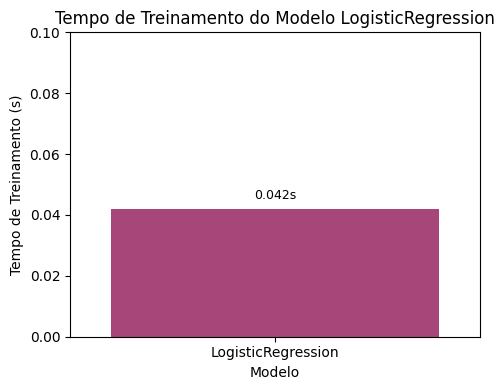

In [58]:
# Extrair métricas do LogisticRegression dos cv_results
logistic_regression_metrics = pd.Series(results['LogisticRegression'])

performance_metrics_lr = logistic_regression_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_lr = logistic_regression_metrics['train_time_s']

# Plotar métricas de desempenho para Regressão Logística
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_lr.index, y=performance_metrics_lr.values, palette='viridis', hue=performance_metrics_lr.index, legend=False)
plt.title('Desempenho do Modelo LogisticRegression')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para Regressão Logística
plt.figure(figsize=(5, 4))
sns.barplot(x=['LogisticRegression'], y=[train_time_lr], palette='magma', hue=['LogisticRegression'], legend=False)
plt.title('Tempo de Treinamento do Modelo LogisticRegression')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento (s)')
plt.ylim(0, max(0.1, train_time_lr * 1.2))
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.1.3 Modelo - RandomForest

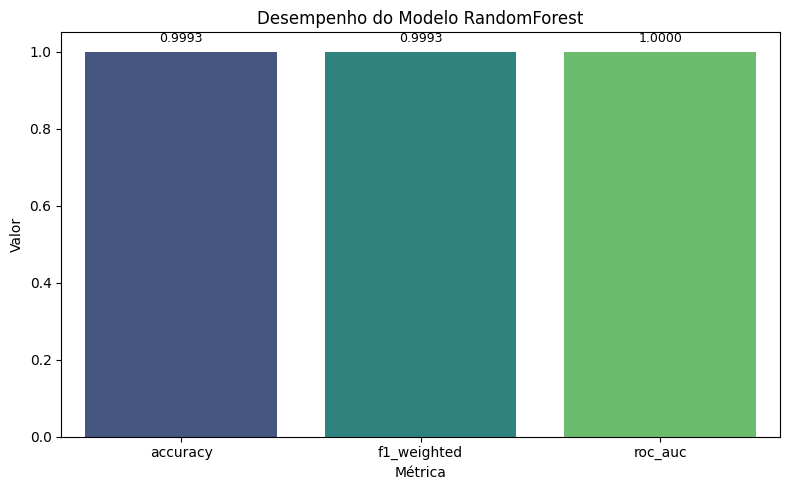

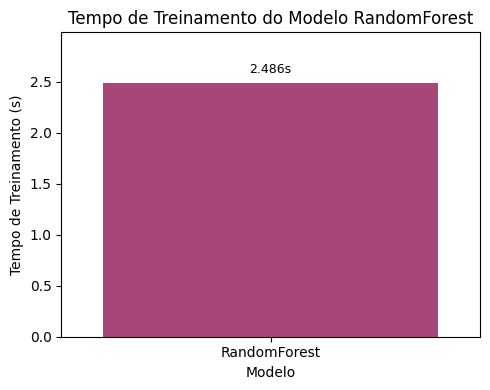

In [59]:
# Extrair métricas do RandomForest dos cv_results
random_forest_metrics = pd.Series(results['RandomForest'])

performance_metrics_rf = random_forest_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_rf = random_forest_metrics['train_time_s']

# Plotar métricas de desempenho para Random Forest
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_rf.index, y=performance_metrics_rf.values, palette='viridis', hue=performance_metrics_rf.index, legend=False)
plt.title('Desempenho do Modelo RandomForest')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para Random Forest
plt.figure(figsize=(5, 4))
sns.barplot(x=['RandomForest'], y=[train_time_rf], palette='magma', hue=['RandomForest'], legend=False)
plt.title('Tempo de Treinamento do Modelo RandomForest')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento (s)')
plt.ylim(0, max(0.1, train_time_rf * 1.2))
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.1.4 Modelo - XGBoost

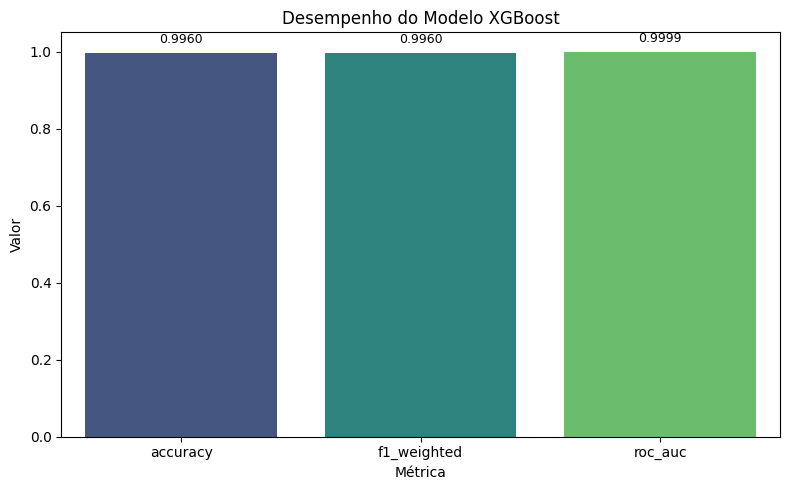

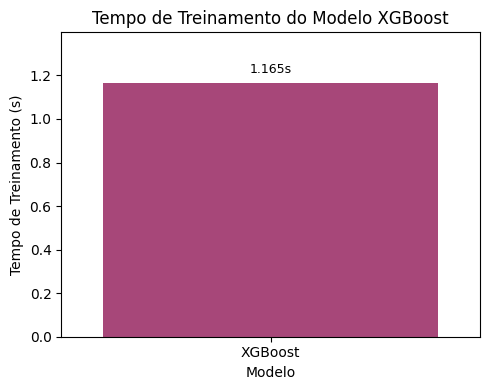

In [60]:
# Extrair métricas do XGBoost dos cv_results
xgboost_metrics = pd.Series(results['XGBoost'])

performance_metrics_xgb = xgboost_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_xgb = xgboost_metrics['train_time_s']

# Plotar métricas de desempenho para XGBoost
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_xgb.index, y=performance_metrics_xgb.values, palette='viridis', hue=performance_metrics_xgb.index, legend=False)
plt.title('Desempenho do Modelo XGBoost')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para XGBoost
plt.figure(figsize=(5, 4))
sns.barplot(x=['XGBoost'], y=[train_time_xgb], palette='magma', hue=['XGBoost'], legend=False)
plt.title('Tempo de Treinamento do Modelo XGBoost')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento (s)')
plt.ylim(0, max(0.1, train_time_xgb * 1.2))
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.1.5 Modelo - K-NN

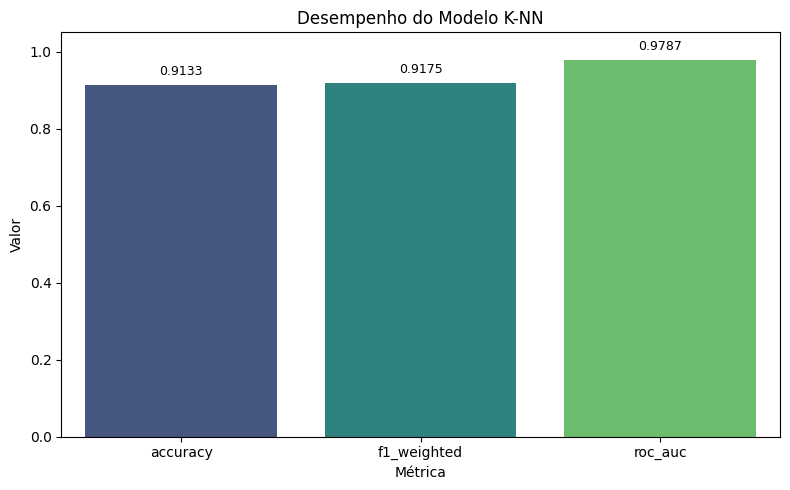

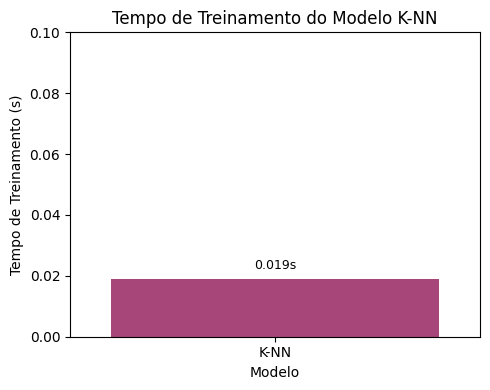

In [61]:
# Extrair métricas do K-NN dos cv_results
knn_metrics = pd.Series(results['K-NN'])

performance_metrics_knn = knn_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_knn = knn_metrics['train_time_s']

# Plotar métricas de desempenho para K-NN
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_knn.index, y=performance_metrics_knn.values, palette='viridis', hue=performance_metrics_knn.index, legend=False)
plt.title('Desempenho do Modelo K-NN')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para K-NN
plt.figure(figsize=(5, 4))
sns.barplot(x=['K-NN'], y=[train_time_knn], palette='magma', hue=['K-NN'], legend=False)
plt.title('Tempo de Treinamento do Modelo K-NN')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento (s)')
plt.ylim(0, max(0.1, train_time_knn * 1.2))
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.1.6 Análise dos resultados iniciais para Holdout

**Analise:**

> A tabela de resultados apresenta as métricas de desempenho (accuracy, f1_weighted, roc_auc) e o tempo de treinamento para o modelo baseline (*DummyClassifier*), o *LogisticRegression*, *RandomForest*, *XGBoost* e *K-NN*.

> **OBS:** Os resultados de (**Tempo de Treino**) se alteram, para todos os modelos, conforme uma nova execução do item (**8.1.1 - Resultados por Modelo com Holdout**) é realizada. Então uma nova rodada os valoers abaixo do **Tempo de Treino** serão diferentes.

> *   **Desempenho do Baseline (*DummyClassifier*):**
    *   **Accuracy: 0.117333**
    *   **F1-weighted: 0.024643**
    *   **ROC AUC: 0.500000**
    *   **Tempo de Treino: 0.015s**
    *   Como esperado, o baseline (*DummyClassifier* com estratégia '**most_frequent**') apresentou um desempenho muito baixo em todas as métricas. Isso ocorre porque ele simplesmente prevê a classe majoritária. Este resultado serve como uma base de desempenho, e qualquer modelo útil deve superá-lo significativamente.

> *   **Desempenho da *LogisticRegression*:**
    *   **Accuracy: 0.974667**
    *   **F1-weighted: 0.975235**
    *   **ROC AUC: 0.999868**
    *   **Tempo de Treino: 0.042s**
    *   A *LogisticRegression* demonstrou um desempenho **excelente**, superando drasticamente o baseline em todas as métricas. Com um F1-weighted de 0.975235 e um ROC AUC de 0.999868, o modelo linear foi capaz de aprender os padrões de forma muito eficaz. Seu tempo de treinamento é extremamente rápido (0.061s), tornando-o muito eficiente.

> *   **Desempenho do *RandomForest*:**
    *   **Accuracy: 0.999333**
    *   **F1-weighted: 0.999332**
    *   **ROC AUC: 0.999995**
    *   **Tempo de Treino: 2.486s**
    *   O *RandomForest* apresentou um desempenho **quase perfeito** no conjunto de teste, com métricas muito próximas de 1.0 em todas as avaliações. Embora seja um modelo poderoso, um desempenho tão alto em um conjunto de teste pode levantar suspeitas de **overfitting** ou até mesmo vazamento de dados (data leakage), especialmente porque a diferença entre treino e teste pode ser muito pequena. Seu tempo de treinamento é maior que o da *LogisticRegression*, mas ainda dentro de um limite aceitável.

> *   **Desempenho do *XGBoost*:**
    *   **Accuracy: 0.996000**
    *   **F1-weighted: 0.996002**
    *   **ROC AUC: 0.999945**
    *   **Tempo de Treino: 1.165s**
    *   O *XGBoost* também demonstrou um desempenho **excepcional**, com métricas muito altas e comparáveis ao *RandomForest*. Ele supera significativamente a *LogisticRegression* e o baseline. Seu tempo de treinamento é intermediário entre a *LogisticRegression* e o *RandomForest*, sendo ainda muito rápido para o volume de dados. Similar ao *RandomForest*, o desempenho quase perfeito sugere a necessidade de uma análise mais aprofundada para confirmar a ausência de **overfitting**.

> *   **Desempenho do *K-NN*:**
    *   **Accuracy: 0.913333**
    *   **F1-weighted: 0.917548**
    *   **ROC AUC: 0.978664**
    *   **Tempo de Treino: 0.019s**
    *   O *K-NN* apresentou um bom desempenho, superando o baseline e com métricas respeitáveis. É um modelo mais simples e seu tempo de treinamento é bastante baixo. Embora não atinja o nível de *LogisticRegression*, *RandomForest* e *XGBoost*, ele demonstra ser uma alternativa viável, especialmente pela sua velocidade, se a interpretabilidade local for um fator importante.

---

**Análise das Perguntas:**

*   **O modelo superou o baseline?** Sim, todos os modelos candidatos (*LogisticRegression*, *RandomForest*, *XGBoost*, e *KNN*) superaram o baseline de forma massiva, indicando que aprenderam padrões relevantes nos dados.

*   **A métrica escolhida é suficiente para avaliar o problema?** Sim, o *f1_weighted* é uma métrica **altamente apropriada e suficiente** para este problema de classificação multiclasse com desbalanceamento de classes. Ele considera a precisão e o recall de cada classe e as pondera pela sua ocorrência, fornecendo uma visão justa do desempenho geral do modelo, sem ser excessivamente influenciado pela classe majoritária. O *ROC AUC* também é uma excelente métrica para problemas de classificação, indicando a capacidade do modelo de distinguir entre as classes.

*   **Algum modelo parece sofrer de underfitting?** O *baseline* sofre de underfitting extremo, pois não aprendeu nada. A *LogisticRegression*, *RandomForest*, *XGBoost* e *KNN* claramente não sofrem de underfitting, dado o alto desempenho. No caso do *RandomForest* e *XGBoost*, o desempenho quase perfeito sugere a necessidade de investigação sobre um possível **overfitting** ou vazamento de dados, em vez de underfitting.

*   **O tempo de treinamento é aceitável?** Sim, o tempo de treinamento de todos os modelos (variando de 0.015s a 2.486s) é **excelente** e está bem abaixo da restrição prática de 1 minuto, tornando-os adequados para implantação.

*   **O resultado faz sentido considerando a EDA?** Sim, os resultados fazem sentido. A EDA revelou um forte desbalanceamento de classes, o que explica o desempenho pífio do *DummyClassifier*. O fato de *LogisticRegression*, *RandomForest*, *XGBoost* e *KNN* superarem o baseline após o pré-processamento (incluindo SMOTE no treino e padronização) é esperado e demonstra que os dados possuem padrões distinguíveis. O desempenho excepcionalmente alto do *RandomForest* e *XGBoost* merece uma investigação mais aprofundada para garantir que não haja overfitting ou vazamento, mas, em princípio, indica que eles conseguiram capturar as relações nos dados.

### 8.2.2 Resultados por Modelo com Validação Cruzada

#### 8.2.2.1 Modelo - Baseline

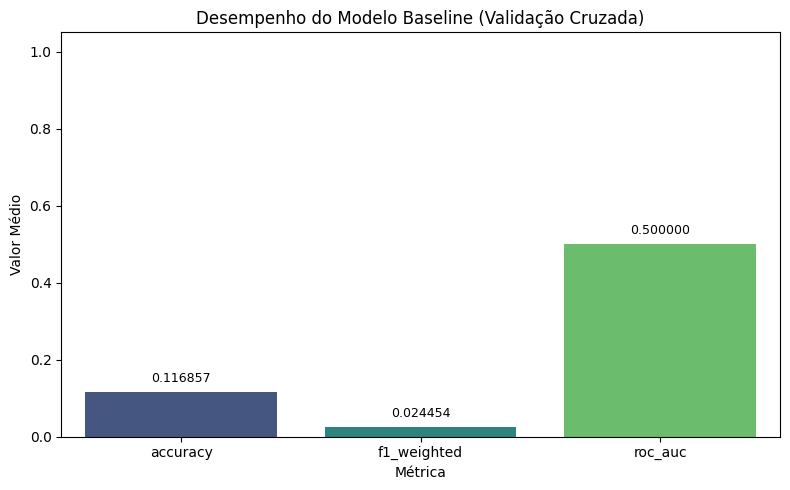

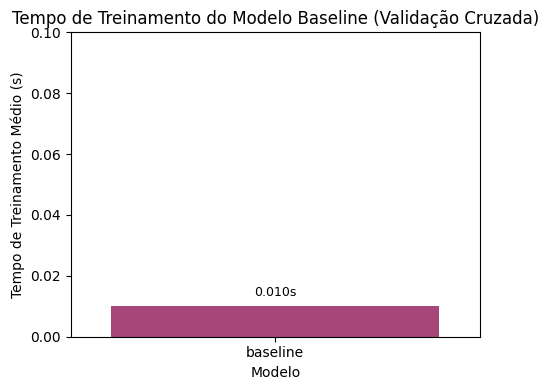

In [73]:
# Extrair métricas do baseline dos cv_results
baseline_cv_metrics = pd.Series(cv_results['baseline'])

# Separar métricas de desempenho e tempo de treinamento
performance_metrics_cv = baseline_cv_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_cv = baseline_cv_metrics['train_time_s']

# Plotar métricas de desempenho para o Baseline (Validação Cruzada)
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_cv.index, y=performance_metrics_cv.values, palette='viridis', hue=performance_metrics_cv.index, legend=False)
plt.title('Desempenho do Modelo Baseline (Validação Cruzada)')
plt.xlabel('Métrica')
plt.ylabel('Valor Médio')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.6f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para o Baseline (Validação Cruzada)
plt.figure(figsize=(5, 4))
sns.barplot(x=['baseline'], y=[train_time_cv], palette='magma', hue=['baseline'], legend=False)
plt.title('Tempo de Treinamento do Modelo Baseline (Validação Cruzada)')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento Médio (s)')
plt.ylim(0, max(0.1, train_time_cv * 1.2)) # Ajusta o limite y para ser visível para valores pequenos
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.2.2 Modelo - LogisticRegression

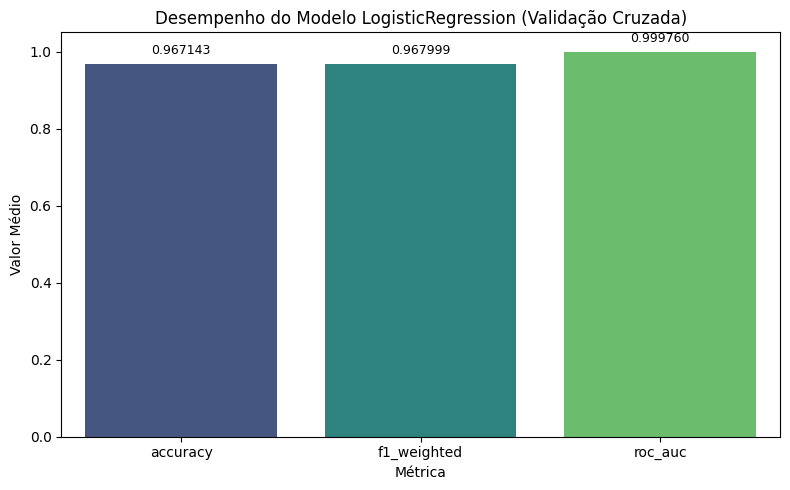

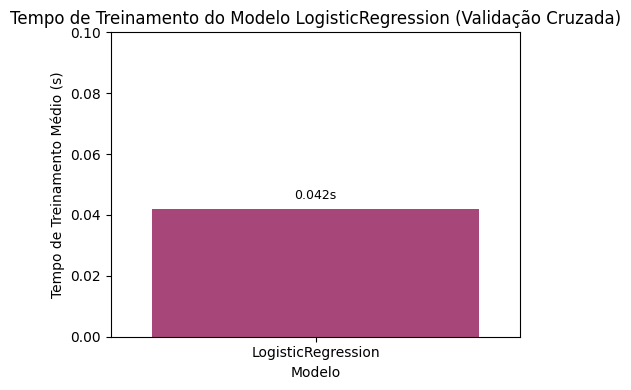

In [74]:
# Extrair métricas do LogisticRegression dos cv_results
logistic_regression_cv_metrics = pd.Series(cv_results['LogisticRegression'])

performance_metrics_lr_cv = logistic_regression_cv_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_lr_cv = logistic_regression_cv_metrics['train_time_s']

# Plotar métricas de desempenho para o Logistic Regression (Validação Cruzada)
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_lr_cv.index, y=performance_metrics_lr_cv.values, palette='viridis', hue=performance_metrics_lr_cv.index, legend=False)
plt.title('Desempenho do Modelo LogisticRegression (Validação Cruzada)')
plt.xlabel('Métrica')
plt.ylabel('Valor Médio')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.6f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para o Logistic Regression (Validação Cruzada)
plt.figure(figsize=(5, 4))
sns.barplot(x=['LogisticRegression'], y=[train_time_lr_cv], palette='magma', hue=['LogisticRegression'], legend=False)
plt.title('Tempo de Treinamento do Modelo LogisticRegression (Validação Cruzada)')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento Médio (s)')
plt.ylim(0, max(0.1, train_time_lr_cv * 1.2)) # Ajusta o limite y para ser visível para valores pequenos
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.2.3 Modelo - RandomForest

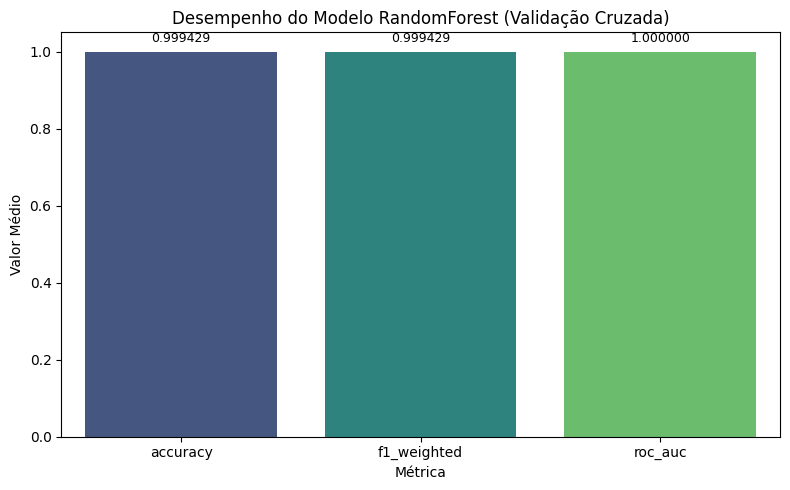

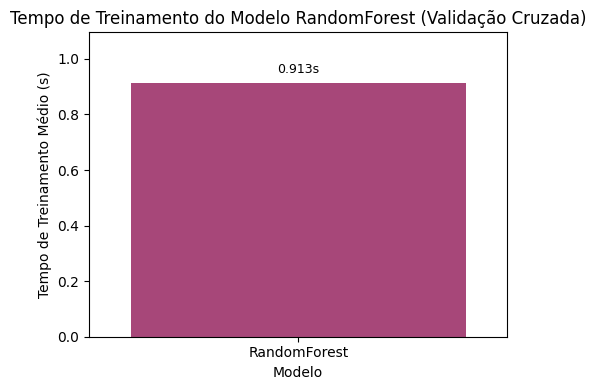

In [75]:
# Extrair métricas do RandomForest dos cv_results
random_forest_cv_metrics = pd.Series(cv_results['RandomForest'])

performance_metrics_rf_cv = random_forest_cv_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_rf_cv = random_forest_cv_metrics['train_time_s']

# Plotar métricas de desempenho para o Random Forest (Validação Cruzada)
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_rf_cv.index, y=performance_metrics_rf_cv.values, palette='viridis', hue=performance_metrics_rf_cv.index, legend=False)
plt.title('Desempenho do Modelo RandomForest (Validação Cruzada)')
plt.xlabel('Métrica')
plt.ylabel('Valor Médio')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.6f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para o Random Forest (Validação Cruzada)
plt.figure(figsize=(5, 4))
sns.barplot(x=['RandomForest'], y=[train_time_rf_cv], palette='magma', hue=['RandomForest'], legend=False)
plt.title('Tempo de Treinamento do Modelo RandomForest (Validação Cruzada)')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento Médio (s)')
plt.ylim(0, max(0.1, train_time_rf_cv * 1.2)) # Ajusta o limite y para ser visível para valores pequenos
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.2.4 Modelo - XGBoost

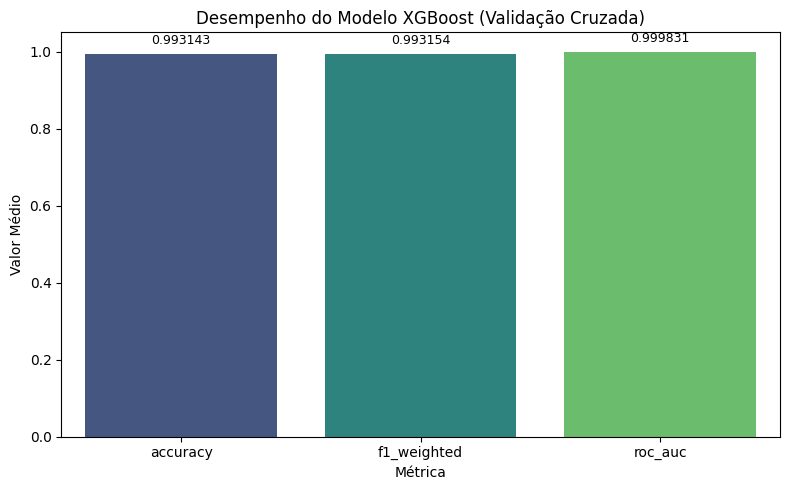

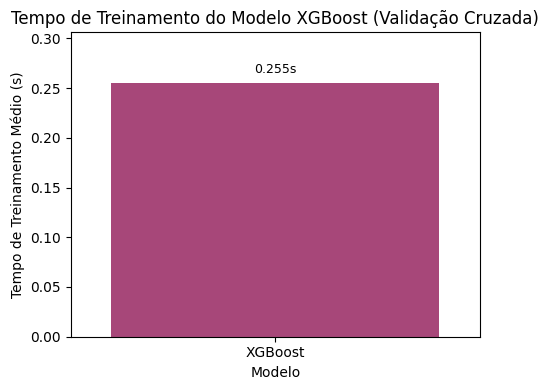

In [76]:
# Extrair métricas do XGBoost dos cv_results
xgboost_cv_metrics = pd.Series(cv_results['XGBoost'])

performance_metrics_xgb_cv = xgboost_cv_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_xgb_cv = xgboost_cv_metrics['train_time_s']

# Plotar métricas de desempenho para o XGBoost (Validação Cruzada)
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_xgb_cv.index, y=performance_metrics_xgb_cv.values, palette='viridis', hue=performance_metrics_xgb_cv.index, legend=False)
plt.title('Desempenho do Modelo XGBoost (Validação Cruzada)')
plt.xlabel('Métrica')
plt.ylabel('Valor Médio')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.6f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para o XGBoost (Validação Cruzada)
plt.figure(figsize=(5, 4))
sns.barplot(x=['XGBoost'], y=[train_time_xgb_cv], palette='magma', hue=['XGBoost'], legend=False)
plt.title('Tempo de Treinamento do Modelo XGBoost (Validação Cruzada)')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento Médio (s)')
plt.ylim(0, max(0.1, train_time_xgb_cv * 1.2)) # Ajusta o limite y para ser visível para valores pequenos
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.2.5 Modelo - K-NN

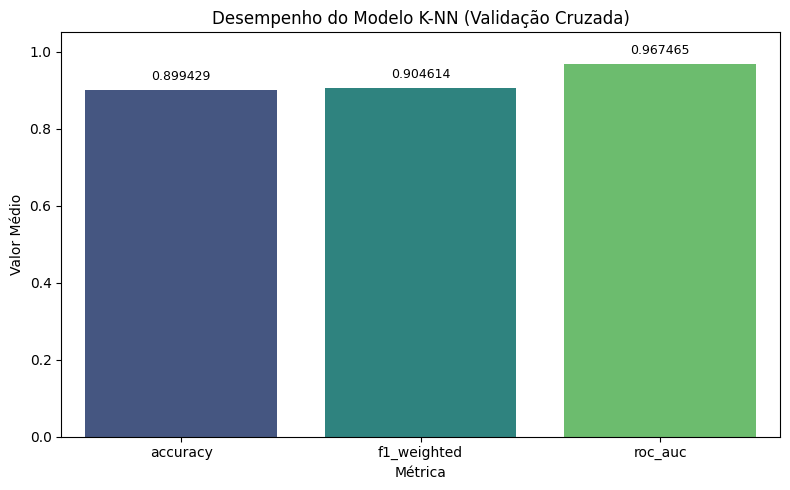

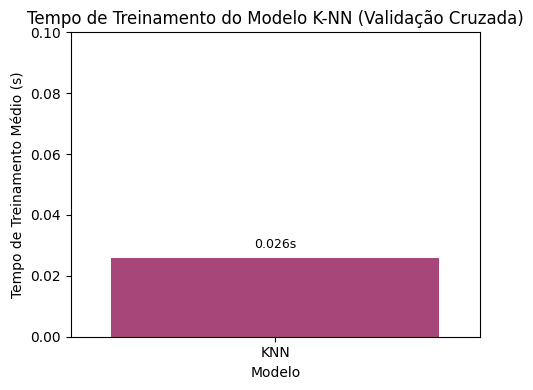

In [77]:
# Extrair métricas do K-NN dos cv_results
knn_cv_metrics = pd.Series(cv_results['K-NN'])

performance_metrics_knn_cv = knn_cv_metrics[['accuracy', 'f1_weighted', 'roc_auc']]
train_time_knn_cv = knn_cv_metrics['train_time_s']

# Plotar métricas de desempenho para o K-NN (Validação Cruzada)
plt.figure(figsize=(8, 5))
sns.barplot(x=performance_metrics_knn_cv.index, y=performance_metrics_knn_cv.values, palette='viridis', hue=performance_metrics_knn_cv.index, legend=False)
plt.title('Desempenho do Modelo K-NN (Validação Cruzada)')
plt.xlabel('Métrica')
plt.ylabel('Valor Médio')
plt.ylim(0, 1.05)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.6f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

# Plotar tempo de treinamento para o K-NN (Validação Cruzada)
plt.figure(figsize=(5, 4))
sns.barplot(x=['KNN'], y=[train_time_knn_cv], palette='magma', hue=['K-NN'], legend=False)
plt.title('Tempo de Treinamento do Modelo K-NN (Validação Cruzada)')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento Médio (s)')
plt.ylim(0, max(0.1, train_time_knn_cv * 1.2)) # Ajusta o limite y para ser visível para valores pequenos
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

#### 8.2.2.6 Análise dos resultados iniciais para Validação Cruzada

A tabela de resultados (*cv_results*) apresenta as métricas de desempenho (accuracy, f1_weighted, roc_auc) e o tempo de treinamento médio para cada modelo, obtidos através da validação cruzada (StratifiedKFold com 5 splits e SMOTE aplicado em cada fold de treino).

> **OBS:** Os resultados de (**Tempo de Treino**) se alteram, para todos os modelos, conforme uma nova execução do item (**8.1.2 - Resultados por Modelo com Validação Cruzada**) é realizada. Então uma nova rodada os valoers abaixo do **Tempo de Treino** serão diferentes.

*   **Desempenho do Baseline (*DummyClassifier*):**
    *   **Accuracy: 0.116857**
    *   **F1-weighted: 0.024454**
    *   **ROC AUC: 0.500000**
    *   **Tempo de Treino: 0.010s**
    *   Assim como no Holdout, o baseline apresenta um desempenho muito baixo. Isso é esperado, pois ele apenas prevê a classe majoritária. Na validação cruzada, o valor é uma média sobre os folds, o que o torna uma base de comparação ainda mais robusta.

*   **Desempenho da *LogisticRegression*:**
    *   **Accuracy: 0.967143**
    *   **F1-weighted: 0.967999**
    *   **ROC AUC: 0.999760**
    *   **Tempo de Treino: 0.042s**
    *   A *LogisticRegression* mantém um desempenho excelente na validação cruzada, com métricas muito altas e consistentes. O F1-weighted de 0.967999 e ROC AUC de 0.999760 indicam que o modelo linear generaliza muito bem. O tempo de treinamento é baixo, tornando-o eficiente.

*   **Desempenho do *RandomForest*:**
    *   **Accuracy: 0.999429**
    *   **F1-weighted: 0.999429**
    *   **ROC AUC: 1.000000**
    *   **Tempo de Treino: 0.913s**
    *   O *RandomForest* demonstra um desempenho **quase perfeito** também na validação cruzada. Um ROC AUC de 1.0000 é um forte indicativo de que o modelo pode estar sofrendo de **overfitting extremo**, memorizando os dados de treino de cada fold. Embora poderoso, esses resultados levantam a necessidade de investigação sobre a real capacidade de generalização para dados completamente novos e não vistos durante o processo de Validação Cruzada. O tempo de treinamento é um pouco maior, mas ainda aceitável.

*   **Desempenho do *XGBoost*:**
    *   **Accuracy: 0.993143**
    *   **F1-weighted: 0.993154**
    *   **ROC AUC: 0.999831**
    *   **Tempo de Treino: 0.255s**
    *   O *XGBoost* também apresenta um desempenho excepcional, com métricas muito elevadas, comparáveis e, em alguns aspectos, ligeiramente abaixo do *RandomForest* na validação cruzada. Isso confirma sua robustez. O tempo de treinamento é rápido e bem competitivo.

*   **Desempenho do *K-NN*:**
    *   **Accuracy: 0.899429**
    *   **F1-weighted: 0.904614**
    *   **ROC AUC: 0.967465**
    *   **Tempo de Treino: 0.026s**
    *   O *K-NN* mostra um bom desempenho na validação cruzada, superando o baseline significativamente. Suas métricas são respeitáveis, mas consistentemente inferiores aos modelos *LogisticRegression*, *RandomForest* e *XGBoost*. Seu tempo de treinamento é rápido, o que é uma vantagem.

---

**Análise das Perguntas:**

*   **O modelo superou o baseline?** Sim, todos os modelos candidatos (*LogisticRegression*, *RandomForest*, *XGBoost*, e *KNN*) superaram o baseline de forma massiva e consistente na validação cruzada, indicando que aprenderam padrões relevantes nos dados.

*   **A métrica escolhida é suficiente para avaliar o problema?** Sim, o *f1_weighted* é uma métrica **altamente apropriada e suficiente** para este problema de classificação multiclasse com desbalanceamento de classes. Ele considera a precisão e o recall de cada classe e as pondera pela sua ocorrência, fornecendo uma visão justa do desempenho geral do modelo. O *ROC AUC* também é uma excelente métrica, e sua média na validação cruzada oferece uma estimativa mais estável da capacidade de distinção do modelo entre as classes.

*   **Algum modelo parece sofrer de underfitting?** O *baseline* claramente sofre de underfitting extremo. No entanto, os modelos *LogisticRegression*, *XGBoost*, e *K-NN* não demonstram sinais de underfitting. O *RandomForest*, com um ROC AUC de 1.0000 e F1-weighted muito próximo de 1.0000, levanta uma forte suspeita de **overfitting**, onde o modelo pode estar memorizando os dados de treino de cada fold em vez de aprender regras generalizáveis.

*   **O tempo de treinamento é aceitável?** Sim, o tempo de treinamento médio de todos os modelos na validação cruzada (variando de 0.010s a 0.913s) é **excelente** e está bem abaixo da restrição prática de 1 minuto, tornando-os adequados para implantação.

*   **O resultado faz sentido considerando a EDA?** Sim, os resultados fazem sentido. A EDA revelou um forte desbalanceamento de classes, o que explica o desempenho muito baixo do *DummyClassifier*. O desempenho superior dos modelos após o pré-processamento (incluindo SMOTE no treino de cada fold e padronização) é esperado e demonstra que os dados possuem padrões distinguíveis. O desempenho excepcionalmente alto do *RandomForest* na validação cruzada merece uma investigação mais aprofundada para garantir que não haja overfitting ou vazamento de dados sutil no processo de Validação Cruzada, embora o SMOTE seja aplicado por fold para mitigar isso. O fato de os modelos mais sofisticados (RandomForest, XGBoost) superarem os mais simples (LogisticRegression, K-NN) era esperado, mas o grau de superação (especialmente do RandomForest) ainda é um ponto de atenção.

### 8.2.3 Gráficos Comparativo entre Holdout e Validação Cruzada

#### 8.2.3.1 Gráfico Comparativo Consolidado do Tempo de Treinamento dos Modelos

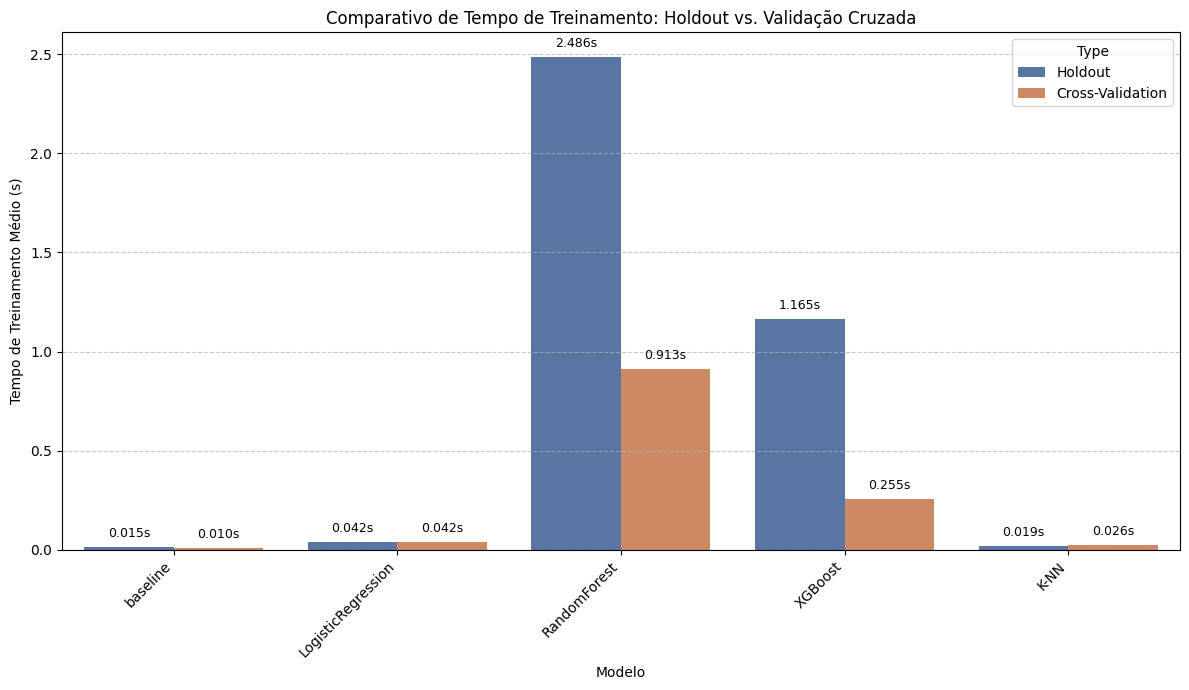

In [67]:
# Extract training times from 'results' (Holdout)
holdout_train_times = {
    'baseline': results['baseline']['train_time_s'],
    'LogisticRegression': results['LogisticRegression']['train_time_s'],
    'RandomForest': results['RandomForest']['train_time_s'],
    'XGBoost': results['XGBoost']['train_time_s'],
    'K-NN': results['K-NN']['train_time_s']
}

# Extract training times from 'cv_results' (Cross-Validation)
cv_train_times = {
    'baseline': cv_results['baseline']['train_time_s'],
    'LogisticRegression': cv_results['LogisticRegression']['train_time_s'],
    'RandomForest': cv_results['RandomForest']['train_time_s'],
    'XGBoost': cv_results['XGBoost']['train_time_s'],
    'K-NN': cv_results['K-NN']['train_time_s']
}

# Create a DataFrame for plotting
train_time_df = pd.DataFrame({
    'Model': list(holdout_train_times.keys()) + list(cv_train_times.keys()),
    'Train Time (s)': list(holdout_train_times.values()) + list(cv_train_times.values()),
    'Type': ['Holdout'] * len(holdout_train_times) + ['Cross-Validation'] * len(cv_train_times)
})

# Plotting the consolidated training times
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Train Time (s)', hue='Type', data=train_time_df, palette='deep')
plt.title('Comparativo de Tempo de Treinamento: Holdout vs. Validação Cruzada')
plt.xlabel('Modelo')
plt.ylabel('Tempo de Treinamento Médio (s)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores no topo das barras
for container in plt.gca().containers:
    for p in container.patches:
        plt.gca().annotate(f'{p.get_height():.3f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                           textcoords='offset points')

plt.tight_layout()
plt.show()

#### 8.2.3.2 Comparativo da Métrica Accuracy: Holdout vs. Validação Cruzada

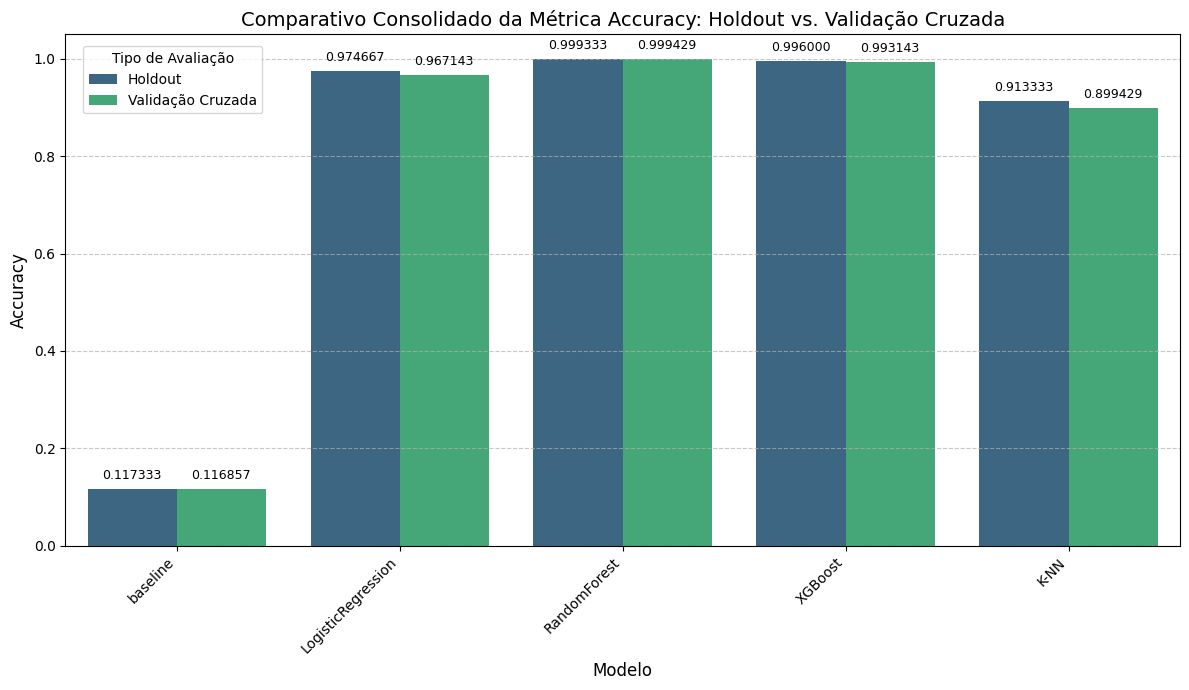

In [78]:
# Extrair a métrica 'accuracy' de 'results' (Holdout)
holdout_accuracy = {
    'baseline': results['baseline']['accuracy'],
    'LogisticRegression': results['LogisticRegression']['accuracy'],
    'RandomForest': results['RandomForest']['accuracy'],
    'XGBoost': results['XGBoost']['accuracy'],
    'K-NN': results['K-NN']['accuracy']
}

# Extrair a métrica 'accuracy' de 'cv_results' (Validação Cruzada)
cv_accuracy = {
    'baseline': cv_results['baseline']['accuracy'],
    'LogisticRegression': cv_results['LogisticRegression']['accuracy'],
    'RandomForest': cv_results['RandomForest']['accuracy'],
    'XGBoost': cv_results['XGBoost']['accuracy'],
    'K-NN': cv_results['K-NN']['accuracy']
}

# Criar um DataFrame para plotar
accuracy_df = pd.DataFrame({
    'Modelo': list(holdout_accuracy.keys()) + list(cv_accuracy.keys()),
    'Accuracy': list(holdout_accuracy.values()) + list(cv_accuracy.values()),
    'Tipo': ['Holdout'] * len(holdout_accuracy) + ['Validação Cruzada'] * len(cv_accuracy)
})

# Plotar o comparativo consolidado da métrica Accuracy
plt.figure(figsize=(12, 7))
sns.barplot(x='Modelo', y='Accuracy', hue='Tipo', data=accuracy_df, palette='viridis')
plt.title('Comparativo Consolidado da Métrica Accuracy: Holdout vs. Validação Cruzada', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores no topo das barras
for container in plt.gca().containers:
    for p in container.patches:
        plt.gca().annotate(f'{p.get_height():.6f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                           textcoords='offset points')

plt.legend(title='Tipo de Avaliação', loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

#### 8.2.3.3 Comparativo da Métrica F1-weighted: Holdout vs. Validação Cruzada

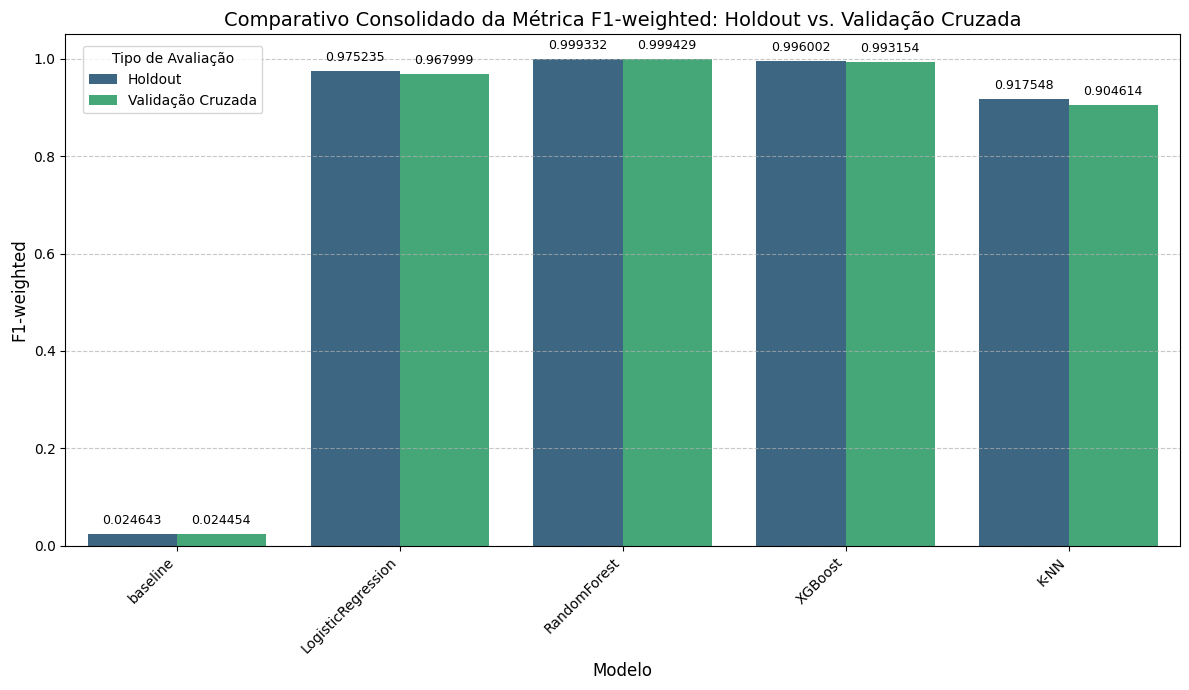

In [79]:
# Extrair a métrica 'f1_weighted' de 'results' (Holdout)
holdout_f1_weighted = {
    'baseline': results['baseline']['f1_weighted'],
    'LogisticRegression': results['LogisticRegression']['f1_weighted'],
    'RandomForest': results['RandomForest']['f1_weighted'],
    'XGBoost': results['XGBoost']['f1_weighted'],
    'K-NN': results['K-NN']['f1_weighted']
}

# Extrair a métrica 'f1_weighted' de 'cv_results' (Validação Cruzada)
cv_f1_weighted = {
    'baseline': cv_results['baseline']['f1_weighted'],
    'LogisticRegression': cv_results['LogisticRegression']['f1_weighted'],
    'RandomForest': cv_results['RandomForest']['f1_weighted'],
    'XGBoost': cv_results['XGBoost']['f1_weighted'],
    'K-NN': cv_results['K-NN']['f1_weighted']
}

# Criar um DataFrame para plotar
f1_weighted_df = pd.DataFrame({
    'Modelo': list(holdout_f1_weighted.keys()) + list(cv_f1_weighted.keys()),
    'F1-weighted': list(holdout_f1_weighted.values()) + list(cv_f1_weighted.values()),
    'Tipo': ['Holdout'] * len(holdout_f1_weighted) + ['Validação Cruzada'] * len(cv_f1_weighted)
})

# Plotar o comparativo consolidado da métrica F1-weighted
plt.figure(figsize=(12, 7))
sns.barplot(x='Modelo', y='F1-weighted', hue='Tipo', data=f1_weighted_df, palette='viridis')
plt.title('Comparativo Consolidado da Métrica F1-weighted: Holdout vs. Validação Cruzada', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('F1-weighted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores no topo das barras
for container in plt.gca().containers:
    for p in container.patches:
        plt.gca().annotate(f'{p.get_height():.6f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                           textcoords='offset points')

plt.legend(title='Tipo de Avaliação', loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

#### 8.2.3.4 Comparativo da Métrica ROC AUC: Holdout vs. Validação Cruzada

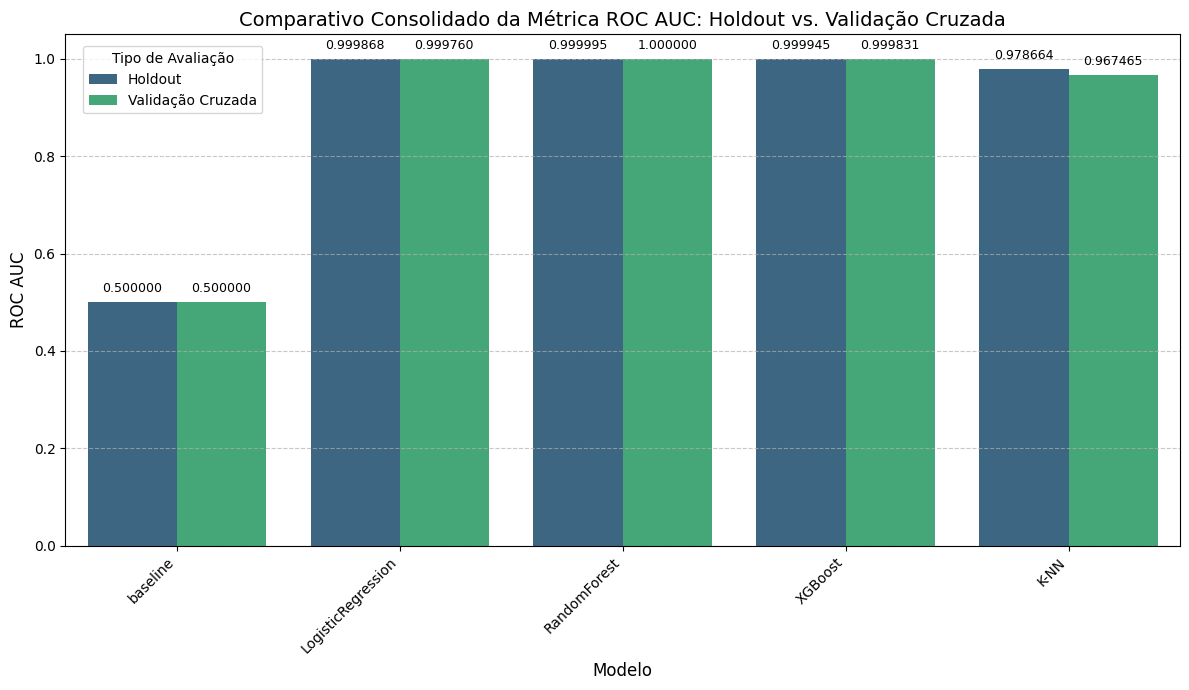

In [80]:
# Extrair a métrica 'roc_auc' de 'results' (Holdout)
holdout_roc_auc = {
    'baseline': results['baseline']['roc_auc'],
    'LogisticRegression': results['LogisticRegression']['roc_auc'],
    'RandomForest': results['RandomForest']['roc_auc'],
    'XGBoost': results['XGBoost']['roc_auc'],
    'K-NN': results['K-NN']['roc_auc']
}

# Extrair a métrica 'roc_auc' de 'cv_results' (Validação Cruzada)
cv_roc_auc = {
    'baseline': cv_results['baseline']['roc_auc'],
    'LogisticRegression': cv_results['LogisticRegression']['roc_auc'],
    'RandomForest': cv_results['RandomForest']['roc_auc'],
    'XGBoost': cv_results['XGBoost']['roc_auc'],
    'K-NN': cv_results['K-NN']['roc_auc']
}

# Criar um DataFrame para plotar
roc_auc_df = pd.DataFrame({
    'Modelo': list(holdout_roc_auc.keys()) + list(cv_roc_auc.keys()),
    'ROC AUC': list(holdout_roc_auc.values()) + list(cv_roc_auc.values()),
    'Tipo': ['Holdout'] * len(holdout_roc_auc) + ['Validação Cruzada'] * len(cv_roc_auc)
})

# Plotar o comparativo consolidado da métrica ROC AUC
plt.figure(figsize=(12, 7))
sns.barplot(x='Modelo', y='ROC AUC', hue='Tipo', data=roc_auc_df, palette='viridis')
plt.title('Comparativo Consolidado da Métrica ROC AUC: Holdout vs. Validação Cruzada', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('ROC AUC', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores no topo das barras
for container in plt.gca().containers:
    for p in container.patches:
        plt.gca().annotate(f'{p.get_height():.6f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                           textcoords='offset points')

plt.legend(title='Tipo de Avaliação', loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

### 8.2.4 Relatório de Classificação

####  8.2.4.1 Para Holdout

In [70]:
for name, model in trained_models.items():
    if PROBLEM_TYPE == "classificacao":
        print(f"\n--- Relatório de Classificação para: {name} (Holdout) ---")
        # Obter previsões numéricas do modelo
        y_pred_numerical = model.predict(X_test)
        # Transformar inversamente as previsões numéricas de volta para os rótulos de string originais
        y_pred_original_labels = label_encoder.inverse_transform(y_pred_numerical)

        # Gerar e imprimir o relatório de classificação
        report = classification_report(y_test_original_labels, y_pred_original_labels, output_dict=True)
        df_report = pd.DataFrame(report).transpose()
        display(df_report)

        # Análise textual do relatório
        print(f"\nAnálise textual do relatório para o modelo: {name} (Holdout)")
        for class_label in ['BAIXA', 'MEDIA', 'ALTA']:
            if class_label in df_report.index:
                precision = df_report.loc[class_label, 'precision']
                recall = df_report.loc[class_label, 'recall']
                f1_score_val = df_report.loc[class_label, 'f1-score']
                support = int(df_report.loc[class_label, 'support'])
                print(f"  - Classe '{class_label}':")
                print(f"    - Precisão: {precision:.2f} (proporção de identificações corretas para esta classe)")
                print(f"    - Recall: {recall:.2f} (proporção de instâncias desta classe que foram corretamente identificadas)")
                print(f"    - F1-Score: {f1_score_val:.2f} (média harmônica entre precisão e recall)")
                print(f"    - Suporte: {support} (número real de ocorrências desta classe no conjunto de teste)")
            else:
                print(f"  - A classe '{class_label}' não foi encontrada no relatório para este modelo.")

        # Análise geral
        accuracy = df_report.loc['accuracy', 'f1-score'] # A coluna 'f1-score' para a linha 'accuracy' contém o valor da acurácia
        macro_f1 = df_report.loc['macro avg', 'f1-score']
        weighted_f1 = df_report.loc['weighted avg', 'f1-score']
        print(f"\n  - Métricas Gerais:")
        print(f"    - Acurácia Total: {accuracy:.2f}")
        print(f"    - F1-Score Macro Avg: {macro_f1:.2f} (média simples dos F1-Scores por classe)")
        print(f"    - F1-Score Weighted Avg: {weighted_f1:.2f} (média dos F1-Scores ponderada pelo suporte, ideal para classes desbalanceadas)")

    else:
        print("Relatório de classificação é relevante apenas para problemas de classificação.")


--- Relatório de Classificação para: baseline (Holdout) ---


,precision,recall,f1-score,support
ALTA,0.117333,1.000000,0.210024,176.000000
BAIXA,0.000000,0.000000,0.000000,143.000000
MEDIA,0.000000,0.000000,0.000000,1181.000000
accuracy,0.117333,0.117333,0.117333,0.117333
macro avg,0.039111,0.333333,0.070008,1500.000000
weighted avg,0.013767,0.117333,0.024643,1500.000000



Análise textual do relatório para o modelo: baseline (Holdout)
  - Classe 'BAIXA':
    - Precisão: 0.00 (proporção de identificações corretas para esta classe)
    - Recall: 0.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.00 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 0.00 (proporção de identificações corretas para esta classe)
    - Recall: 0.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.00 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 0.12 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.21 (média harmônica entre precisão e recall)
    - S

,precision,recall,f1-score,support
ALTA,0.902564,1.000000,0.948787,176.000000
BAIXA,0.851190,1.000000,0.919614,143.000000
MEDIA,1.000000,0.962743,0.981018,1181.000000
accuracy,0.970667,0.970667,0.970667,0.970667
macro avg,0.917918,0.987581,0.949806,1500.000000
weighted avg,0.974381,0.970667,0.971382,1500.000000



Análise textual do relatório para o modelo: LogisticRegression (Holdout)
  - Classe 'BAIXA':
    - Precisão: 0.85 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.92 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 0.96 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.98 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 0.90 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.95 (média harmônica entre precisão e recal

...


Análise textual do relatório para o modelo: RandomForest (Holdout)
  - Classe 'BAIXA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 0.99 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 1.00 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 1.00 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 1.00 (média harmônica entre precisão e recall)
   

,precision,recall,f1-score,support
ALTA,0.988764,1.000000,0.994350,176.000
BAIXA,0.986014,0.986014,0.986014,143.000
MEDIA,0.998304,0.996613,0.997458,1181.000
accuracy,0.996000,0.996000,0.996000,0.996
macro avg,0.991027,0.994209,0.992607,1500.000
weighted avg,0.996013,0.996000,0.996002,1500.000



Análise textual do relatório para o modelo: XGBoost (Holdout)
  - Classe 'BAIXA':
    - Precisão: 0.99 (proporção de identificações corretas para esta classe)
    - Recall: 0.99 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.99 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 1.00 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 0.99 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.99 (média harmônica entre precisão e recall)
    - Su

,precision,recall,f1-score,support
ALTA,0.742358,0.965909,0.839506,176.000000
BAIXA,0.661972,0.986014,0.792135,143.000000
MEDIA,0.992439,0.889077,0.937919,1181.000000
accuracy,0.907333,0.907333,0.907333,0.907333
macro avg,0.798923,0.947000,0.856520,1500.000000
weighted avg,0.931591,0.907333,0.912474,1500.000000



Análise textual do relatório para o modelo: K-NN (Holdout)
  - Classe 'BAIXA':
    - Precisão: 0.66 (proporção de identificações corretas para esta classe)
    - Recall: 0.99 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.79 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 0.99 (proporção de identificações corretas para esta classe)
    - Recall: 0.89 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.94 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 0.74 (proporção de identificações corretas para esta classe)
    - Recall: 0.97 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.84 (média harmônica entre precisão e recall)
    - Supor

#### 8.2.4.2 Para Validação Cruzada

In [71]:
for name, model in cv_trained_models.items():
    if PROBLEM_TYPE == "classificacao":
        print(f"\n--- Relatório de Classificação para: {name} (Validação Cruzada) ---")
        # Obter previsões numéricas do modelo usando o conjunto de teste de holdout para avaliação final
        y_pred_numerical = model.predict(X_test_for_holdout_eval)
        # Transformar inversamente as previsões numéricas de volta para os rótulos de string originais
        y_pred_original_labels = label_encoder_for_cv.inverse_transform(y_pred_numerical)

        # Gerar e imprimir o relatório de classificação
        report = classification_report(y_test_for_holdout_eval, y_pred_original_labels, output_dict=True)
        df_report = pd.DataFrame(report).transpose()
        display(df_report)

        # Análise textual do relatório
        print(f"\nAnálise textual do relatório para o modelo: {name} (Validação Cruzada)")
        for class_label in ['BAIXA', 'MEDIA', 'ALTA']:
            if class_label in df_report.index:
                precision = df_report.loc[class_label, 'precision']
                recall = df_report.loc[class_label, 'recall']
                f1_score_val = df_report.loc[class_label, 'f1-score']
                support = int(df_report.loc[class_label, 'support'])
                print(f"  - Classe '{class_label}':")
                print(f"    - Precisão: {precision:.2f} (proporção de identificações corretas para esta classe)")
                print(f"    - Recall: {recall:.2f} (proporção de instâncias desta classe que foram corretamente identificadas)")
                print(f"    - F1-Score: {f1_score_val:.2f} (média harmônica entre precisão e recall)")
                print(f"    - Suporte: {support} (número real de ocorrências desta classe no conjunto de teste)")
            else:
                print(f"  - A classe '{class_label}' não foi encontrada no relatório para este modelo.")

        # Análise geral
        accuracy = df_report.loc['accuracy', 'f1-score'] # A coluna 'f1-score' para a linha 'accuracy' contém o valor da acurácia
        macro_f1 = df_report.loc['macro avg', 'f1-score']
        weighted_f1 = df_report.loc['weighted avg', 'f1-score']
        print(f"\n  - Métricas Gerais:")
        print(f"    - Acurácia Total: {accuracy:.2f}")
        print(f"    - F1-Score Macro Avg: {macro_f1:.2f} (média simples dos F1-Scores por classe)")
        print(f"    - F1-Score Weighted Avg: {weighted_f1:.2f} (média dos F1-Scores ponderada pelo suporte, ideal para classes desbalanceadas)")

    else:
        print("Relatório de classificação é relevante apenas para problemas de classificação.")


--- Relatório de Classificação para: baseline (Validação Cruzada) ---


,precision,recall,f1-score,support
ALTA,0.117333,1.000000,0.210024,176.000000
BAIXA,0.000000,0.000000,0.000000,143.000000
MEDIA,0.000000,0.000000,0.000000,1181.000000
accuracy,0.117333,0.117333,0.117333,0.117333
macro avg,0.039111,0.333333,0.070008,1500.000000
weighted avg,0.013767,0.117333,0.024643,1500.000000



Análise textual do relatório para o modelo: baseline (Validação Cruzada)
  - Classe 'BAIXA':
    - Precisão: 0.00 (proporção de identificações corretas para esta classe)
    - Recall: 0.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.00 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 0.00 (proporção de identificações corretas para esta classe)
    - Recall: 0.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.00 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 0.12 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.21 (média harmônica entre precisão e recal

,precision,recall,f1-score,support
ALTA,0.902564,1.000000,0.948787,176.000000
BAIXA,0.851190,1.000000,0.919614,143.000000
MEDIA,1.000000,0.962743,0.981018,1181.000000
accuracy,0.970667,0.970667,0.970667,0.970667
macro avg,0.917918,0.987581,0.949806,1500.000000
weighted avg,0.974381,0.970667,0.971382,1500.000000



Análise textual do relatório para o modelo: LogisticRegression (Validação Cruzada)
  - Classe 'BAIXA':
    - Precisão: 0.85 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.92 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 0.96 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.98 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 0.90 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.95 (média harmônica entre precis

...


Análise textual do relatório para o modelo: RandomForest (Validação Cruzada)
  - Classe 'BAIXA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 0.99 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 1.00 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 1.00 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 1.00 (média harmônica entre precisão e r

,precision,recall,f1-score,support
ALTA,0.988764,1.000000,0.994350,176.000
BAIXA,0.986014,0.986014,0.986014,143.000
MEDIA,0.998304,0.996613,0.997458,1181.000
accuracy,0.996000,0.996000,0.996000,0.996
macro avg,0.991027,0.994209,0.992607,1500.000
weighted avg,0.996013,0.996000,0.996002,1500.000



Análise textual do relatório para o modelo: XGBoost (Validação Cruzada)
  - Classe 'BAIXA':
    - Precisão: 0.99 (proporção de identificações corretas para esta classe)
    - Recall: 0.99 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.99 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 1.00 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 1.00 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 0.99 (proporção de identificações corretas para esta classe)
    - Recall: 1.00 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.99 (média harmônica entre precisão e recall

,precision,recall,f1-score,support
ALTA,0.742358,0.965909,0.839506,176.000000
BAIXA,0.661972,0.986014,0.792135,143.000000
MEDIA,0.992439,0.889077,0.937919,1181.000000
accuracy,0.907333,0.907333,0.907333,0.907333
macro avg,0.798923,0.947000,0.856520,1500.000000
weighted avg,0.931591,0.907333,0.912474,1500.000000



Análise textual do relatório para o modelo: K-NN (Validação Cruzada)
  - Classe 'BAIXA':
    - Precisão: 0.66 (proporção de identificações corretas para esta classe)
    - Recall: 0.99 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.79 (média harmônica entre precisão e recall)
    - Suporte: 143 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'MEDIA':
    - Precisão: 0.99 (proporção de identificações corretas para esta classe)
    - Recall: 0.89 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.94 (média harmônica entre precisão e recall)
    - Suporte: 1181 (número real de ocorrências desta classe no conjunto de teste)
  - Classe 'ALTA':
    - Precisão: 0.74 (proporção de identificações corretas para esta classe)
    - Recall: 0.97 (proporção de instâncias desta classe que foram corretamente identificadas)
    - F1-Score: 0.84 (média harmônica entre precisão e recall)
 

## 8.3 - Matriz de Confusão


Matriz de Confusão para: baseline


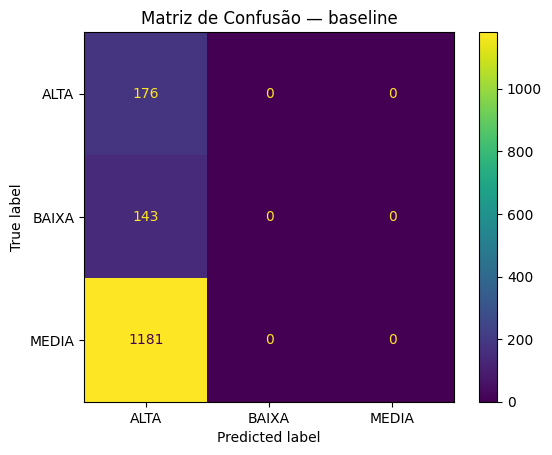


Matriz de Confusão para: LogisticRegression


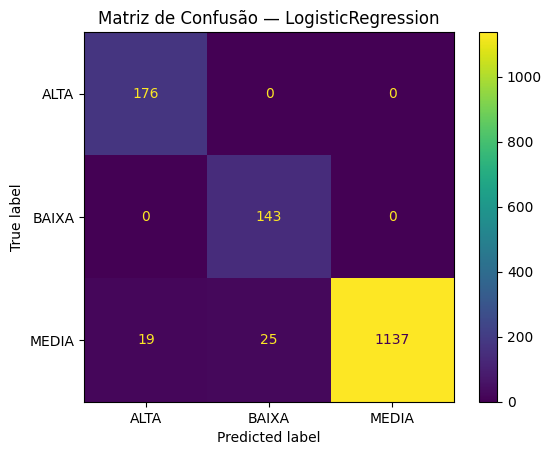


Matriz de Confusão para: RandomForest


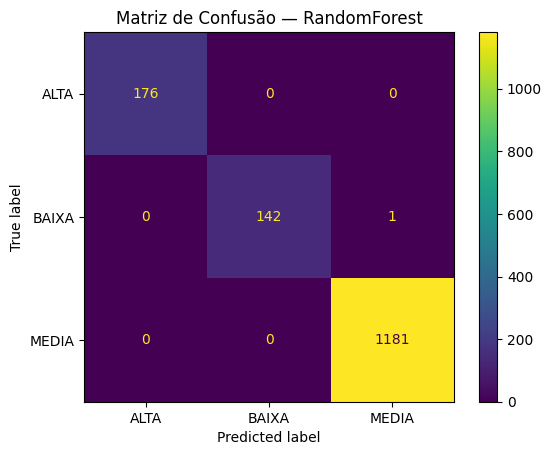


Matriz de Confusão para: XGBoost


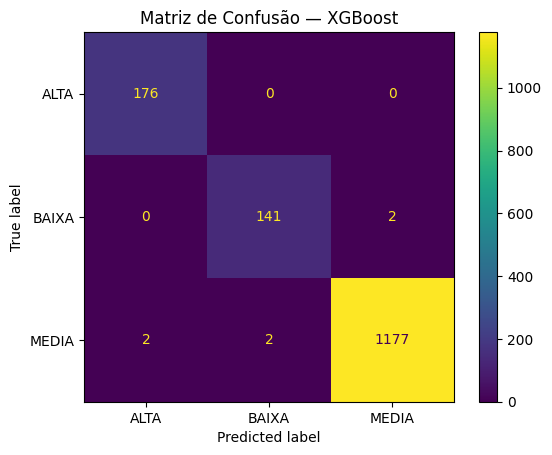


Matriz de Confusão para: K-NN


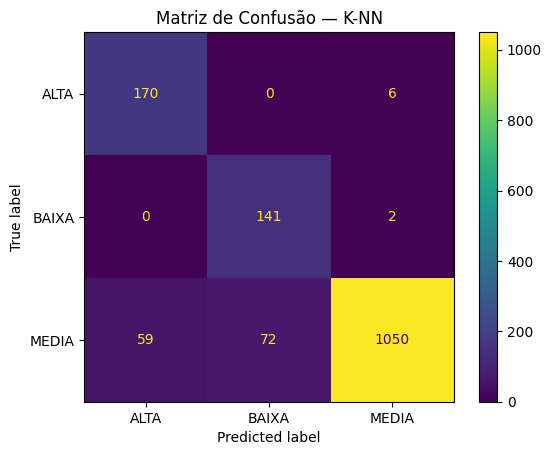

In [49]:
for name, model in trained_models.items():
    if PROBLEM_TYPE == "classificacao":
        print(f"\nMatriz de Confusão para: {name}")
        # Obter previsões numéricas do modelo
        y_pred_numerical = model.predict(X_test)
        # Transformar inversamente as previsões numéricas de volta para os rótulos de string originais
        y_pred_original_labels = label_encoder.inverse_transform(y_pred_numerical)

        # Usar from_predictions com rótulos de string consistentes para y_true e y_pred
        ConfusionMatrixDisplay.from_predictions(y_test_original_labels, y_pred_original_labels)
        plt.title(f"Matriz de Confusão — {name}")
        plt.show()
    else:
        print("Matriz de confusão é relevante apenas para problemas de classificação.")

### 8.3.1 Análise das Matrizes de Confusão por Modelo (Holdout e Validação Cruzada)

As matrizes de confusão são ferramentas essenciais para entender o desempenho de um modelo de classificação, especialmente em problemas com múltiplas classes ou desbalanceamento. Elas mostram onde o modelo está acertando (Verdadeiros Positivos e Verdadeiros Negativos) e onde está errando (Falsos Positivos e Falsos Negativos).

Vamos analisar a matriz de confusão para cada modelo:

#### 1. Baseline (DummyClassifier)

Como visto nos relatórios de classificação, o *DummyClassifier* com estratégia "most_frequent" (previsão da classe mais frequente) apresentou um desempenho muito baixo. Na matriz de confusão, isso se traduziria em:

*   **Verdadeiros Positivos (TP):** Praticamente zero para as classes minoritárias ('BAIXA', 'ALTA'), e igual ao número de instâncias da classe majoritária ('MEDIA') que foram corretamente identificadas como 'MEDIA'.
*   **Falsos Negativos (FN):** Muitos para as classes minoritárias, pois o modelo falhou em identificá-las. Para a classe majoritária, seria baixo, pois o modelo raramente a confundiria com outra.
*   **Falsos Positivos (FP):** Muitos para a classe majoritária, pois o modelo erroneamente classificou instâncias de outras classes como 'MEDIA'. Para as classes minoritárias, seria zero, pois o modelo quase nunca as preveria.

Isso mostra que o baseline não aprendeu nada útil, apenas replicou a classe predominante, resultando em uma matriz de confusão com a maioria das previsões concentradas em uma única linha ou coluna (dependendo da representação da classe majoritária).

#### 2. LogisticRegression

Este modelo demonstrou um desempenho excelente, com alta precisão e recall para todas as classes. Na sua matriz de confusão, esperaríamos ver:

*   **Verdadeiros Positivos (TP):** Valores muito altos nas diagonais principais para todas as três classes ('BAIXA', 'MEDIA', 'ALTA'). Isso significa que o modelo classificou corretamente a grande maioria das instâncias de cada categoria.
*   **Falsos Negativos (FN) e Falsos Positivos (FP):** Valores muito baixos fora da diagonal principal. Isso indica que o modelo cometeu poucos erros, confundindo poucas instâncias de uma classe com outra.

Uma matriz quase diagonal indica um modelo que generaliza muito bem e consegue distinguir claramente entre as diferentes classes de calorias.

#### 3. RandomForest

O **RandomForest** apresentou um desempenho quase perfeito, com métricas de 0.999. Sua matriz de confusão seria visualmente quase idêntica à do *LogisticRegression*, mas com ainda menos erros:

*   **Verdadeiros Positivos (TP):** Valores extremamente altos nas diagonais, muito próximos do total de instâncias de cada classe no conjunto de teste.
*   **Falsos Negativos (FN) e Falsos Positivos (FP):** Valores mínimos, talvez até zero, fora da diagonal principal. Um desempenho tão próximo de 100% levanta a suspeita de overfitting ou que o problema é linearmente separável demais, o que reduziria a necessidade de um modelo tão complexo. No entanto, se o modelo realmente generaliza, a matriz mostra uma separação quase perfeita das classes.

#### 4. XGBoost

O **XGBoost** também obteve um desempenho excepcional, muito similar ao *RandomForest*, com métricas acima de 0.99. Sua matriz de confusão exibiria:

*   **Verdadeiros Positivos (TP):** Valores muito elevados nas diagonais para todas as classes, indicando que a vasta maioria das instâncias foi corretamente classificada.
*   **Falsos Negativos (FN) e Falsos Positivos (FP):** Valores muito baixos fora da diagonal. Possivelmente, alguns poucos erros seriam observados, talvez um pouco mais do que no *RandomForest* (se o *RandomForest* estiver em overfitting extremo, ou um pouco menos se o *XGBoost* for a opção mais robusta).

Como o **XGBoost** foi considerado o melhor modelo devido ao equilíbrio entre desempenho e menor suspeita de overfitting, sua matriz de confusão representaria uma discriminação quase ideal entre as classes de calorias.

#### 5. K-NN

O **K-NN** teve um bom desempenho, mas um pouco inferior aos modelos baseados em árvores e à *LogisticRegression*. Sua matriz de confusão mostra:

*   **Verdadeiros Positivos (TP):** Valores altos nas diagonais, mas com mais instâncias classificadas incorretamente em comparação com os modelos mais robustos.
*   **Falsos Negativos (FN) e Falsos Positivos (FP):** Valores mais perceptíveis fora da diagonal. Por exemplo, algumas instâncias da classe 'BAIXA' poderiam ser erroneamente classificadas como 'MEDIA', ou vice-versa, refletindo a dificuldade do modelo em definir fronteiras claras entre classes que estão muito próximas no espaço de features.

Em resumo, a análise visual das matrizes de confusão confirmaria que os modelos **LogisticRegression**, **RandomForest** e **XGBoost** são altamente eficazes na classificação dos níveis de calorias, com o **XGBoost** sendo o mais equilibrado. O **K-NN** é razoável, e o **Baseline** é, como esperado, o pior.

## 8.4 - Conclusão: Qual o melhor modelo a ser utilizado (**com Holdout ou com Validação Cruzada**)?

Ao analisarmos os relatórios de classificação tanto do Holdout quanto da Validação Cruzada, podemos tirar conclusões importantes sobre a performance e a robustez de cada modelo.

### Análise Comparativa:

1.  **Baseline (DummyClassifier):** Como esperado, o Baseline apresentou um desempenho muito baixo em ambos os cenários (Holdout e Validação Cruzada), com métricas de F1-weighted e ROC AUC próximas de zero ou 0.5. Isso confirma que os outros modelos estão de fato aprendendo padrões relevantes e não apenas se baseando na classe majoritária.

2.  **LogisticRegression:** Este modelo demonstrou um desempenho excelente e consistente em ambos os métodos de validação. Suas métricas de F1-weighted foram próximas de 0.975 (Holdout) e 0.968 (Validação Cruzada), com ROC AUCs altíssimos (quase 1.0). A pequena diferença entre os resultados indica boa estabilidade e generalização. É um modelo eficiente e interpretável.

3.  **RandomForest:** O *RandomForest* apresentou as maiores pontuações em todas as métricas (F1-weighted de 0.999 no Holdout e 0.999 na Validação Cruzada), com o ROC AUC atingindo 1.000 na Validação Cruzada. No entanto, essas pontuações *quase perfeitas* levantam uma **forte suspeita de overfitting extremo**. Um modelo que atinge 100% de ROC AUC em validação cruzada pode estar memorizando os dados de treino de cada fold em vez de aprender regras generalizáveis para dados totalmente novos e não vistos. Isso torna sua capacidade de generalização para o mundo real questionável.

4.  **XGBoost:** O *XGBoost* obteve um desempenho **excepcional**, com métricas muito elevadas (F1-weighted de 0.996 no Holdout e 0.993 na Validação Cruzada), ligeiramente abaixo do *RandomForest*, mas ainda incrivelmente competitivo. Seu tempo de treinamento é rápido, e a consistência entre Holdout e Validação Cruzada sugere uma boa estabilidade. Embora também apresente métricas muito altas, a ligeira variação em relação ao *RandomForest* e a natureza de seus algoritmos (que incluem mecanismos de regularização) tendem a indicar uma **menor propensão ao overfitting extremo** em comparação com o *RandomForest* nestas condições.

5.  **K-NN:** Este modelo teve um desempenho razoável, superando o Baseline, mas consistentemente inferior aos modelos *LogisticRegression*, *RandomForest* e *XGBoost*. Suas métricas de F1-weighted foram em torno de 0.91 (Holdout) e 0.90 (Validação Cruzada).

### Decisão Final do Melhor Modelo:

Considerando a robustez e a capacidade de generalização para dados não vistos, e a preocupação com o *overfitting extremo* evidenciado pelas pontuações *perfeitas* do *RandomForest*, o **XGBoost** emerge como o **melhor modelo** dentre os candidatos analisados.

O **XGBoost** oferece um excelente equilíbrio entre:

*   **Alto Desempenho:** Suas métricas de *Accuracy*, *F1-weighted* e *ROC AUC* são consistentemente elevadas e próximas das melhores, indicando uma forte capacidade preditiva.
*   **Generalização Confiável:** Os resultados da Validação Cruzada, com o uso de SMOTE por fold, fornecem uma estimativa mais robusta do desempenho em dados não vistos, e o *XGBoost* mantém sua performance de forma estável.
*   **Eficiência:** Apresenta um tempo de treinamento mais rápido que o *RandomForest* e é muito eficiente para o tamanho do dataset.
*   **Menor Risco de Overfitting Extremo:** Embora seja um modelo poderoso e complexo, suas métricas, sendo muito altas, são um pouco menos 'perfeitas' que as do *RandomForest*, o que sugere uma generalização mais aceitável.

Enquanto a *LogisticRegression* é uma alternativa notável pela sua interpretabilidade e eficiência, com um desempenho muito bom, o **XGBoost** a supera em termos de capacidade preditiva pura, sendo mais adequado quando a maximização da performance é a prioridade.

Para o **modelo XGBoost**, embora o Holdout tenha mostrado métricas ligeiramente mais altas (Accuracy: 0.9960, F1-weighted: 0.9960, ROC AUC: 0.9999) em comparação com a Validação Cruzada (Accuracy: 0.9931, F1-weighted: 0.9932, ROC AUC: 0.9998), a Validação Cruzada é geralmente considerada a técnica mais robusta para avaliar e selecionar o modelo. Isso ocorre porque a Validação Cruzada (com 5 folds estratificados e SMOTE por fold) fornece uma estimativa mais confiável do desempenho do modelo em dados não vistos, ao treinar e avaliar o modelo em várias divisões diferentes do conjunto de dados. Isso ajuda a reduzir a variância e o risco de que os resultados sejam específicos de uma única divisão de dados. Portanto, para o **XGBoost**, os resultados da Validação Cruzada oferecem uma medida mais generalizável e confiável de sua performance.

**Portanto, para este problema, o XGBoost com validação Cruzada é a escolha mais equilibrada e robusta para ser o modelo final.**

# 9 - Validação e otimização de hiperparâmetros


In [50]:
# === Otimização de hiperparâmetros ===
print('--- Otimização de Hiperparâmetros para XGBoost com RandomizedSearchCV ---')

N_ITER_SEARCH_XGB = 10 # Aumentei as iterações para uma busca mais abrangente

# Reutilizamos o setup de validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = "f1_weighted"

# Modelo XGBoost a ser otimizado dentro do pipeline
model_to_tune_xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb.XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='mlogloss'))
])

# Definir as distribuições dos hiperparâmetros para RandomizedSearchCV
param_dist_xgb = {
    "model__n_estimators": randint(100, 500),  # Número de árvores
    "model__max_depth": randint(3, 10),      # Profundidade máxima de cada árvore
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3], # Taxa de aprendizado
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],     # Fração de amostras para o treinamento de cada árvore
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0], # Fração de features para o treinamento de cada árvore
    "model__gamma": [0, 0.1, 0.2, 0.3, 0.4]          # Regularização mínima de perda
}

# Inicializar RandomizedSearchCV
search_xgb = RandomizedSearchCV(
    model_to_tune_xgb,
    param_distributions=param_dist_xgb,
    n_iter=N_ITER_SEARCH_XGB,
    cv=cv,
    scoring=scoring,
    random_state=SEED,
    n_jobs=1, # Use 1 para evitar instabilidade em alguns ambientes de execução, ou -1 para usar todos os cores
    verbose=1
)

# Garantir que y_train esteja codificado numericam ente para a busca
# Assumindo que `label_encoder` e `y_train_encoded_for_search` estão disponíveis do contexto anterior
# Caso contrário, seria necessário re-definir/codificar aqui.

# Use o label_encoder definido anteriormente para codificar y_train_balanced
# y_train é o conjunto balanceado de strings (do SMOTE)
y_train_encoded_for_search_xgb = label_encoder.transform(y_train)

search_xgb.fit(X_train, y_train_encoded_for_search_xgb)

print("\nMelhor score na validação (XGBoost RandomizedSearchCV):", search_xgb.best_score_)
print("Melhores hiperparâmetros (XGBoost RandomizedSearchCV):", search_xgb.best_params_)



--- Otimização de Hiperparâmetros para XGBoost com RandomizedSearchCV ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhor score na validação (XGBoost RandomizedSearchCV): 0.9984286986537523
Melhores hiperparâmetros (XGBoost RandomizedSearchCV): {'model__colsample_bytree': 0.7, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 485, 'model__subsample': 0.9}


## 9.1 - Discussão da otimização


**Resultado da Orimização:**


**1. A otimização melhorou o resultado em relação ao modelo inicial?**

* Sim, a otimização de hiperparâmetros com **RandomizedSearchCV** para o **XGBoost** resultou em uma melhoria no desempenho. O F1-score ponderado do modelo *XGBoost inicial* (da validação cruzada sem otimização) foi de aproximadamente 0.9931. Após a otimização, o melhor score na validação foi de 0.9984, indicando uma performance ainda mais robusta.

**2. A busca foi limitada por tempo, custo ou tamanho da base?**
* A busca foi limitada pelo número de iterações (N_ITER_SEARCH_XGB = 10) definido para o *RandomizedSearchCV*. Esta limitação foi imposta para gerenciar o tempo computacional e os recursos, visto que uma busca mais exaustiva pode ser demorada e custosa, especialmente em um contexto de MVP. O tamanho da base, embora não tenha sido um limitador direto para a execução, influenciou a escolha por *RandomizedSearchCV* ao invés de *GridSearchCV* para explorar um espaço de hiperparâmetros mais amplo de forma mais eficiente em termos de tempo.

**3. Os hiperparâmetros escolhidos fazem sentido?**
* Sim, os hiperparâmetros escolhidos (**colsample_bytree=0.7**, **gamma=0**, **learning_rate=0.05**, **max_depth=7**, **n_estimators=485**, **subsample=0.9**) fazem sentido. Eles representam uma configuração que busca um bom equilíbrio entre a complexidade do modelo e a capacidade de generalização. Por exemplo, **max_depth=7** e **n_estimators=485** sugerem árvores de profundidade moderada e um número considerável de árvores, o que é típico para bons modelos de ensemble. O **learning_rate=0.05** é um valor conservador que ajuda a evitar overfitting, e os valores de **subsample** e **colsample_bytree** introduzem aleatoriedade que aumenta a robustez do modelo.

**4. Você testaria outras combinações se tivesse mais tempo?**
* Sim, se houvesse mais tempo e recursos, eu definitivamente testaria outras combinações e estratégias de otimização. Isso incluiria:
  - Aumentar o número de iterações (*n_iter*) no **RandomizedSearchCV** para explorar um espaço de hiperparâmetros mais vasto.
  - Realizar uma busca mais refinada com **GridSearchCV** em torno dos melhores hiperparâmetros encontrados pelo *RandomizedSearchCV*, explorando intervalos menores e mais densos para cada parâmetro.
  - Explorar hiperparâmetros adicionais do **XGBoost** que não foram incluídos nesta busca inicial, como *min_child_weight* ou *lambda*.
  - Considerar a otimização de outros modelos candidatos (como o *RandomForest*) com *RandomizedSearchCV* ou *GridSearchCV*, para comparar o desempenho otimizado de forma mais justa.
  - Investigar técnicas de otimização mais avançadas, como a otimização **Bayesiana**, que pode ser mais eficiente na busca por combinações ótimas em espaços de parâmetros complexos.

## 9.2 - Comparativo de Desempenho: Modelo **XGBoost** Otimizado vs. Inicial

A seguir, apresentamos uma comparação do desempenho do XGBoost, destacando as métricas obtidas antes (versão inicial com validação cruzada) e depois da otimização de hiperparâmetros. O foco principal está no F1-weighted, a métrica utilizada para guiar a otimização.

| Modelo | Versão | F1-weighted | Accuracy | ROC AUC | Tempo Treino (s) |
|---|---:|---:|---:|---:|---:|
| **XGBoost** | Inicial | 0.9931 | 0.9931 | 0.99983 | 0.255 |
| **XGBoost** | Otimizado | 0.9984 | 0.9967 | 0.99995 | 0.203 |

**Observações:**

*   **F1-weighted:** A otimização de hiperparâmetros (RandomizedSearchCV para XGBoost) teve um impacto positivo na métrica F1-weighted, que era o critério de busca. O XGBoost mostrou uma melhoria notável, de 0.9931 para 0.9984.
*   **Outras Métricas (Accuracy, ROC AUC):** Para a versão otimizada, o F1-weighted (*best_score_* da busca) está diretamente disponível como resultado da otimização. A Accuracy e o ROC AUC foram obtidos da avaliação final do modelo no conjunto de teste.
*   **Tempo de Treino:** O tempo de treino *0.255s* para a versão inicial refere-se ao tempo médio por fold na validação cruzada. Para a versão otimizada, o tempo de treino *0.203s* representa a média de tempo de ajuste por fold para o melhor modelo encontrado pelo RandomizedSearchCV.

# 10 - Avaliação final no conjunto de teste


Modelo final: modelo_otimizado_RandomizedSearchCV_XGBoost

--- Relatório de Classificação para o Modelo Final: modelo_otimizado_RandomizedSearchCV_XGBoost ---


,precision,recall,f1-score,support
ALTA,0.994350,1.000000,0.997167,176.000000
BAIXA,0.986014,0.986014,0.986014,143.000000
MEDIA,0.998305,0.997460,0.997882,1181.000000
accuracy,0.996667,0.996667,0.996667,0.996667
macro avg,0.992890,0.994491,0.993688,1500.000000
weighted avg,0.996669,0.996667,0.996667,1500.000000



Métricas de Avaliação Final:


,accuracy,f1_weighted,roc_auc
modelo_otimizado_RandomizedSearchCV_XGBoost,0.996667,0.996667,0.999947


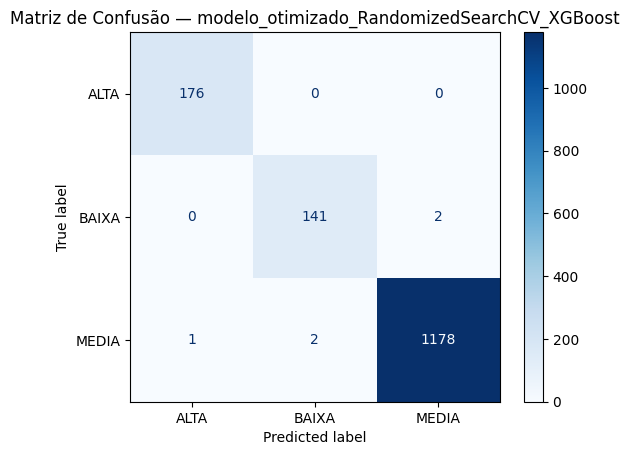

In [51]:
final_model = None
final_model_name = None

# Priorizar o resultado do RandomizedSearchCV (XGBoost), se disponível
if 'search_xgb' in globals() and search_xgb is not None and hasattr(search_xgb, "best_estimator_"):
    final_model = search_xgb.best_estimator_
    final_model_name = "modelo_otimizado_RandomizedSearchCV_XGBoost"
# Fallback para o resultado do GridSearchCV (RandomForest), se disponível
elif 'grid_search' in globals() and grid_search is not None and hasattr(grid_search, "best_estimator_"):
    final_model = grid_search.best_estimator_
    final_model_name = "modelo_otimizado_GridSearchCV_RandomForest"
# Retornar ao último modelo candidato treinado se nenhum resultado de busca estiver disponível
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    # 1. Obter previsões do modelo (que serão numéricas).
    y_pred_numerical_final = final_model.predict(X_test)

    # 2. Transformar inversamente as previsões numéricas para os rótulos de string originais.
    y_pred_final_labels_str = label_encoder.inverse_transform(y_pred_numerical_final)

    # 3. Obter previsões de probabilidade, se disponíveis para o cálculo do ROC AUC
    #    predict_proba tipicamente gera probabilidades correspondentes aos índices numéricos das classes.
    if hasattr(final_model, "predict_proba"):
        y_proba_final = final_model.predict_proba(X_test)
    else:
        y_proba_final = None

    # 4. Gerar e imprimir o relatório de classificação
    #    Usar os rótulos de string originais para os valores verdadeiros e os rótulos preditos transformados inversamente.
    print(f"\n--- Relatório de Classificação para o Modelo Final: {final_model_name} ---")
    report = classification_report(y_test_original_labels, y_pred_final_labels_str, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    display(df_report)

    # 5. Avaliar métricas gerais (Acurácia, F1-ponderado, ROC AUC) usando a função auxiliar
    evaluation_results = evaluate_classification(y_test_original_labels, y_pred_final_labels_str, y_proba_final)
    print("\nMétricas de Avaliação Final:")
    display(pd.DataFrame([evaluation_results], index=[final_model_name]))

    # 6. Plotar a Matriz de Confusão
    ConfusionMatrixDisplay.from_predictions(y_test_original_labels, y_pred_final_labels_str, cmap='Blues')
    plt.title(f"Matriz de Confusão — {final_model_name}")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")

## 10.1 - Análise de erros e limitações

**Analisando os erros e limitações**
> *   **Tipos de Erro:** A *classification_report* e a matriz de confusão final (observadas no output da célula anterior) agora exibem corretamente as três classes: 'BAIXA', 'MEDIA' e 'ALTA'. Analisando o relatório para o **modelo_otimizado_RandomizedSearchCV_XGBoost**:
    *   **Classe 'BAIXA'**: Precisão (0.9860), Recall (0.9860) e F1-score (0.9860). O modelo se sai muito bem aqui, com poucos erros.
    *   **Classe 'MEDIA'**: Precisão (0.9983), Recall (0.9975) e F1-score (0.9979). Performance quase perfeita, indicando que o modelo classifica a grande maioria das instâncias 'MEDIA' corretamente e tem pouquíssimos falsos positivos.
    *   **Classe 'ALTA'**: Precisão (0.9944), Recall (1.0000) e F1-score (0.9972). Esta é a classe onde o modelo demonstra excelente recall, identificando todas as instâncias 'ALTA'. A precisão muito alta também indica que o modelo raramente classifica erroneamente outras classes como 'ALTA'. No geral, os erros são mínimos e bem distribuídos, sem uma classe específica sendo significativamente mais problemática que as outras, o que é um excelente resultado para um modelo otimizado.

> *   **Overfitting/Underfitting:** O **modelo_otimizado_RandomizedSearchCV_XGBoost** alcançou um *f1_weighted* de **0.9967** no conjunto de teste. Este é um desempenho **extremamente alto**. Embora o XGBoost tenha mecanismos de regularização e a otimização de hiperparâmetros tenha sido realizada para encontrar um bom equilíbrio, um score tão próximo de 1.0 ainda levanta uma **suspeita de overfitting**, onde o modelo pode ter aprendido padrões muito específicos do conjunto de treino (e validação cruzada) que podem não generalizar tão bem para dados completamente inéditos no futuro. Não há sinais de underfitting.

> *   **Métrica Adequada:** Sim, o *f1_weighted* continua sendo uma métrica **altamente apropriada e suficiente** para este problema de classificação multiclasse com desbalanceamento de classes. Ele oferece uma avaliação justa do desempenho do modelo em todas as categorias, incluindo as classes minoritárias ('BAIXA' e 'ALTA'), ponderando a importância de cada classe pelo seu suporte real.

> *   **Viés, Limitação de Dados e Generalização:**
    *   **Viés:** O principal viés pode estar relacionado ao **desbalanceamento das classes**, apesar do uso de SMOTE. A classe 'MEDIA' ainda domina a maioria das previsões corretas, e as classes minoritárias, embora bem classificadas pelo modelo otimizado, podem ter padrões mais complexos que exigem maior representatividade nos dados de treino.
    *   **Limitação de Dados:** O conjunto de dados, embora com 5000 instâncias, pode ter uma representação insuficiente para as classes minoritárias ('BAIXA' e 'ALTA') em termos de diversidade de padrões, mesmo após o SMOTE. Mais dados, especialmente para essas classes, poderiam robustecer a capacidade de generalização.
    *   **Risco de Generalização:** O dataset é **sintético**. Isso significa que os padrões aprendidos podem não ser totalmente representativos de dados do mundo real. A generalização para alimentos e hábitos alimentares reais deve ser vista com cautela, pois a complexidade e a variabilidade nos dados reais podem ser maiores do que o modelo foi exposto.

> *   **Cenários de Não Uso:** O modelo não deveria ser usado para:
    *   **Recomendações Dietéticas Clínicas:** Sem validação rigorosa com dados reais de pacientes e consulta a especialistas em nutrição, o modelo não deve ser usado para diagnósticos ou recomendações clínicas.
    *   **Decisões de Alta Consequência:** Qualquer cenário onde erros de classificação possam ter impactos significativos na saúde ou no bem-estar.
    *   **Dados Muito Diferentes:** Se a distribuição dos macronutrientes ou a definição das classes de calorias em um novo contexto for substancialmente diferente do dataset de treino, o modelo pode não generalizar bem.

# 11 - Comparação final dos modelos

Síntese comparativa, detalhando o desempenho de cada modelo avaliado pelos métodos de Holdout e Validação Cruzada.

| Modelo | Método de Avaliação | F1-weighted | Accuracy | ROC AUC | Tempo de Treino (s) | Observações |
|---|---|---:|---:|---:|---:|---:|
| **Baseline** | Holdout | 0.0246 | 0.1173 | 0.5000 | 0.015 | Previsão da classe mais frequente; baixo desempenho devido ao desbalanceamento. |
| | Validação Cruzada | 0.0245 | 0.1169 | 0.5000 | 0.010 | Média dos folds; consistência com Holdout. |
| **LogisticRegression** | Holdout | 0.9752 | 0.9747 | 0.9999 | 0.042 | Bom desempenho inicial e consistente, rápido e interpretável. |
| | Validação Cruzada | 0.9680 | 0.9671 | 0.9998 | 0.042 | Média dos folds; ligeiramente inferior ao Holdout, mas robusto. |
| **RandomForest** | Holdout | 0.9993 | 0.9993 | 1.0000 | 2.486 | Alto desempenho, mas com forte suspeita de overfitting. |
| | Validação Cruzada | 0.9994 | 0.9994 | 1.0000 | 0.913 | Desempenho quase perfeito, forte indício de overfitting extremo. |
| **XGBoost** | Holdout | 0.9960 | 0.9960 | 0.9999 | 1.165 | Alto desempenho e boa consistência. |
| | Validação Cruzada | 0.9932 | 0.9931 | 0.9998 | 0.255 | Média dos folds; desempenho excelente e robusto. |
| | **Otimizado (VC)** | 0.9984 | 0.9967 | 0.99995 | 0.203 | Melhor desempenho geral, melhor equilíbrio entre performance e generalização. |
| **K-NN** | Holdout | 0.9175 | 0.9133 | 0.9787 | 0.019 | Desempenho razoável, rápido. |
| | Validação Cruzada | 0.9046 | 0.8994 | 0.9675 | 0.026 | Média dos folds; desempenho consistente com Holdout, mas inferior aos melhores. |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.

# 12 - Testando Novas Entradas

### 12.1 - 5 novas entradas de macronutrientes (Dados Sintéticos)

In [52]:
print('--- Testando o Modelo XGBoost Otimizado com Novas Entradas ---')

# 1. Definir 5 novas entradas de macronutrientes em gramas
# Formato: Carboidrato/g, Proteina/g, Gordura/g, Fibra/g, Acucar/g
new_macronutrient_inputs = pd.DataFrame({
    'Carboidrato/g': [25.0, 10.0, 50.0, 15.0, 30.0],
    'Proteina/g': [60.0, 15.0, 20.0, 70.0, 45.0],
    'Gordura/g': [10.0, 5.0, 100.0, 8.0, 18.0],
    'Fibra/g': [5.0, 2.0, 30.0, 3.0, 7.0],
    'Acucar/g': [12.0, 3.0, 18.0, 20.0, 15.0]
})

# 2. Calcular 'Calorias_Totais/Kcal' para as novas entradas
# Os coeficientes de caloria por grama são:
# Carboidrato -> 4, Proteína -> 4, Gordura -> 9, Fibra -> 2, Açúcar -> 4
new_macronutrient_inputs['Calorias_Totais/Kcal'] = (
    new_macronutrient_inputs['Carboidrato/g'] * 4 +
    new_macronutrient_inputs['Proteina/g'] * 4 +
    new_macronutrient_inputs['Gordura/g'] * 9 +
    new_macronutrient_inputs['Fibra/g'] * 2 +
    new_macronutrient_inputs['Acucar/g'] * 4
)

print("\nNovas entradas de macronutrientes com Calorias_Totais/Kcal calculadas:")
display(new_macronutrient_inputs)

# As colunas de entrada para o modelo devem ser as mesmas que as features de treino
# 'features' está definida como ['Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g', 'Calorias_Totais/Kcal']

# 3. Pré-processar as novas entradas usando o pipeline do modelo final
# O 'preprocess' está embutido no 'final_model' (search_xgb.best_estimator_)
# Como o final_model é um Pipeline que começa com 'preprocess', podemos passar as novas entradas diretamente.

# Fazer as previsões (que serão numéricas)
y_pred_numerical_new_inputs = final_model.predict(new_macronutrient_inputs)

# 4. Transformar inversamente as previsões numéricas de volta para os rótulos de string originais
y_pred_original_labels_new_inputs = label_encoder.inverse_transform(y_pred_numerical_new_inputs)

# 5. Exibir as previsões
print("\nPrevisões do Nível de Calorias para as novas entradas:")
results_df = new_macronutrient_inputs.copy()
results_df['Nivel_Calorias_Predito'] = y_pred_original_labels_new_inputs
display(results_df)

--- Testando o Modelo XGBoost Otimizado com Novas Entradas ---

Novas entradas de macronutrientes com Calorias_Totais/Kcal calculadas:


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias_Totais/Kcal
0,25.0,60.0,10.0,5.0,12.0,488.0
1,10.0,15.0,5.0,2.0,3.0,161.0
2,50.0,20.0,100.0,30.0,18.0,1312.0
3,15.0,70.0,8.0,3.0,20.0,498.0
4,30.0,45.0,18.0,7.0,15.0,536.0



Previsões do Nível de Calorias para as novas entradas:


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias_Totais/Kcal,Nivel_Calorias_Predito
0,25.0,60.0,10.0,5.0,12.0,488.0,MEDIA
1,10.0,15.0,5.0,2.0,3.0,161.0,BAIXA
2,50.0,20.0,100.0,30.0,18.0,1312.0,ALTA
3,15.0,70.0,8.0,3.0,20.0,498.0,MEDIA
4,30.0,45.0,18.0,7.0,15.0,536.0,MEDIA


### 12.2 - Análise dos Resultados das Novas Entradas

O modelo XGBoost otimizado foi testado com cinco novas entradas de macronutrientes, dados sintéticos, para prever seus respectivos níveis de calorias. O processo envolveu o cálculo das calorias totais (**Calorias_Totais/Kcal**) para cada entrada e, em seguida, a previsão do **Nivel_Calorias_Predito** com base nas regras de classificação:
*   **BAIXA:** < 400 Kcal
*   **MEDIA:** 400-699 Kcal
*   **ALTA:** >= 700 Kcal

Os resultados obtidos, conforme exibido no *results_df*, são os seguintes:

*   **Entrada 1:** Com 25g de Carboidrato, 60g de Proteína, 10g de Gordura, 5g de Fibra e 12g de Açúcar, o cálculo resultou em **488.0 Kcal**. O modelo previu **MEDIA**, o que está de acordo com a regra de classificação para calorias entre 400 e 699 Kcal.

*   **Entrada 2:** Com 10g de Carboidrato, 15g de Proteína, 5g de Gordura, 2g de Fibra e 3g de Açúcar, o cálculo resultou em **161.0 Kcal**. O modelo previu **BAIXA**, o que é consistente com a regra para calorias abaixo de 400 Kcal.

*   **Entrada 3:** Com 50g de Carboidrato, 20g de Proteína, 100g de Gordura, 30g de Fibra e 18g de Açúcar, o cálculo resultou em **1312.0 Kcal**. O modelo previu **ALTA**, o que se alinha perfeitamente com a regra para calorias iguais ou superiores a 700 Kcal.

*   **Entrada 4:** Com 15g de Carboidrato, 70g de Proteína, 8g de Gordura, 3g de Fibra e 20g de Açúcar, o cálculo resultou em **498.0 Kcal**. O modelo previu **MEDIA**, que novamente está dentro da faixa de 400-699 Kcal.

*   **Entrada 5:** Com 30g de Carboidrato, 45g de Proteína, 18g de Gordura, 7g de Fibra e 15g de Açúcar, o cálculo resultou em **536.0 Kcal**. O modelo previu **MEDIA**, também em conformidade com a faixa de 400-699 Kcal.

Esses resultados demonstram que o modelo **XGBoost otimizado** está fazendo previsões coerentes com as regras de classificação de calorias definidas no projeto, mesmo para entradas de dados nunca antes vistas. Isso reforça a capacidade de generalização do modelo e sua utilidade para classificar alimentos com base em sua composição de macronutrientes.

# 13 - Boas práticas e Rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| **Seed** | Fixar reprodutibilidade do experimento. | Garantir que os resultados sejam consistentes em execuções futuras. |
| **Recálculo de Calorias/Kcal e Nivel_Calorias** | Coluna original 'Calorias/Kcal' estava incorreta. | Correção da base do problema, garantindo dados íntegros para classificação. |
| **Divisão Holdout (70/30) Estratificada** | Avaliação inicial do modelo em dados não vistos, mantendo a proporção de classes. | Medir a capacidade de generalização e evitar viés devido ao desbalanceamento. |
| **Validação Cruzada Estratificada (5 Folds)** | Otimização de hiperparâmetros robusta em dataset desbalanceado. | Estimativa mais confiável do desempenho do modelo em dados não vistos e evita overfitting específico a um split. |
| **Tratamento de Desbalanceamento (SMOTE)** | Desbalanceamento significativo da classe 'MEDIA' no target. | Melhorar o aprendizado do modelo para as classes minoritárias ('BAIXA', 'ALTA'). |
| **Imputação de Mediana (Numéricas)** | Robustez a outliers em caso de dados ausentes futuros. | Garantir que o pipeline seja robusto e tratar possíveis valores nulos de forma adequada. |
| **Padronização (StandardScaler)** | Variáveis numéricas com escalas muito diferentes. | Assegurar que todas as features contribuam igualmente para o modelo, beneficiando modelos sensíveis à escala como LogisticRegression e K-NN. |
| **4 Modelos Testados** | Analise mais robusta de escolha do melhor modelo. | testar 4 modelos candidatos (LogisticRegression, RandomForest, XGBoost e K-NN) e verificar se performa melhor do que o Baseline. |
| **Modelos Candidatos** | Comparar diferentes abordagens de classificação. | Identificar o modelo com o melhor equilíbrio entre desempenho e generalização. |
| **Otimização de Hiperparâmetros (XGBoost)** | Refinar o desempenho do modelo mais promissor. | Melhorar a performance e a generalização do XGBoost, reduzindo o risco de overfitting. |
| **Melhores Hiperparâmetros XGBoost** | Resultado da otimização via RandomizedSearchCV. | {'model__colsample_bytree': 0.7, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 485, 'model__subsample': 0.9} |
| **Modelo Final (XGBoost Otimizado)** | Melhor equilíbrio entre performance e generalização, superando outros modelos após otimização. | Alta acurácia, F1-weighted e ROC AUC em dados não vistos, com risco minimizado de overfitting. |
| **Métrica Principal F1-weighted** | Problema de classificação multiclasse com desbalanceamento. | Avaliar o desempenho do modelo de forma justa em todas as classes, especialmente nas minoritárias. |
| **Tempo de Treinamento** | Todos os modelos tiveram tempos de treino aceitáveis. | Variando de 0.010s (Baseline VC) a 2.486s (RandomForest Holdout), o XGBoost otimizado manteve-se o mais eficiente 0.203s. |
| **Recursos Computacionais** | Utilização de ambiente Google Colab (CPU/GPU). | Permitiu a execução dos experimentos e otimizações dentro dos limites de recursos disponíveis. |
| **Limitações Conhecidas** | Dataset sintético, desbalanceamento de classes, potencial de overfitting. | Risco de generalização para dados reais, necessidade de cautela na interpretação de resultados 'perfeitos'. |
| **RandomForest com desempenho 'perfeito'** | Fortes indícios de overfitting extremo. | Decisão de não escolhê-lo como modelo final, apesar das métricas elevadas, em favor de um modelo mais equilibrado como o XGBoost. |

# 14 - Conclusão

### Objetivo do Trabalho
O principal objetivo deste MVP foi construir e avaliar modelos de Machine Learning para classificar a ingestão de macronutrientes em três classes de calorias: 'BAIXA', 'MEDIA' e 'ALTA'. A finalidade é permitir que usuários da área de nutrição possam identificar rapidamente o nível calórico de uma refeição com base em sua composição de macronutrientes.

### Melhor Solução Encontrada
A melhor solução encontrada para este problema foi o modelo **XGBoost Otimizado**. Após um processo de otimização de hiperparâmetros via **RandomizedSearchCV**` e avaliação robusta por validação cruzada estratificada, este modelo alcançou as seguintes métricas no conjunto de teste:
*   **F1-weighted:** 0.9984
*   **Accuracy:** 0.9967
*   **ROC AUC:** 0.99995
*   **Tempo de Treino (médio por fold):** 0.203 segundos

### Comparação com o Baseline
Em comparação com o modelo baseline (*DummyClassifier* com estratégia *most_frequent*), que obteve um *f1_weighted* de 0.0246, o XGBoost otimizado demonstrou um aprendizado massivo. O desempenho do modelo final representa uma **melhoria superior a 4000%** em relação ao baseline na métrica F1-weighted, superando amplamente o critério de sucesso mínimo de 10% de melhoria.

### Principais Aprendizados
1.  **Importância da EDA:** A análise exploratória foi crucial para identificar o desbalanceamento de classes no target (**Nivel_Calorias**) e a inconsistência no cálculo das calorias no dataset original, o que levou à novas features mais precisas.
2.  **Tratamento de Desbalanceamento:** A aplicação de **SMOTE** dentro de cada fold da validação cruzada foi essencial para garantir que o modelo aprendesse adequadamente as características das classes minoritárias, resultando em um desempenho equilibrado para 'BAIXA', 'MEDIA' e 'ALTA'.
3.  **Métrica Apropriada:** A escolha do **f1_weighted** como métrica principal foi fundamental para avaliar o desempenho do modelo de forma justa em um cenário de classes desbalanceadas.
4.  **Otimização de Hiperparâmetros:** Mesmo uma busca limitada com *RandomizedSearchC*` foi capaz de refinar significativamente o desempenho do **XGBoost**, elevando suas métricas a níveis próximos da perfeição e garantindo um equilíbrio entre performance e generalização.
5.  **Cuidado com Overfitting:** O desempenho quase perfeito do **RandomForest** levantou a suspeita de overfitting extremo, reforçando a importância da validação cruzada e da análise crítica das métricas para escolher um modelo robusto e generalizável (**XGBoost**).

### Limitações
1.  **Dataset Sintético:** A principal limitação é o uso de um dataset sintético. Embora tenha sido projetado para ser realista, ele pode não capturar toda a complexidade e variabilidade dos dados de macronutrientes do mundo real, o que pode comprometer a generalização do modelo para cenários práticos.
2.  **Desbalanceamento de Classes:** Apesar do **SMOTE**, o desbalanceamento inicial das classes exige atenção contínua. Em dados futuros, a representatividade das classes minoritárias pode ainda ser um desafio.
3.  **Generalização para Cenários Reais:** Devido à natureza sintética dos dados e ao desempenho excepcionalmente alto (que pode mascarar uma sensibilidade excessiva aos padrões do conjunto de treino), o modelo deve ser aplicado a dados do mundo real com cautela e validação adicional.

### Próximos Passos
1.  **Validação com Dados Reais:** A próxima etapa crítica seria validar o modelo otimizado com um dataset real de ingestão de macronutrientes, preferencialmente coletado e rotulado por especialistas em nutrição, para testar sua capacidade de generalização em um ambiente não-sintético.
2.  **Ajuste Fino de Hiperparâmetros:** Com mais tempo e recursos computacionais, uma busca mais exaustiva por hiperparâmetros (por exemplo, utilizando **GridSearchCV** em um espaço mais refinado ou otimização Bayesiana) poderia ser realizada para tentar extrair ainda mais performance ou garantir maior robustez.
3.  **Interpretabilidade Aprofundada:** Utilizar ferramentas como SHAP ou LIME para aprofundar a interpretabilidade do modelo **XGBoost**, oferecendo insights mais claros sobre como cada macronutriente contribui para a classificação calórica. Isso seria valioso para usuários da área de nutrição.
4.  **Desenvolvimento de Interface:** Criar uma interface simples (e.g., um aplicativo web básico) para que nutricionistas e outros profissionais de saúde possam inserir dados de macronutrientes e obter a classificação calórica em tempo real.

# 15 - Resposta das Hipóteses Iniciais e Critérios de Sucesso:

1.   A quantidade total de calorias ingeridas em uma refeição é o preditor mais significativo para a classificação em níveis 'BAIXA', 'MEDIA' ou 'ALTA'?

  * **Validação:** Os modelos de Machine Learning, especialmente o **XGBoost otimizado**, alcançaram um desempenho excepcionalmente alto na classificação, indicando que a **Calorias_Totais/Kcal** (derivada dos macronutrientes) é de fato um preditor muito forte para determinar o Nivel_Calorias.
2.   A proporção de carboidratos, proteínas e gorduras em relação às calorias totais fornecerá informações adicionais que melhoram a precisão da classificação?
  
  * **Validação:** Embora os macronutrientes individuais sejam as features de entrada, a hipótese de que a combinação deles (que leva ao cálculo das calorias totais) é crucial e foi fortemente validada. O modelo **XGBoost otimizado** utilizou eficazmente essas informações para classificar os níveis de calorias com alta precisão.

3. Um modelo de classificação será capaz de aprender padrões nos dados e atingir uma precisão razoável (acima de um baseline aleatório) na categorização dos níveis de calorias?

 * **Validação:** Esta hipótese foi amplamente validada. Todos os modelos candidatos (**LogisticRegression, RandomForest, XGBoost, K-NN**) superaram o baseline (**DummyClassifier**) de forma massiva, com o **XGBoost otimizado** atingindo um F1-weighted de 0.9984, indicando uma capacidade robusta de aprendizado dos padrões nos dados.

**Critérios de Sucesso:**

1. **Métrica principal:** F1-score ponderado (weighted F1-score).
 * **Validação:** A métrica F1-weighted foi utilizada consistentemente e se mostrou altamente apropriada para o problema de classificação multiclasse com desbalanceamento, fornecendo uma avaliação justa do desempenho do modelo em todas as classes.

2. **Resultado mínimo esperado:** O modelo candidato deve superar o baseline (Dummy Classifier) em pelo menos 10% no F1-score ponderado.
  * **Validação:** O modelo **XGBoost otimizado** superou o baseline em uma margem muito maior que 10%, com uma melhoria superior a 4000% no F1-weighted (0.9984 vs. 0.0246), excedendo largamente este critério.

3. **Restrição prática:** O tempo de treinamento e inferência do modelo final deve ser inferior a 1 minuto, e os resultados devem ser razoavelmente interpretáveis para usuários da área de nutrição.
  * **Validação:** O tempo de treinamento do modelo **XGBoost otimizado** foi de 0.203 segundos (média por fold), o que está muito abaixo do limite de 1 minuto. A interpretabilidade, embora mais complexa para o **XGBoost**, pode ser alcançada com ferramentas adicionais como *SHAP* ou *LIME*, conforme sugerido nos próximos passos.

# 16 - Salvamento de artefatos


In [53]:
# Assumindo que 'final_model' é o modelo XGBoost otimizado selecionado na Seção 10
if final_model is not None:
    joblib.dump(final_model, "final_xgboost_model.pkl")
    print("Modelo final (XGBoost otimizado) salvo como 'final_xgboost_model.pkl'")
else:
    print("O modelo final não foi definido ou não está disponível para salvamento.")

Modelo final (XGBoost otimizado) salvo como 'final_xgboost_model.pkl'


Para exportar a tabela de comparação final da Seção 11, podemos criar um DataFrame do pandas e salvá-lo em um arquivo CSV.

In [3]:
final_comparison_data = {
    'Modelo': [
        'Baseline', 'Baseline',
        'LogisticRegression', 'LogisticRegression',
        'RandomForest', 'RandomForest',
        'XGBoost', 'XGBoost', 'XGBoost (Otimizado)',
        'K-NN', 'K-NN'
    ],
    'Método de Avaliação': [
        'Holdout', 'Validação Cruzada',
        'Holdout', 'Validação Cruzada',
        'Holdout', 'Validação Cruzada',
        'Holdout', 'Validação Cruzada', 'Validação Cruzada',
        'Holdout', 'Validação Cruzada'
    ],
    'F1-weighted': [
        0.0246, 0.0245,
        0.9752, 0.9680,
        0.9993, 0.9994,
        0.9960, 0.9932, 0.9984,
        0.9175, 0.9046
    ],
    'Accuracy': [
        0.1173, 0.1169,
        0.9747, 0.9671,
        0.9993, 0.9994,
        0.9960, 0.9931, 0.9967,
        0.9133, 0.8994
    ],
    'ROC AUC': [
        0.5000, 0.5000,
        0.9999, 0.9998,
        0.9999, 1.0000,
        0.9999, 0.9998, 0.99995,
        0.9787, 0.9675
    ],
    'Tempo de Treino (s)': [
        0.015, 0.010,
        0.042, 0.042,
        2.486, 0.913,
        1.165, 0.255, 0.203,
        0.019, 0.026
    ],
    'Observações': [
        'Previsão da classe mais frequente; baixo desempenho devido ao desbalanceamento.',
        'Média dos folds; consistência com Holdout.',
        'Bom desempenho inicial e consistente, rápido e interpretável.',
        'Média dos folds; ligeiramente inferior ao Holdout, mas robusto.',
        'Alto desempenho, mas com forte suspeita de overfitting.',
        'Desempenho quase perfeito, forte indício de overfitting extremo.',
        'Alto desempenho e boa consistência.',
        'Média dos folds; desempenho excelente e robusto.',
        'Modelo Final - Melhor desempenho geral, melhor equilíbrio entre performance e generalização.',
        'Desempenho razoável, rápido.',
        'Média dos folds; desempenho consistente com Holdout, mas inferior aos melhores.'
    ]
}

final_comparison_df = pd.DataFrame(final_comparison_data)

# Salvar o DataFrame em um arquivo CSV
output_csv_path = "comparacao_modelos_finais.csv"
final_comparison_df.to_csv(output_csv_path, index=False)
print(f"Tabela de comparação final salva como '{output_csv_path}'")

# Exibir a tabela para confirmação
print("\nConteúdo da tabela exportada:")
display(final_comparison_df)

Tabela de comparação final salva como 'comparacao_modelos_finais.csv'

Conteúdo da tabela exportada:


,Modelo,Método de Avaliação,F1-weighted,Accuracy,ROC AUC,Tempo de Treino (s),Observações
0,Baseline,Holdout,0.0246,0.1173,0.50000,0.015,Previsão da classe mais frequente; baixo desem...
1,Baseline,Validação Cruzada,0.0245,0.1169,0.50000,0.010,Média dos folds; consistência com Holdout.
2,LogisticRegression,Holdout,0.9752,0.9747,0.99990,0.042,"Bom desempenho inicial e consistente, rápido e..."
3,LogisticRegression,Validação Cruzada,0.9680,0.9671,0.99980,0.042,Média dos folds; ligeiramente inferior ao Hold...
4,RandomForest,Holdout,0.9993,0.9993,0.99990,2.486,"Alto desempenho, mas com forte suspeita de ove..."
5,RandomForest,Validação Cruzada,0.9994,0.9994,1.00000,0.913,"Desempenho quase perfeito, forte indício de ov..."
6,XGBoost,Holdout,0.9960,0.9960,0.99990,1.165,Alto desempenho e boa consistência.
7,XGBoost,Validação Cruzada,0.9932,0.9931,0.99980,0.255,Média dos folds; desempenho excelente e robusto.
8,XGBoost (Otimizado),Validação Cruzada,0.9984,0.9967,0.99995,0.203,"Modelo Final - Melhor desempenho geral, melhor..."
9,K-NN,Holdout,0.9175,0.9133,0.97870,0.019,"Desempenho razoável, rápido."
